<div style="background: linear-gradient(135deg, #1a237e 0%, #0d47a1 50%, #1565c0 100%); padding: 50px 40px; border-radius: 16px; text-align: center; margin-bottom: 20px;">
  <h1 style="color: white; font-size: 2.8em; margin: 0; letter-spacing: 2px; text-shadow: 2px 2px 6px rgba(0,0,0,0.4);">
    📊 Feature Transformation & Engineering
  </h1>
  <hr style="border: 1px solid rgba(255,255,255,0.3); margin: 20px auto; width: 60%;">
  <p style="color: #e3f2fd; font-size: 1em; font-style: italic; margin: 0;">
    "You now take that clean dataset and reshape and enrich it so that machine learning algorithms can consume it effectively."
  </p>
</div>

## 📋 Table of Contents

| # | Topic | Subtopics |
|---|-------|-----------|
| 1 | **Feature Scaling** | Standardization, Min-Max, Robust Scaling |
| 2 | **Feature Encoding** | One-Hot, Label, Target, Frequency, Binary, Rare Categories |
| 3 | **Discretization & Binning** | `pd.cut()`, `pd.qcut()` |
| 4 | **Feature Interactions / Engineering** | Arithmetic, Statistical Aggregations, Boolean Combinations |
| 5 | **Feature Selection** | Filter Methods, Wrapper Methods, Permutation Importance |
| 6 | **Data Cleaning Log Report** | Class-based Logging, Exports |

---

In [1]:
# ──────────────────────────────────────────────
# Global Imports — Run this first!
# ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plotting defaults — light theme
plt.rcParams.update(
    {
        'figure.facecolor': 'white',
        'axes.facecolor': '#f8f9fa',
        'axes.grid': True,
        'grid.color': '#e0e0e0',
        'grid.linestyle': '--',
        'grid.linewidth': 0.7,
        'font.family': 'DejaVu Sans',
        'axes.spines.top': False,
        'axes.spines.right': False,
    }
)

print("✅ All libraries imported. Ready to go!")

✅ All libraries imported. Ready to go!


---
<div style="background: linear-gradient(90deg, #1565c0, #1976d2); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">🔢 Topic 1: Feature Scaling</h1>
</div>

> *"When you have different orders of magnitude within your data, you must normalize them."*

Machine learning algorithms that use **distance metrics** — such as k-nearest neighbors, support vector machines, and neural networks — are particularly sensitive to the scale of input features. Feature scaling **transforms numerical features to a common scale**.

### ✅ When You Need Scaling
| Needs Scaling | Does NOT Need Scaling |
|---|---|
| KNN | Decision Trees |
| SVM | Random Forest |
| Neural Networks | XGBoost / Gradient Boosting |
| Linear / Logistic Regression | Any tree-based model |
| PCA | |

### 🎯 Key Benefits of Feature Scaling

1. **Algorithm Convergence** — Gradient descent-based algorithms converge faster when features are on similar scales.
2. **Preventing Feature Dominance** — Ensures no single feature dominates due to scale differences, making feature importance more interpretable.
3. **Numerical Stability** — Reduces risk of numerical overflow or underflow in calculations.
4. **Improved Model Performance** — Many algorithms perform better with scaled features.

> ⚠️ **Critical Rule:** Always `fit` the scaler on **training data only**, then `transform` both train and test sets!


---
## 📌 1.1 Standardization (Z-Score Normalization)

<div style="background: #e3f2fd; border-left: 5px solid #1565c0; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Goal:</b> Transform data to have a <b>mean of 0</b> and <b>standard deviation of 1</b>, creating a "standard normal distribution."
</div>

### Formula
$$z = \frac{x - \mu}{\sigma}$$

- `μ` = mean of the feature
- `σ` = standard deviation of the feature

### 🐍 Python Code
```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age_std', 'salary_std']] = scaler.fit_transform(df[['age', 'salary']])
```
**What happens:** Calculates the mean and standard deviation for each column, then applies the formula to every value.

### Key Properties
| Property | Value |
|---|---|
| Output Mean | **0** |
| Output Std Dev | **1** |
| Range | **Unbounded** (no fixed min/max) |
| Sensitive to Outliers | **Moderate** |
| Preserves Distribution Shape | **Yes** ← very important! |

> 🔑 `StandardScaler` does **NOT** change the shape of the distribution — only rescales it. If your data was skewed before, it stays skewed after standardization!

### 🎯 Best For
- Algorithms that **assume data is centered and normally distributed**: linear regression, logistic regression, PCA, SVM


In [2]:
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────────────────────────────────────────
# Example 1: Basic – Salary vs Age (very different magnitudes)
# ─────────────────────────────────────────────────────────────────────
df1 = pd.DataFrame(
    {
        'Name': ['Alice', 'Bob', 'Carol', 'David', 'Eve'],
        'Age': [25, 45, 35, 28, 55],
        'Salary': [35000, 90000, 55000, 42000, 120000],
    }
)

scaler = StandardScaler()
df1[['Age_zscore', 'Salary_zscore']] = scaler.fit_transform(df1[['Age', 'Salary']])
df1 = df1.round(4)

print("=" * 60)
print("Example 1: Age vs Salary Standardization")
print("=" * 60)
print(df1.to_string(index=False))
print(
    f"\nAge           → Mean: {df1['Age'].mean():.2f}, Std: {df1['Age'].std(ddof=0):.2f}"
)
print(
    f"Age_zscore    → Mean: {df1['Age_zscore'].mean():.2f}, Std: {df1['Age_zscore'].std(ddof=0):.2f}"
)
print()
print(
    f"Salary        → Mean: {df1['Salary'].mean():.2f}, Std: {df1['Salary'].std(ddof=0):.2f}"
)
print(
    f"Salary_zscore → Mean: {df1['Salary_zscore'].mean():.2f}, Std: {df1['Salary_zscore'].std(ddof=0):.2f}"
)

Example 1: Age vs Salary Standardization
 Name  Age  Salary  Age_zscore  Salary_zscore
Alice   25   35000     -1.1359        -1.0436
  Bob   45   90000      0.6671         0.6749
Carol   35   55000     -0.2344        -0.4187
David   28   42000     -0.8655        -0.8249
  Eve   55  120000      1.5687         1.6123

Age           → Mean: 37.60, Std: 11.09
Age_zscore    → Mean: 0.00, Std: 1.00

Salary        → Mean: 68400.00, Std: 32003.75
Salary_zscore → Mean: 0.00, Std: 1.00


**`std()`** divides by `n-1` (sample std, default in pandas). **`std(ddof=0)`** divides by `n` (population std). **`StandardScaler` uses `ddof=0` internally**, so you must use `std(ddof=0)` when verifying z-scores.

In [3]:
# ─────────────────────────────────────────────────────────────────────
# Example 2: Showing outlier effect on Standardization
# ─────────────────────────────────────────────────────────────────────
df2 = pd.DataFrame({'Score': [50, 55, 52, 48, 53, 200]})  # 200 is an outlier
scaler2 = StandardScaler()
df2['Score_std'] = scaler2.fit_transform(df2[['Score']])
df2 = df2.round(4)
print("Example 2: Effect of Outlier on Standardization")
print(df2.to_string(index=False))
print(
    f'Original mean = {df2["Score"].mean():.2f}, std = {df2["Score"].std(ddof=0):.2f}'
)
print(
    f"\nNote: The outlier (200) gets z={df2['Score_std'][5]}, while normal values cluster near 0+-1."
)
print(
    "The outlier *pulls* the mean/std, compressing all normal values toward each other."
)

Example 2: Effect of Outlier on Standardization
 Score  Score_std
    50    -0.4758
    55    -0.3854
    52    -0.4396
    48    -0.5119
    53    -0.4216
   200     2.2343
Original mean = 76.33, std = 55.35

Note: The outlier (200) gets z=2.2343, while normal values cluster near 0+-1.
The outlier *pulls* the mean/std, compressing all normal values toward each other.


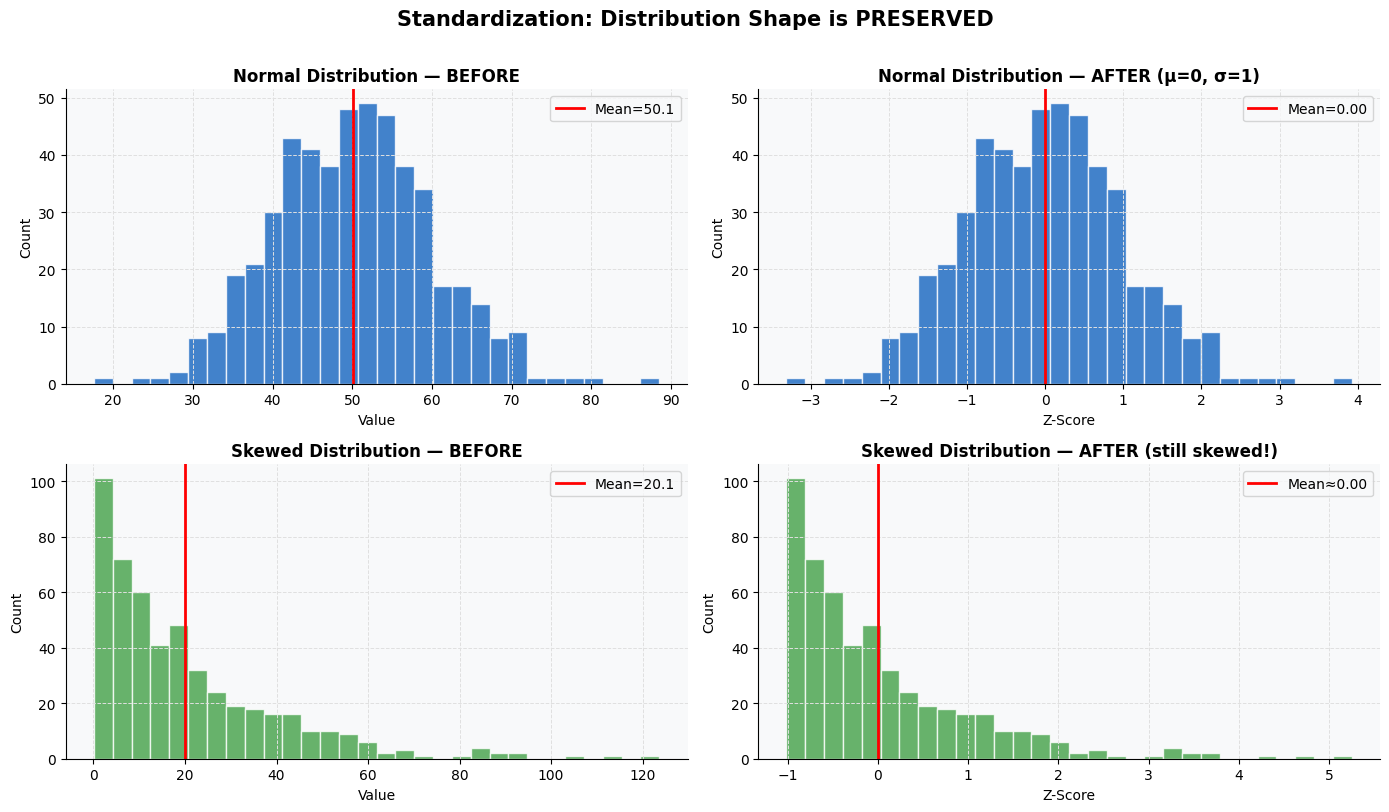

✅ Key Insight: Standardization shifts and scales but NEVER changes the shape!


In [4]:
# ─────────────────────────────────────────────────────────────────────
# Example 3: Visualizing Standardization — distribution shape preserved
# ─────────────────────────────────────────────────────────────────────
np.random.seed(42)
data_normal = np.random.normal(loc=50, scale=10, size=500)
data_skewed = np.random.exponential(scale=20, size=500)

scaler3 = StandardScaler()
normal_std = scaler3.fit_transform(data_normal.reshape(-1, 1)).flatten()

scaler4 = StandardScaler()
skewed_std = scaler4.fit_transform(data_skewed.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    'Standardization: Distribution Shape is PRESERVED',
    fontsize=15,
    fontweight='bold',
    y=1.01,
)

colors = ['#1565c0', '#43a047']

axes[0, 0].hist(data_normal, bins=30, color=colors[0], alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Normal Distribution — BEFORE', fontweight='bold')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(
    data_normal.mean(), color='red', lw=2, label=f'Mean={data_normal.mean():.1f}'
)
axes[0, 0].legend()

axes[0, 1].hist(normal_std, bins=30, color=colors[0], alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Normal Distribution — AFTER (μ=0, σ=1)', fontweight='bold')
axes[0, 1].set_xlabel('Z-Score')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(0, color='red', lw=2, label='Mean=0.00')
axes[0, 1].legend()

axes[1, 0].hist(data_skewed, bins=30, color=colors[1], alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Skewed Distribution — BEFORE', fontweight='bold')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(
    data_skewed.mean(), color='red', lw=2, label=f'Mean={data_skewed.mean():.1f}'
)
axes[1, 0].legend()

axes[1, 1].hist(skewed_std, bins=30, color=colors[1], alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Skewed Distribution — AFTER (still skewed!)', fontweight='bold')
axes[1, 1].set_xlabel('Z-Score')
axes[1, 1].set_ylabel('Count')
axes[1, 1].axvline(0, color='red', lw=2, label='Mean≈0.00')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
print("✅ Key Insight: Standardization shifts and scales but NEVER changes the shape!")

---
## 📌 1.2 Min-Max Normalization

<div style="background: #e8f5e9; border-left: 5px solid #2e7d32; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Goal:</b> Rescale features to a <b>fixed range [0, 1]</b>.
</div>

### Formula
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### 🐍 Python Code
```python
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['age_norm', 'salary_norm']] = scaler.fit_transform(df[['age', 'salary']])
```

### Key Properties
| Property | Value |
|---|---|
| Output Range | **[0, 1]** (default) |
| Minimum value → | **0** |
| Maximum value → | **1** |
| Sensitive to Outliers | **HIGH ⚠️** |

> ⚠️ **Outlier Warning:** If an extreme outlier is the max, all other values get compressed into a tiny sub-range near 0. Use with caution on data with outliers!

### 🎯 Best For
- Algorithms that rely on **distances or gradients**: neural networks, k-means, k-NN
- When features have **different units/scales** but you want them comparable
- When data has **no significant outliers**


In [5]:
from sklearn.preprocessing import MinMaxScaler

# Example 1: Basic min-max
df_mm_vals = pd.DataFrame(
    {
        'Temperature': [10, 15, 20, 25, 30, 35],
        'Pressure': [99, 103, 101, 101.3, 100, 103],
        'Humidity': [50, 40, 60, 68, 75, 80],
        'Wind': [1, 2, 3, 5.2, 7, 4],
    }
)

scaler_mm = MinMaxScaler()
normalized = scaler_mm.fit_transform(df_mm_vals)  # Out: <class 'numpy.ndarray'>
df_norm = pd.DataFrame(normalized, columns=df_mm_vals.columns).round(4)

print("Min-Max Normalization — Weather Features")
print("=" * 55)
print("BEFORE:")
print(df_mm_vals.to_string(index=False))
print(f"\nMin of each column: {df_mm_vals.min().to_dict()}")
print(f"Max of each column: {df_mm_vals.max().to_dict()}")

print("\nAFTER (all values in [0, 1]):")
print(df_norm.to_string(index=False))
print(f"\nMin of each column: {df_norm.min().to_dict()}")
print(f"Max of each column: {df_norm.max().to_dict()}")

Min-Max Normalization — Weather Features
BEFORE:
 Temperature  Pressure  Humidity  Wind
          10      99.0        50   1.0
          15     103.0        40   2.0
          20     101.0        60   3.0
          25     101.3        68   5.2
          30     100.0        75   7.0
          35     103.0        80   4.0

Min of each column: {'Temperature': 10.0, 'Pressure': 99.0, 'Humidity': 40.0, 'Wind': 1.0}
Max of each column: {'Temperature': 35.0, 'Pressure': 103.0, 'Humidity': 80.0, 'Wind': 7.0}

AFTER (all values in [0, 1]):
 Temperature  Pressure  Humidity   Wind
         0.0     0.000     0.250 0.0000
         0.2     1.000     0.000 0.1667
         0.4     0.500     0.500 0.3333
         0.6     0.575     0.700 0.7000
         0.8     0.250     0.875 1.0000
         1.0     1.000     1.000 0.5000

Min of each column: {'Temperature': 0.0, 'Pressure': 0.0, 'Humidity': 0.0, 'Wind': 0.0}
Max of each column: {'Temperature': 1.0, 'Pressure': 1.0, 'Humidity': 1.0, 'Wind': 1.0}


In [6]:
# Example 2: Outlier problem with Min-Max
df_outlier = pd.DataFrame({'Score': [60, 62, 58, 65, 63, 200]})  # 200 = outlier

scaler_mm2 = MinMaxScaler()
df_outlier['Score_minmax'] = scaler_mm2.fit_transform(df_outlier[['Score']])
df_outlier = df_outlier.round(4)

print("Min-Max with Outlier Problem:")
print(df_outlier.to_string(index=False))
print("\n⚠️  All 'normal' scores (58-65) compressed into [0.00 – 0.04]!")
print("The outlier 200 maps to 1.0 and DOMINATES the entire scale.")

Min-Max with Outlier Problem:
 Score  Score_minmax
    60        0.0141
    62        0.0282
    58        0.0000
    65        0.0493
    63        0.0352
   200        1.0000

⚠️  All 'normal' scores (58-65) compressed into [0.00 – 0.04]!
The outlier 200 maps to 1.0 and DOMINATES the entire scale.


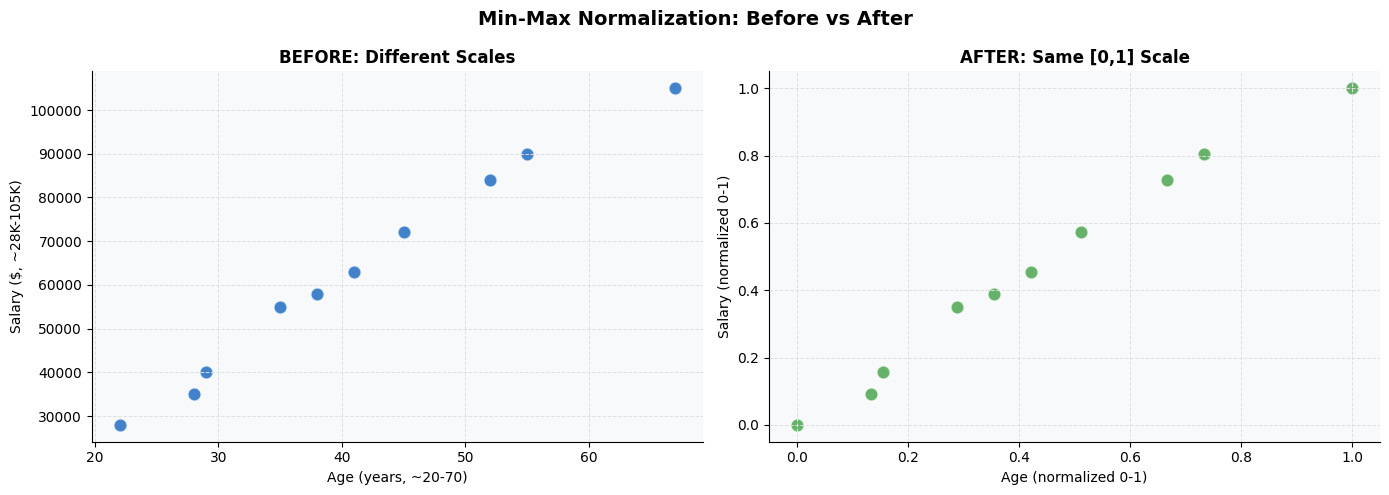

In [7]:
# Example 3: Visualize Min-Max
np.random.seed(42)
ages = np.array([22, 35, 45, 55, 28, 67, 41, 38, 52, 29])
salaries = np.array(
    [28000, 55000, 72000, 90000, 35000, 105000, 63000, 58000, 84000, 40000]
)

df_vis = pd.DataFrame({'Age': ages, 'Salary': salaries})
scaler_vis = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler_vis.fit_transform(df_vis), columns=['Age_norm', 'Salary_norm']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Min-Max Normalization: Before vs After', fontsize=14, fontweight='bold')

axes[0].scatter(
    df_vis['Age'],
    df_vis['Salary'],
    color='#1565c0',
    s=100,
    alpha=0.8,
    edgecolors='white',
    lw=1.5,
)
axes[0].set_title('BEFORE: Different Scales', fontweight='bold')
axes[0].set_xlabel('Age (years, ~20-70)')
axes[0].set_ylabel('Salary ($, ~28K-105K)')

axes[1].scatter(
    df_scaled['Age_norm'],
    df_scaled['Salary_norm'],
    color='#43a047',
    s=100,
    alpha=0.8,
    edgecolors='white',
    lw=1.5,
)
axes[1].set_title('AFTER: Same [0,1] Scale', fontweight='bold')
axes[1].set_xlabel('Age (normalized 0-1)')
axes[1].set_ylabel('Salary (normalized 0-1)')
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

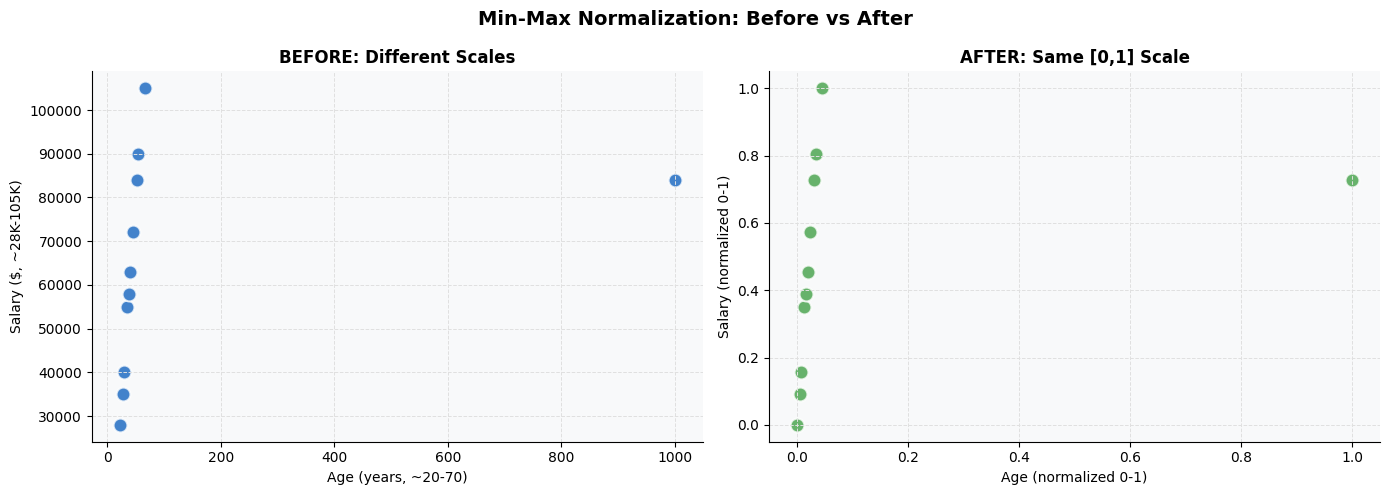

In [8]:
# Example 4: Visualize Min-Max with Outlier
np.random.seed(42)
ages = np.array([22, 35, 45, 55, 28, 67, 41, 38, 52, 29, 1000])  # 1000 is an outlier
salaries = np.array(
    [28000, 55000, 72000, 90000, 35000, 105000, 63000, 58000, 84000, 40000, 84000]
)

df_vis = pd.DataFrame({'Age': ages, 'Salary': salaries})
scaler_vis = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler_vis.fit_transform(df_vis), columns=['Age_norm', 'Salary_norm']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Min-Max Normalization: Before vs After', fontsize=14, fontweight='bold')

axes[0].scatter(
    df_vis['Age'],
    df_vis['Salary'],
    color='#1565c0',
    s=100,
    alpha=0.8,
    edgecolors='white',
    lw=1.5,
)
axes[0].set_title('BEFORE: Different Scales', fontweight='bold')
axes[0].set_xlabel('Age (years, ~20-70)')
axes[0].set_ylabel('Salary ($, ~28K-105K)')

axes[1].scatter(
    df_scaled['Age_norm'],
    df_scaled['Salary_norm'],
    color='#43a047',
    s=100,
    alpha=0.8,
    edgecolors='white',
    lw=1.5,
)
axes[1].set_title('AFTER: Same [0,1] Scale', fontweight='bold')
axes[1].set_xlabel('Age (normalized 0-1)')
axes[1].set_ylabel('Salary (normalized 0-1)')
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

---
## 📌 1.3 Robust Scaling

<div style="background: #fff3e0; border-left: 5px solid #e65100; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Goal:</b> Like Z-score, but uses <b>median</b> and <b>Interquartile Range (IQR)</b> instead of mean and std, making it <b>resistant to outliers</b>.
</div>

### Formula
$$x_{robust} = \frac{x - \text{median}}{\text{IQR}} \quad \text{where} \quad \text{IQR} = Q_3 - Q_1$$

- **Median** = 50th percentile
- **IQR** = 75th percentile (Q3) − 25th percentile (Q1)

### 🐍 Python Code
```python
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[['age_r', 'salary_r']] = scaler.fit_transform(df[['age', 'salary']])
```

### Key Properties
| Property | Value |
|---|---|
| Range | **Unbounded** |
| Centers at | **Median** |
| Scales by | **IQR** |
| Sensitive to Outliers | **LOW ✅** |
| Preserves Shape | **Yes** |

### 🎯 Best For
- Data **with outliers** that you cannot remove
- Keeps distribution shape but reduces outlier influence


In [9]:
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler

# Dataset WITH outliers
data_with_outliers = pd.DataFrame(
    {
        'Salary': [
            30000,
            35000,
            32000,
            38000,
            31000,
            36000,
            33000,
            500000,
        ]  # 500K = outlier
    }
)

std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
rob_scaler = RobustScaler()

data_with_outliers['Z-Score'] = std_scaler.fit_transform(data_with_outliers[['Salary']])
data_with_outliers['Min-Max'] = mm_scaler.fit_transform(data_with_outliers[['Salary']])
data_with_outliers['Robust'] = rob_scaler.fit_transform(data_with_outliers[['Salary']])
data_with_outliers = data_with_outliers.round(4)

print("\nComparison of Scaling Methods on Data WITH Outlier:")
print("=" * 80)
print(data_with_outliers.to_string(index=False))
print("\n📊 Observations:")
print(
    f"  • Z-Score:  Normal salaries → small values, outlier → {data_with_outliers['Z-Score'][7]} (detectable but pulled)"
)
print(
    "  • Min-Max:  Normal salaries ALL compressed to [0.00 – 0.02]! Outlier=1.0 dominates"
)
print(
    f"  • Robust:   Normal salaries span sensible range, outlier={data_with_outliers['Robust'][7]} (clearly separated)"
)
print("\n✅ Robust scaling is BEST when your data contains outliers!")


print('\nStats of all Columns:')
salary_stats = data_with_outliers['Salary'].describe().round(2)
salary_stats['IQR'] = salary_stats['75%'] - salary_stats['25%']

zscore_stats = data_with_outliers['Z-Score'].describe().round(2)
zscore_stats['IQR'] = zscore_stats['75%'] - zscore_stats['25%']

minmax_stats = data_with_outliers['Min-Max'].describe().round(2)
minmax_stats['IQR'] = minmax_stats['75%'] - minmax_stats['25%']

robust_stats = data_with_outliers['Robust'].describe().round(2)
robust_stats['IQR'] = robust_stats['75%'] - robust_stats['25%']

stats = pd.DataFrame(
    {
        'Salary': salary_stats,
        'Z-Score': zscore_stats,
        'Min-Max': minmax_stats,
        'Robust': robust_stats,
    }
)
print(stats.to_string())


Comparison of Scaling Methods on Data WITH Outlier:
 Salary  Z-Score  Min-Max  Robust
  30000  -0.4011   0.0000 -0.8421
  35000  -0.3687   0.0106  0.2105
  32000  -0.3881   0.0043 -0.4211
  38000  -0.3492   0.0170  0.8421
  31000  -0.3946   0.0021 -0.6316
  36000  -0.3622   0.0128  0.4211
  33000  -0.3816   0.0064 -0.2105
 500000   2.6454   1.0000 98.1053

📊 Observations:
  • Z-Score:  Normal salaries → small values, outlier → 2.6454 (detectable but pulled)
  • Min-Max:  Normal salaries ALL compressed to [0.00 – 0.02]! Outlier=1.0 dominates
  • Robust:   Normal salaries span sensible range, outlier=98.1053 (clearly separated)

✅ Robust scaling is BEST when your data contains outliers!

Stats of all Columns:
          Salary  Z-Score  Min-Max  Robust
count       8.00     8.00     8.00    8.00
mean    91875.00    -0.00     0.13   12.18
std    164928.93     1.07     0.35   34.72
min     30000.00    -0.40     0.00   -0.84
25%     31750.00    -0.39     0.00   -0.47
50%     34000.00    -0.3

TRYING DIFFERENT OUTLIER RANGES OF Z-SCORE:

ROWS OF abs(Z-Score) > 2:
 Original  Standardized (Z-Score)  Min-Max    Robust
 250000.0                9.356496      1.0 22.776169

ROWS OF abs(Z-Score) > 3:
 Original  Standardized (Z-Score)  Min-Max    Robust
 250000.0                9.356496      1.0 22.776169
TRYING DIFFERENT OUTLIER RANGES OF ROBUST:

ROWS OF abs(ROBUST) > 1.5:
     Original  Standardized (Z-Score)  Min-Max    Robust
 62633.702524                0.538658 0.152027  1.518520
 34693.758043               -0.776252 0.025578 -1.651407
 64818.225476                0.641466 0.161914  1.766365
 34322.639009               -0.793718 0.023899 -1.693512
 35895.678757               -0.719687 0.031018 -1.515043
 62517.149247                0.533173 0.151500  1.505297
 29042.039167               -1.042234 0.000000 -2.292623
 34099.448683               -0.804222 0.022889 -1.718834
250000.000000                9.356496 1.000000 22.776169

ROWS OF abs(ROBUST) > 3:
 Original  Standardized

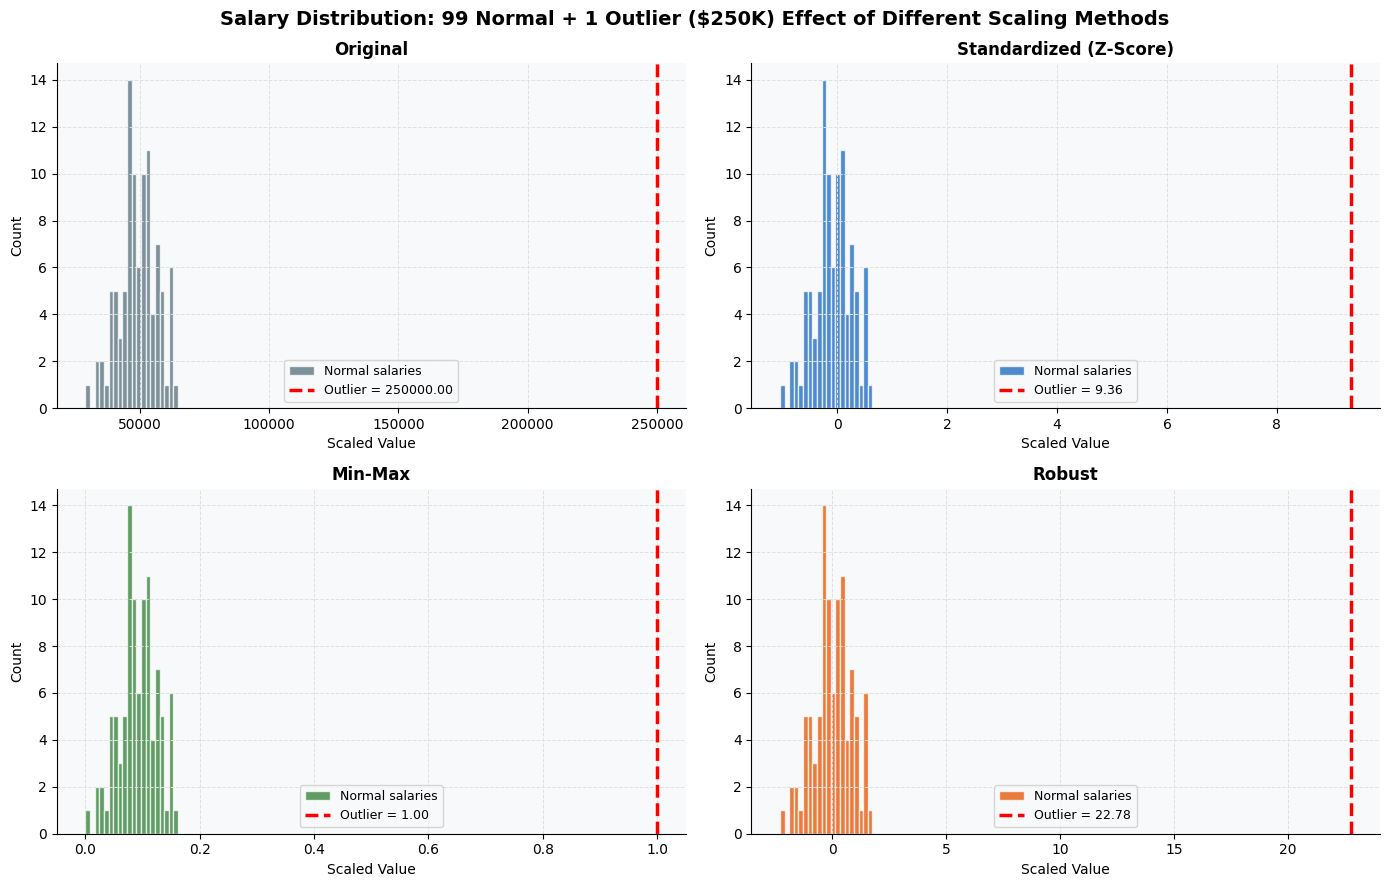

In [10]:
# ─── Visual comparison: all 3 scalers ────────────────────────────────────────
np.random.seed(42)
salaries = np.concatenate([np.random.normal(50000, 8000, 99), [250000]])

scalers_dict = {
    'Original': salaries,
    'Standardized (Z-Score)': StandardScaler()
    .fit_transform(salaries.reshape(-1, 1))
    .flatten(),
    'Min-Max': MinMaxScaler().fit_transform(salaries.reshape(-1, 1)).flatten(),
    'Robust': RobustScaler().fit_transform(salaries.reshape(-1, 1)).flatten(),
}
scalers_df = pd.DataFrame(scalers_dict)
print('TRYING DIFFERENT OUTLIER RANGES OF Z-SCORE:')

print('\nROWS OF abs(Z-Score) > 2:')
print(scalers_df[abs(scalers_df['Standardized (Z-Score)']) > 2].to_string(index=False))
print('\nROWS OF abs(Z-Score) > 3:')
print(scalers_df[abs(scalers_df['Standardized (Z-Score)']) > 3].to_string(index=False))

print('TRYING DIFFERENT OUTLIER RANGES OF ROBUST:')

print('\nROWS OF abs(ROBUST) > 1.5:')
print(scalers_df[abs(scalers_df['Robust']) > 1.5].to_string(index=False))
print('\nROWS OF abs(ROBUST) > 3:')
print(scalers_df[abs(scalers_df['Robust']) > 3].to_string(index=False))


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Salary Distribution: 99 Normal + 1 Outlier ($250K) Effect of Different Scaling Methods',
    fontsize=14,
    fontweight='bold',
)

colors_4 = ['#546e7a', '#1565c0', '#2e7d32', '#e65100']
for ax, (title, vals), color in zip(axes.flatten(), scalers_dict.items(), colors_4):
    ax.hist(
        vals[:-1],
        bins=20,
        color=color,
        alpha=0.75,
        edgecolor='white',
        label='Normal salaries',
    )
    ax.axvline(
        vals[-1],
        color='red',
        linewidth=2.5,
        linestyle='--',
        label=f'Outlier = {vals[-1]:.2f}',
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Scaled Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 📊 Feature Scaling — Comparison Summary

| Method | The Zero | Scales by | Range | Outlier Sensitivity | Use Case |
|--------|-----------|-----------|-------|-------------------|----------|
| **StandardScaler** | Mean (0) | Std Dev (1) | Unbounded | Moderate | Normal distributions, distance-based algorithms |
| **MinMaxScaler** | Min (0) | Max - Min | **[0, 1]** | **High** ⚠️ | Bounded ranges, neural networks |
| **RobustScaler** | Median (0) | IQR (1) | Unbounded | **Low** ✅ | Data with outliers |

> ⚠️ **Golden Rule:** **Always `fit` on training data only, then `transform` both train and test!**
```python
scaler.fit(X_train)        # Learn parameters from train only
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # Use same parameters!
```


**From Outliers Perspective**:

| Scaler | Non-Outlier Range | Notes |
|---|---|---|
| **StandardScaler** | -2 to +2 *, or less strict  -3 to +3* | Based on mean & std; values beyond ±2 or ±3 are typically outliers |
| **MinMaxScaler** | 0 to 1 | Outliers compress all other values into a tiny range |
| **RobustScaler** | -1.5 to +1.5 *, or less strict  -3 to +3* | Based on IQR (Q3–Q1); IQR itself maps to range of 1 |

**Does the output of robust scalar always have Median = 0 and IQR = 1?**

Yes, always. That's exactly what RobustScaler does by design:

`scaled = (x - median) / IQR`

- Subtracting **median** → shifts median to **0**
- Dividing by **IQR** → scales IQR to **1**

So after scaling, **median = 0** and **IQR = 1** are guaranteed, always.

Similarly, The output of **standard scalar (z-score)** has **Mean = 0** and **Std = 1**.

---
<div style="background: linear-gradient(90deg, #1b5e20, #2e7d32); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">🏷️ Topic 2: Feature Encoding</h1>
</div>

> *"Many machine learning algorithms can support categorical values without further manipulation but there are many more algorithms that do not."*

**Feature Encoding** converts discrete categories or groups into **numerical form** so that machine learning algorithms can process them.

### Types of Categorical Variables

| Type | Description | Examples |
|------|-------------|---------|
| **Nominal** | No inherent order | Color (red, blue, green), city names |
| **Ordinal** | Natural ordering exists | Education (HS < BS < MS < PhD), satisfaction (low/medium/high) |
| **Binary** | Only two categories | gender (M/F), yes/no |


---
## 📌 2.1 One-Hot Encoding

<div style="background: #e8f5e9; border-left: 5px solid #2e7d32; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Creates binary columns (0/1) for each unique category.</b><br>
  For <code>k</code> unique categories, one-hot encoding creates <code>k-1</code> new binary columns (when <code>drop_first=True</code>).
</div>

### 🐍 Python Code
```python
df_encoded = pd.get_dummies(df, columns=['Color', 'Size'], drop_first=True)
```

### Parameters of `pd.get_dummies()`
| Parameter | Type | Description |
|-----------|------|-------------|
| `data` | DataFrame | Input data |
| `columns` | list | Columns to encode |
| `drop_first` | bool | Drop first category to avoid multicollinearity (dummy variable trap) |
| `dtype` | type | Output dtype (default: bool in pandas 3+, use `dtype=int`) |
| `prefix` | str/list | Prefix for new column names |

### ✅ Pros and ⚠️ Cons
| ✅ Pros | ⚠️ Cons |
|---------|---------|
| No artificial ordering | Curse of dimensionality (many categories = many columns) |
| Works with all algorithms | Memory-intensive for high cardinality |

### 🎯 Best For: Nominal variables, low cardinality (< 10–15 categories), linear models, neural networks
> ⚠️ **Use `drop_first=True`** to avoid multicollinearity (dummy variable trap)!

In pandas, drop_first=True drops the first category alphabetically.


In [11]:
# Example 1: Color Encoding — basic demonstration
df_color = pd.DataFrame(
    {
        'Product': ['Shirt A', 'Shirt B', 'Shirt C', 'Shirt D', 'Shirt E'],
        'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
        'Size': ['S', 'M', 'L', 'M', 'S'],
    }
)
print("Original DataFrame:")
print(df_color.to_string(index=False))

# Without drop_first (k columns)
df_ohe_full = pd.get_dummies(df_color, columns=['Color', 'Size'], dtype=int)
print("\nAfter One-Hot Encoding (drop_first=False — ALL categories):")
print(df_ohe_full.to_string(index=False))

# With drop_first (k-1 columns — avoids multicollinearity)
df_ohe = pd.get_dummies(df_color, columns=['Color', 'Size'], drop_first=True, dtype=int)
print("\nAfter One-Hot Encoding (drop_first=True — avoids multicollinearity):")
print(df_ohe.to_string(index=False))
print(
    "\n💡 'First of Color and Size alphabetically (Blue, L) are the DROPPED reference categories (can be inferred when all others = 0)"
)

Original DataFrame:
Product Color Size
Shirt A   Red    S
Shirt B  Blue    M
Shirt C Green    L
Shirt D   Red    M
Shirt E  Blue    S

After One-Hot Encoding (drop_first=False — ALL categories):
Product  Color_Blue  Color_Green  Color_Red  Size_L  Size_M  Size_S
Shirt A           0            0          1       0       0       1
Shirt B           1            0          0       0       1       0
Shirt C           0            1          0       1       0       0
Shirt D           0            0          1       0       1       0
Shirt E           1            0          0       0       0       1

After One-Hot Encoding (drop_first=True — avoids multicollinearity):
Product  Color_Green  Color_Red  Size_M  Size_S
Shirt A            0          1       0       1
Shirt B            0          0       1       0
Shirt C            1          0       0       0
Shirt D            0          1       1       0
Shirt E            0          0       0       1

💡 'First of Color and Size alphabetica

In [12]:
# Example 2: When to use and when NOT to use
# ─ Low Cardinality (good for OHE) : OHE = One-Hot Encoding
df_low = pd.DataFrame(
    {'Season': ['Spring', 'Summer', 'Fall', 'Winter', 'Spring', 'Fall']}
)
print(f'Number of unique seasons nunique(): {df_low['Season'].nunique()}')
df_low_enc = pd.get_dummies(df_low, columns=['Season'], drop_first=True, dtype=int)
print("Low Cardinality (4 categories) — OK for One-Hot:")
print(df_low_enc.to_string(index=False))

# ─ High Cardinality (bad for OHE)
print("\n⚠️  High Cardinality Example:")
countries = [
    'Egypt',
    'USA',
    'UK',
    'France',
    'Germany',
    'Japan',
    'China',
    'Brazil',
    'India',
    'Australia',
    'Canada',
    'Mexico',
    'Russia',
    'Italy',
    'Spain',
    'South Korea',
    'Argentina',
    'Turkey',
    'Saudi Arabia',
    'UAE',
]
df_high = pd.DataFrame({'Country': countries})
print(f'Number of unique countries nunique(): {df_high['Country'].nunique()}')
df_high_enc = pd.get_dummies(df_high, columns=['Country'], drop_first=True, dtype=int)
print(f"  20 countries → creates {df_high_enc.shape[1]} columns!")
print(
    "  This is the 'CURSE OF DIMENSIONALITY' — avoid OHE for high-cardinality features!"
)

Number of unique seasons nunique(): 4
Low Cardinality (4 categories) — OK for One-Hot:
 Season_Spring  Season_Summer  Season_Winter
             1              0              0
             0              1              0
             0              0              0
             0              0              1
             1              0              0
             0              0              0

⚠️  High Cardinality Example:
Number of unique countries nunique(): 20
  20 countries → creates 19 columns!
  This is the 'CURSE OF DIMENSIONALITY' — avoid OHE for high-cardinality features!


---
## 📌 2.2 Label Encoding

<div style="background: #fff3e0; border-left: 5px solid #e65100; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Assigns a unique integer to each category.</b><br>
  Simpler than one-hot encoding but can introduce <b>unintended ordinal relationships</b>.
</div>

### 🐍 Python Code
```python
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['education'])
```

### ✅ When to Use Label Encoding
1. **Tree-based algorithms**: Decision Trees, Random Forests, Gradient Boosting
2. **Ordinal variables**: When natural ordering exists and should be preserved
3. **High cardinality**: When one-hot encoding would create too many columns

> ⚠️ **Danger:** Label encoding can make linear models interpret Red=0, Blue=1, Green=2 as "Green > Blue > Red", which has no real meaning!


In [13]:
from sklearn.preprocessing import LabelEncoder

# Example 1: CORRECT use — Ordinal variable (Education Level)
df_edu = pd.DataFrame(
    {
        'Student': ['Ali', 'Mona', 'Karim', 'Sara', 'Omar', 'Laila'],
        'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor', 'Master'],
    }
)

# For ordinal, we want custom mapping (not alphabetical!)
edu_order = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
df_edu['Education_encoded'] = df_edu['Education'].map(edu_order)
print("✅ CORRECT: Ordinal Encoding (preserves meaningful order)")
print(df_edu.to_string(index=False))
print("\nOrder: High School(0) < Bachelor(1) < Master(2) < PhD(3) — meaningful!")

✅ CORRECT: Ordinal Encoding (preserves meaningful order)
Student   Education  Education_encoded
    Ali High School                  0
   Mona    Bachelor                  1
  Karim      Master                  2
   Sara         PhD                  3
   Omar    Bachelor                  1
  Laila      Master                  2

Order: High School(0) < Bachelor(1) < Master(2) < PhD(3) — meaningful!


In [14]:
from sklearn.preprocessing import LabelEncoder

df_edu = pd.DataFrame(
    {
        'Student': ['Ali', 'Mona', 'Karim', 'Sara', 'Omar', 'Laila'],
        'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor', 'Master'],
    }
)

le = LabelEncoder()
df_edu['Education_encoded'] = le.fit_transform(df_edu['Education'])

print("LabelEncoder Encoding (alphabetical order):")
print(df_edu.to_string(index=False))
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_).tolist()))}")
print(
    "Order: Bachelor(0) < High School(1) < Master(2) < PhD(3) — alphabetical, NOT meaningful!"
)

LabelEncoder Encoding (alphabetical order):
Student   Education  Education_encoded
    Ali High School                  1
   Mona    Bachelor                  0
  Karim      Master                  2
   Sara         PhD                  3
   Omar    Bachelor                  0
  Laila      Master                  2

Encoding: {'Bachelor': 0, 'High School': 1, 'Master': 2, 'PhD': 3}
Order: Bachelor(0) < High School(1) < Master(2) < PhD(3) — alphabetical, NOT meaningful!


**Is there a way to pass the mapping to `LabelEncoder`?**


No, `LabelEncoder` does **not** accept a custom mapping — it always uses alphabetical order. You can't pass an order to it.

Your options:
- **`map()`** — simplest, full control ✅ (what your original code does)
- **`OrdinalEncoder`** — accepts custom category order:
```python
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
df_edu['Education_encoded'] = oe.fit_transform(df_edu[['Education']])
```

`OrdinalEncoder` is the sklearn way to pass a custom order.

In [15]:
from sklearn.preprocessing import OrdinalEncoder

df_edu = pd.DataFrame(
    {
        'Student': ['Ali', 'Mona', 'Karim', 'Sara', 'Omar', 'Laila'],
        'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor', 'Master'],
    }
)

oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
df_edu['Education_encoded'] = oe.fit_transform(df_edu[['Education']]).astype(int)

print("✅ CORRECT: Ordinal Encoding (preserves meaningful order)")
print(df_edu.to_string(index=False))
print(f"\nCategories: {dict(enumerate(oe.categories_[0]))}")
print("\nOrder: High School(0) < Bachelor(1) < Master(2) < PhD(3) — meaningful!")

✅ CORRECT: Ordinal Encoding (preserves meaningful order)
Student   Education  Education_encoded
    Ali High School                  0
   Mona    Bachelor                  1
  Karim      Master                  2
   Sara         PhD                  3
   Omar    Bachelor                  1
  Laila      Master                  2

Categories: {0: 'High School', 1: 'Bachelor', 2: 'Master', 3: 'PhD'}

Order: High School(0) < Bachelor(1) < Master(2) < PhD(3) — meaningful!


In [16]:
# Example 2: RISKY use — Nominal variable (Color) with LabelEncoder
df_color2 = pd.DataFrame(
    {
        'Product': ['A', 'B', 'C', 'D', 'E', 'F'],
        'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue', 'Green'],
    }
)

le = LabelEncoder()
df_color2['Color_label'] = le.fit_transform(df_color2['Color'])
print("⚠️  RISKY: Label Encoding applied to Nominal variable (Color)")
print(df_color2.to_string(index=False))
print(f"\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_).tolist()))}")
print(
    "\n❌ Problem: A linear model might think Green(1) > Blue(0), which is MEANINGLESS!"
)
print("   For nominal variables, use One-Hot Encoding instead!")

⚠️  RISKY: Label Encoding applied to Nominal variable (Color)
Product Color  Color_label
      A   Red            2
      B  Blue            0
      C Green            1
      D   Red            2
      E  Blue            0
      F Green            1

Encoding: {'Blue': 0, 'Green': 1, 'Red': 2}

❌ Problem: A linear model might think Green(1) > Blue(0), which is MEANINGLESS!
   For nominal variables, use One-Hot Encoding instead!


<p style="color: steelblue; font-size: 1.5em;">Side Notes</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:0.8em">

**1. LabelEncoder vs OrdinalEncoder**

| | LabelEncoder | OrdinalEncoder |
|---|---|---|
| **Input** | 1D (`Series`) | 2D (`DataFrame`) |
| **Custom order** | ❌ always alphabetical | ✅ via `categories=` |
| **Output** | 1D array | 2D array |
| **Use for** | target/label column | feature columns |

---

**2. `.classes_` vs `.categories_`**

| | `.classes_` | `.categories_` |
|---|---|---|
| **Belongs to** | `LabelEncoder` | `OrdinalEncoder` |
| **Type** | 1D array | list of arrays (one per feature) |
| **Access** | `le.classes_` | `oe.categories_[0]` (for first feature) |

---

**3. Getting `{label: encoding}` dict**

**LabelEncoder:**
```python
dict(zip(le.classes_, le.transform(le.classes_).tolist()))
# {'Bachelor': 0, 'High School': 1, 'Master': 2, 'PhD': 3}
```

**OrdinalEncoder:**
```python
dict(enumerate(oe.categories_[0]))
# {0: 'High School', 1: 'Bachelor', 2: 'Master', 3: 'PhD'}
```

---

**4. `df['col']` vs `df[['col']]`**

| | `df['col']` | `df[['col']]` |
|---|---|---|
| **Type** | `Series` | `DataFrame` |
| **Dimensions** | 1D `(n,)` | 2D `(n, 1)` |
| **Use for** | most pandas ops | sklearn (requires 2D input) |

</div>

---
## 📌 2.3 Target Encoding (Mean Encoding)

<div style="background: #fce4ec; border-left: 5px solid #c62828; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Replaces categorical values with the <em>mean of the target variable</em> for that category.</b><br>
  Powerful but requires careful implementation to avoid <b>data leakage</b>!
</div>

### Example
| City | Sales | Target-Encoded City |
|------|-------|---------------------|
| New York | 50000 | 52500 ← mean of all NY sales |
| New York | 55000 | 52500 |
| Boston | 30000 | 31000 ← mean of all Boston sales |
| Boston | 32000 | 31000 |

### ✅ Best For
- High cardinality features
- Strong relationship between category and target

### ⚠️ Data Leakage Warning
> **Must use cross-validation or a held-out set** — computing the mean on the full dataset leaks target information!


In [17]:
# Example 1: Basic Target Encoding
df_city = pd.DataFrame(
    {
        'City': [
            'New York',
            'New York',
            'Boston',
            'Boston',
            'Chicago',
            'Chicago',
            'New York',
        ],
        'Sales': [50000, 55000, 30000, 32000, 45000, 47000, 52000],
    }
)

# Calculate mean Sales per City
city_means = df_city.groupby('City')['Sales'].mean()
print("Step 1 — Mean Sales per City:")
print(
    city_means.to_frame().to_string()
)  # NOTE: City is the index, Sales avg is a column

df_city['City_target_encoded'] = df_city['City'].map(city_means)  # Use map()
print("\nStep 2 — Replace City with its mean:")
print(df_city.to_string(index=False))

Step 1 — Mean Sales per City:
                 Sales
City                  
Boston    31000.000000
Chicago   46000.000000
New York  52333.333333

Step 2 — Replace City with its mean:
    City  Sales  City_target_encoded
New York  50000         52333.333333
New York  55000         52333.333333
  Boston  30000         31000.000000
  Boston  32000         31000.000000
 Chicago  45000         46000.000000
 Chicago  47000         46000.000000
New York  52000         52333.333333



<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `groupby('City')` — groups all rows by city name
- `['Sales'].mean()` — for each group, calculates the mean of the Sales column → returns a Series with City as index and mean Sales as value
- `city_means` — holds `{'Boston': 31000, 'Chicago': 46000, 'New York': 52333}`
- `.to_frame()` — converts the Series to a DataFrame for prettier printing (Series prints as a single column without a header, DataFrame prints with a proper column name `Sales`)
- `.map(city_means)` — replaces each City string with its corresponding mean value from `city_means`
- `df_city['City_target_encoded']` — stores the encoded numeric column, where each city is now represented by its average Sales instead of its name

</div>

---
## 📌 2.4 Frequency Encoding

<div style="background: #e3f2fd; border-left: 5px solid #0d47a1; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Replaces each category with its <em>frequency (proportion)</em> in the dataset.</b><br>
  Preserves information about category importance and handles high-cardinality features well.
</div>

### 🐍 Python Code
```python
freq_map = df['City'].value_counts(normalize=True)  # proportion
df['City_freq'] = df['City'].map(freq_map)
```


In [18]:
# Example 1: City Frequency Encoding
df_freq = pd.DataFrame({'City': ['Cairo'] * 90 + ['Alexandria'] * 30 + ['Giza'] * 25})

# normalize=True to be percentage fractions not counts
freq_map = df_freq['City'].value_counts(normalize=True).round(2)
print("Frequency Map:")
print(type(freq_map))  # Series
print(freq_map.to_string())

df_freq['City_freq'] = df_freq['City'].map(freq_map)
print("\nSample of Frequency-Encoded DataFrame:")
print(type(df_freq))  # DataFrame
print(df_freq.drop_duplicates().to_string(index=False))

print("\n✅ Frequency encoding is the FREQUENCY itself used as a numeric feature.")

Frequency Map:
<class 'pandas.Series'>
City
Cairo         0.62
Alexandria    0.21
Giza          0.17

Sample of Frequency-Encoded DataFrame:
<class 'pandas.DataFrame'>
      City  City_freq
     Cairo       0.62
Alexandria       0.21
      Giza       0.17

✅ Frequency encoding is the FREQUENCY itself used as a numeric feature.


In [19]:
# Example 2: Frequency vs Count encoding
df_products = pd.DataFrame(
    {
        'Product': [
            'Laptop',
            'Laptop',
            'Phone',
            'Phone',
            'Phone',
            'Tablet',
            'Laptop',
            'Phone',
            'Tablet',
            'Tablet',
            'Laptop',
        ]
    }
)

count_map = df_products['Product'].value_counts()  # raw count
freq_map2 = df_products['Product'].value_counts(normalize=True)  # proportion

df_products['Count_encoded'] = df_products['Product'].map(count_map)
df_products['Freq_encoded'] = df_products['Product'].map(freq_map2).round(4)
print("Count vs Frequency Encoding:")
print(df_products.drop_duplicates().sort_values('Product').to_string(index=False))
print("\n💡 Frequency (proportion) is more robust across datasets of different sizes.")

Count vs Frequency Encoding:
Product  Count_encoded  Freq_encoded
 Laptop              4        0.3636
  Phone              4        0.3636
 Tablet              3        0.2727

💡 Frequency (proportion) is more robust across datasets of different sizes.


---
## 📌 2.5 Binary Encoding

<div style="background: #f3e5f5; border-left: 5px solid #6a1b9a; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>More compact than one-hot encoding.</b> Uses <b>log₂(n)</b> columns instead of <b>n</b> columns.<br>
  Converts label integers to binary and splits each binary digit into a separate column.
</div>

### Steps
1. Assign integer labels (Red=0, Green=1, Blue=2, Yellow=3)
2. Convert to binary (0=00, 1=01, 2=10, 3=11)
3. Split binary digits into separate columns


In [20]:
# Binary Encoding — manual demonstration
colors = ['Red', 'Green', 'Blue', 'Yellow', 'Purple', 'Orange', 'Pink', 'Black']

df_binary = pd.DataFrame({'Color': colors})
df_binary['Label'] = range(len(colors))
df_binary['Binary'] = df_binary['Label'].apply(lambda x: format(x, '03b'))
df_binary['Bit_2'] = df_binary['Label'].apply(lambda x: (x >> 2) & 1)
df_binary['Bit_1'] = df_binary['Label'].apply(lambda x: (x >> 1) & 1)
df_binary['Bit_0'] = df_binary['Label'].apply(lambda x: x & 1)

print("Binary Encoding — 8 colors using only 3 columns!")
print("=" * 60)
print(df_binary.to_string(index=False))
print(f"✅ 8 categories → 3 binary columns  (log₂(8) = 3)")
print(f"   vs One-Hot →  8 columns!")
print("Memory savings grow with more categories:")
for n in [8, 16, 32, 64, 128, 256]:
    import math

    print(
        f"   {n:4d} categories: One-Hot={n:4d} cols, Binary={math.ceil(math.log2(n)):3d} cols"
    )

Binary Encoding — 8 colors using only 3 columns!
 Color  Label Binary  Bit_2  Bit_1  Bit_0
   Red      0    000      0      0      0
 Green      1    001      0      0      1
  Blue      2    010      0      1      0
Yellow      3    011      0      1      1
Purple      4    100      1      0      0
Orange      5    101      1      0      1
  Pink      6    110      1      1      0
 Black      7    111      1      1      1
✅ 8 categories → 3 binary columns  (log₂(8) = 3)
   vs One-Hot →  8 columns!
Memory savings grow with more categories:
      8 categories: One-Hot=   8 cols, Binary=  3 cols
     16 categories: One-Hot=  16 cols, Binary=  4 cols
     32 categories: One-Hot=  32 cols, Binary=  5 cols
     64 categories: One-Hot=  64 cols, Binary=  6 cols
    128 categories: One-Hot= 128 cols, Binary=  7 cols
    256 categories: One-Hot= 256 cols, Binary=  8 cols



<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `range(len(colors))` — assigns a numeric label 0–7 to each color (Red=0, Green=1, ..., Black=7)
- `format(x, '03b')` — converts the integer to a binary string of 3 digits e.g. `5 → '101'`, `'03b'` means 3 digits, zero-padded, `format(2, '03b')` → `'010'` (zero-padded to 3 digits)
- `(x >> 2) & 1` — right-shifts x by 2 bits then masks the last bit → extracts the **leftmost** (most significant) bit
- `(x >> 1) & 1` — right-shifts x by 1 bit then masks the last bit → extracts the **middle** bit
- `x & 1` — masks the last bit directly → extracts the **rightmost** (least significant) bit
- `>> ` — bitwise right shift: moves bits to the right, dropping the rightmost bits e.g. `5 (101) >> 1 = 2 (010)`
- `& 1` — bitwise AND with 1: keeps only the last bit, always returns 0 or 1 e.g. `6 (110) & 1 = 0`, `5 (101) & 1 = 1`
- `math.ceil(math.log2(n))` — calculates minimum number of bits needed to represent n categories e.g. `log₂(8) = 3`, `log₂(10) = 3.32 → ceil → 4`
</div>

---
## 📌 2.6 Handling Rare Categories

<div style="background: #fbe9e7; border-left: 5px solid #bf360c; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Group infrequent categories into an "Other" bucket.</b><br>
  Rare categories can overfit and add noise without adding signal.
</div>

### Strategies
1. **Threshold-based**: Categories appearing < 1% (or some threshold) → `'Other'`
2. **Top-N categories**: Keep only the N most frequent categories
3. **Benefits**: Reduces dimensionality, improves model generalization


Original value counts:
            Product(freq)  Product(%)
Product                              
Laptop                400        40.0
Phone                 300        30.0
Tablet                150        15.0
Camera                 50         5.0
Smartwatch             40         4.0
Drone                  30         3.0
VR_Headset             15         1.5
Robot                  10         1.0
Gadget                  5         0.5
Total: 1000 rows

🔖 Categories below 5% threshold: ['Smartwatch', 'Drone', 'VR_Headset', 'Robot', 'Gadget']
After Threshold Strategy:
Product_grouped_threshold
Laptop    400
Phone     300
Tablet    150
Other     100
Camera     50
After Top-3 Strategy:
Product_top3
Laptop    400
Phone     300
Tablet    150
Other     150


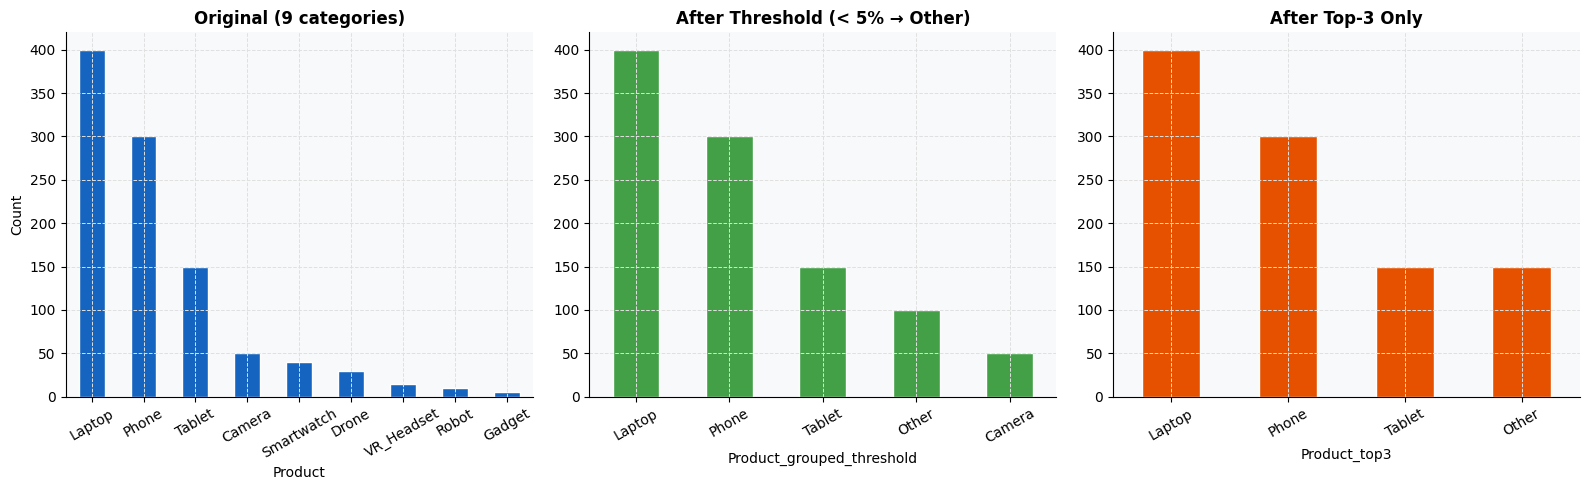

In [ ]:
# Example: Grouping rare categories
df_rare = pd.DataFrame(
    {
        'Product': ['Laptop'] * 400
        + ['Phone'] * 300
        + ['Tablet'] * 150
        + ['Camera'] * 50
        + ['Smartwatch'] * 40
        + ['Drone'] * 30
        + ['VR_Headset'] * 15
        + ['Robot'] * 10
        + ['Gadget'] * 5
    }
)

freq_counts = df_rare['Product'].value_counts()
freq_counts_df = pd.DataFrame(
    {
        'Product(freq)': df_rare['Product'].value_counts(),
        'Product(%)': df_rare['Product'].value_counts(normalize=True) * 100,
    }
)
print("Original value counts:")
print(freq_counts_df.to_string())
print(f"Total: {len(df_rare)} rows")

# Strategy 1: Threshold-based (< 5% = rare)
threshold = 0.05
freq_pct = freq_counts / len(df_rare)
rare_categories = freq_pct[freq_pct < threshold].index.tolist()
print(f"\n🔖 Categories below {threshold:.0%} threshold: {rare_categories}")

df_rare['Product_grouped_threshold'] = df_rare['Product'].apply(
    lambda x: x if x not in rare_categories else 'Other'
)

# Strategy 2: Keep Top-3 only
top3 = freq_counts.head(3).index.tolist()
# NOTE: output of value_counts() is already sorted desc by count
df_rare['Product_top3'] = df_rare['Product'].apply(
    lambda x: x if x in top3 else 'Other'
)

print("After Threshold Strategy:")
print(df_rare['Product_grouped_threshold'].value_counts().to_string())
print("After Top-3 Strategy:")
print(df_rare['Product_top3'].value_counts().to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
freq_counts.plot(kind='bar', ax=axes[0], color='#1565c0', edgecolor='white', rot=30)
axes[0].set_title('Original (9 categories)', fontweight='bold')
axes[0].set_ylabel('Count')

df_rare['Product_grouped_threshold'].value_counts().plot(
    kind='bar', ax=axes[1], color='#43a047', edgecolor='white', rot=30
)
axes[1].set_title(f'After Threshold (< {threshold:.0%} → Other)', fontweight='bold')

df_rare['Product_top3'].value_counts().plot(
    kind='bar', ax=axes[2], color='#e65100', edgecolor='white', rot=30
)
axes[2].set_title('After Top-3 Only', fontweight='bold')

plt.tight_layout()
plt.show()

<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `value_counts()` — counts occurrences of each unique value in a Series
- returns a **Series** with unique values as index and their counts as values
- sorted by **frequency descending** by default
- example:
```python
df['Color'].value_counts()
# Red      3
# Blue     2
# Green    1
```
- `normalize=True` → returns **proportions** instead of counts (0.0 to 1.0)
- `dropna=False` → includes **NaN** in the count (excluded by default)
</div>

---
<div style="background: linear-gradient(90deg, #4a148c, #6a1b9a); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">📦 Topic 3: Discretization and Binning</h1>
</div>

**Discretization** converts **continuous numerical variables** into **categorical bins**.

### 🤔 Why Discretize?
| Reason | Explanation |
|--------|-------------|
| **Reduce noise** | Smooth out small fluctuations |
| **Handle outliers** | Extreme values grouped into edge bins |
| **Capture non-linearity** | Model non-linear relationships in linear models |
| **Improve interpretability** | "Age 26–35" is easier to understand than exact ages |
| **Business requirements** | Sales tiers, customer segments |

### 💡 Non-Linearity Example
> Suppose you're predicting loan default. Very young (18–25) and very old (65+) borrowers default more; middle-aged (26–55) default less. This U-shaped relationship is **non-linear**. A linear model can't capture it directly, but **binning age into categories** lets it assign different risk per bin!

### ❌ Why NOT Discretize?
- **Information loss**: Ages 31 and 39 become identical if both fall in "30–40" bin
- **Complex models**: Tree-based models and neural networks already capture non-linearities — binning is unnecessary and may hurt performance
- **Small datasets**: Binning can make data too coarse


---
## 📌 3.1 `pd.cut()` — Equal-Width Binning

<div style="background: #e3f2fd; border-left: 5px solid #1565c0; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  Divides data into bins of <b>equal width</b> (or custom edges) based on the range of values.
</div>

### Function Signature
```python
pd.cut(x, bins, right=True, labels=None, retbins=False, precision=3, include_lowest=False)
```

### Parameters
| Parameter | Description |
|-----------|-------------|
| `x` | Input array or Series to bin |
| `bins` | Integer → number of equal-width bins; or list → custom edges |
| `right=True` | `True` → interval is `(a, b]`; `False` → `[a, b)` |
| `labels=None` | Custom labels for bins; `None` returns interval strings |
| `retbins=False` | If `True`, returns bin edges as well |
| `precision=3` | Decimal places for bin edge labels |
| `include_lowest=False` | Include the left edge of the first bin |


In [22]:
# Example 1: Equal-width binning of Ages
ages = pd.Series([5, 12, 17, 25, 34, 42, 51, 63, 72, 85, 20, 39, 58])

# Without labels
age_bins_auto = pd.cut(ages, bins=4)
print("pd.cut() with 4 equal-width bins (auto-labeled):")
print(pd.DataFrame({'Age': ages, 'Bin': age_bins_auto}).to_string(index=False))
print('\nThe Unique Bins/Categories:')
print(age_bins_auto.cat.categories)
min_age, max_age, bins = ages.min(), ages.max(), 4
print(
    f'min = {min_age}, max = {max_age}, equal bin width = {abs(min_age - max_age)/bins}'
)

# With custom edges and labels
custom_bins = [0, 18, 35, 60, 100]
custom_labels = [
    'Youth (0-18)',
    'Young Adult (18-35)',
    'Middle-Age (35-60)',
    'Senior (60+)',
]
age_bins_named = pd.cut(
    ages, bins=custom_bins, labels=custom_labels, include_lowest=True
)
print("\npd.cut() with CUSTOM edges and labels:")
print(pd.DataFrame({'Age': ages, 'AgeGroup': age_bins_named}).to_string(index=False))
print('\nThe Unique Bins/Categories:')
print(age_bins_named.cat.categories)

pd.cut() with 4 equal-width bins (auto-labeled):
 Age          Bin
   5 (4.92, 25.0]
  12 (4.92, 25.0]
  17 (4.92, 25.0]
  25 (4.92, 25.0]
  34 (25.0, 45.0]
  42 (25.0, 45.0]
  51 (45.0, 65.0]
  63 (45.0, 65.0]
  72 (65.0, 85.0]
  85 (65.0, 85.0]
  20 (4.92, 25.0]
  39 (25.0, 45.0]
  58 (45.0, 65.0]

The Unique Bins/Categories:
IntervalIndex([(4.92, 25.0], (25.0, 45.0], (45.0, 65.0], (65.0, 85.0]], dtype='interval[float64, right]')
min = 5, max = 85, equal bin width = 20.0

pd.cut() with CUSTOM edges and labels:
 Age            AgeGroup
   5        Youth (0-18)
  12        Youth (0-18)
  17        Youth (0-18)
  25 Young Adult (18-35)
  34 Young Adult (18-35)
  42  Middle-Age (35-60)
  51  Middle-Age (35-60)
  63        Senior (60+)
  72        Senior (60+)
  85        Senior (60+)
  20 Young Adult (18-35)
  39  Middle-Age (35-60)
  58  Middle-Age (35-60)

The Unique Bins/Categories:
Index(['Youth (0-18)', 'Young Adult (18-35)', 'Middle-Age (35-60)',
       'Senior (60+)'],
      dtype

<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `age_bins_auto.cat.categories` — gets the unique bin interval labels from a categorical Series
- `.cat` — accessor for categorical dtype, used **only on Series** (like `.str` for strings, `.dt` for datetimes)
- `.categories` — attribute under `.cat` that returns the unique category labels
- `.cat` works on Series only, not DataFrames — access column as Series first: `df['col'].cat.categories` ✅ vs `df.cat.categories` ❌
</div>

In [23]:
# Example 2: Salary Tiers — business use case
salaries = pd.Series([18000, 30000, 60000, 45000, 0, 75000, 90000, 100000, 180000])

salary_bins = pd.cut(
    salaries,
    bins=[0, 30000, 60000, 100000, 999999],  # 4 custom bins (5 provided, so 4 bins)
    labels=[
        'Entry [$0K-$30K]',
        'Mid ($30K-$60K]',
        'Senior ($60K-$100K]',
        'Executive ($100K+]',
    ],
    include_lowest=True,
)
df_salary = pd.DataFrame({'Salary': salaries, 'Tier': salary_bins})
print("Salary Tier Classification:")
print(df_salary.to_string(index=False))
print("\nTier distribution:")
print(salary_bins.value_counts().sort_index().to_string())

Salary Tier Classification:
 Salary                Tier
  18000    Entry [$0K-$30K]
  30000    Entry [$0K-$30K]
  60000     Mid ($30K-$60K]
  45000     Mid ($30K-$60K]
      0    Entry [$0K-$30K]
  75000 Senior ($60K-$100K]
  90000 Senior ($60K-$100K]
 100000 Senior ($60K-$100K]
 180000  Executive ($100K+]

Tier distribution:
Entry [$0K-$30K]       3
Mid ($30K-$60K]        2
Senior ($60K-$100K]    3
Executive ($100K+]     1


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">


- By default `pd.cut` uses **(left, right]** intervals — meaning the **left edge is excluded**.

- `include_lowest=True` makes the **first bin's left edge inclusive** → `[0, 30000]` instead of `(0, 30000]`

- So without `include_lowest=True`, a salary of exactly `0` would be **NaN** (falls outside all bins). With it, `0` is included in the first bin.

- `salary_bins.value_counts()` — counts how many salaries fall in each bin
- `.sort_index()` — sorts by bin order instead of frequency, since `value_counts()` sorts by count descending by default
- `.to_string()` — prints without truncation
</div>

In [24]:
# Example 3: Score Grading — equal width vs custom
scores = pd.Series([45, 52, 67, 71, 83, 90, 95, 38, 61, 77, 88])

# Equal width
grade_equal = pd.cut(scores, bins=5, labels=['F', 'D', 'C', 'B', 'A'])

# Custom (standard grading)
grade_custom = pd.cut(
    scores,
    bins=[0, 60, 70, 80, 90, 100],
    labels=['F', 'D', 'C', 'B', 'A'],
    include_lowest=True,
)

df_grades = pd.DataFrame(
    {
        'Score': scores,
        'Grade (equal-width)': grade_equal,
        'Grade (standard)': grade_custom,
    }
)
print("Score Grading — Equal Width vs Standard Grading:")
print(df_grades.to_string(index=False))
print("\n💡 Custom bins reflect BUSINESS/DOMAIN knowledge — often superior!")

Score Grading — Equal Width vs Standard Grading:
 Score Grade (equal-width) Grade (standard)
    45                   F                F
    52                   D                F
    67                   C                D
    71                   C                C
    83                   B                B
    90                   A                B
    95                   A                A
    38                   F                F
    61                   C                D
    77                   B                C
    88                   A                B

💡 Custom bins reflect BUSINESS/DOMAIN knowledge — often superior!


---
## 📌 3.2 `pd.qcut()` — Equal-Frequency Binning (Quantile-based)

<div style="background: #fff3e0; border-left: 5px solid #e65100; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  Creates bins with approximately <b>equal numbers of observations</b> by using quantiles.
</div>

### Function Signature
```python
pd.qcut(x, q, labels=None, retbins=False, precision=3, duplicates='raise')
```

### Parameters
| Parameter | Description |
|-----------|-------------|
| `x` | Input data |
| `q` | Integer → number of quantiles (4=quartiles, 10=deciles); or list of quantile thresholds |
| `labels` | Custom labels for bins |
| `duplicates` | `'raise'` or `'drop'` — handles duplicate bin edges |


In [25]:
# Example 1: Basic qcut — quartiles
data = pd.Series([52, 93, 15, 72, 61, 21, 83, 87, 75, 75])

qcut_bins = pd.qcut(data, q=4, precision=2, duplicates='drop')
cut_bins = [0, 25, 50, 75, 100]
cut_result = pd.cut(
    data,
    bins=cut_bins,
    labels=['Q1(0-25)', 'Q2(26-50)', 'Q3(51-75)', 'Q4(76-100)'],
    include_lowest=True,
)

df_compare = pd.DataFrame({'Value': data, 'cut_bin': cut_result, 'qcut_bin': qcut_bins})
print("pd.cut() vs pd.qcut() comparison:")
print(df_compare.to_string(index=False))

print("\nbin counts (pd.cut):")
print(cut_result.value_counts().sort_index().to_string())
print("\nbin counts (pd.qcut — approx equal counts):")
print(qcut_bins.value_counts().sort_index().to_string())

pd.cut() vs pd.qcut() comparison:
 Value    cut_bin       qcut_bin
    52  Q3(51-75) (14.99, 54.25]
    93 Q4(76-100)   (81.0, 93.0]
    15   Q1(0-25) (14.99, 54.25]
    72  Q3(51-75)  (54.25, 73.5]
    61  Q3(51-75)  (54.25, 73.5]
    21   Q1(0-25) (14.99, 54.25]
    83 Q4(76-100)   (81.0, 93.0]
    87 Q4(76-100)   (81.0, 93.0]
    75  Q3(51-75)   (73.5, 81.0]
    75  Q3(51-75)   (73.5, 81.0]

bin counts (pd.cut):
Q1(0-25)      2
Q2(26-50)     0
Q3(51-75)     5
Q4(76-100)    3

bin counts (pd.qcut — approx equal counts):
(14.99, 54.25]    3
(54.25, 73.5]     2
(73.5, 81.0]      2
(81.0, 93.0]      3


In [26]:
# Example 2: Income Deciles — pd.qcut use case
np.random.seed(42)
income = pd.Series(np.random.lognormal(mean=11, sigma=0.5, size=100)).astype(int)

# Quartile labels
quartiles = pd.qcut(
    income, q=4, labels=['Bottom 25%', 'Lower Mid 25%', 'Upper Mid 25%', 'Top 25%']
)
deciles = pd.qcut(income, q=10, labels=[f'D{i}' for i in range(1, 11)])

df_income = pd.DataFrame({'Income': income, 'Quartile': quartiles, 'Decile': deciles})
print("Income Distribution by Quartile:")
print(
    df_income.groupby('Quartile', observed=True)['Income']
    .agg(['count', 'min', 'max', 'mean'])
    .round(0)
    .to_string()
)
print("\n✅ Each bin has ~25 observations (equal frequency)")

Income Distribution by Quartile:
               count    min     max      mean
Quartile                                     
Bottom 25%        25  16157   44318   32702.0
Lower Mid 25%     25  44341   55874   49748.0
Upper Mid 25%     25  56510   72247   65958.0
Top 25%           25  76753  151166  102659.0

✅ Each bin has ~25 observations (equal frequency)


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `np.random.seed(42)` — sets random seed for reproducibility
- `np.random.lognormal(mean=11, sigma=0.5, size=100)` — generates 100 values from a log-normal distribution (right-skewed, like real income data)
- `.astype(int)` — converts floats to integers
- `pd.qcut(income, q=4, labels=[...])` — splits income into **4 equal-frequency** bins (quartiles), each containing ~25 values
- `pd.qcut(income, q=10, labels=[f'D{i}' for i in range(1, 11)])` — splits into **10 equal-frequency** bins (deciles), labeled D1–D10
- `[f'D{i}' for i in range(1, 11)]` — list comprehension generating `['D1', 'D2', ..., 'D10']`
- `groupby('Quartile', observed=True)` — groups by quartile; `observed=True` avoids showing empty categories that exist in the categorical dtype but have no data
- `.agg(['count', 'min', 'max', 'mean'])` — for each quartile computes count, min, max, and mean of Income in one step
- `.round(0)` — rounds all aggregated values to 0 decimal places
</div>

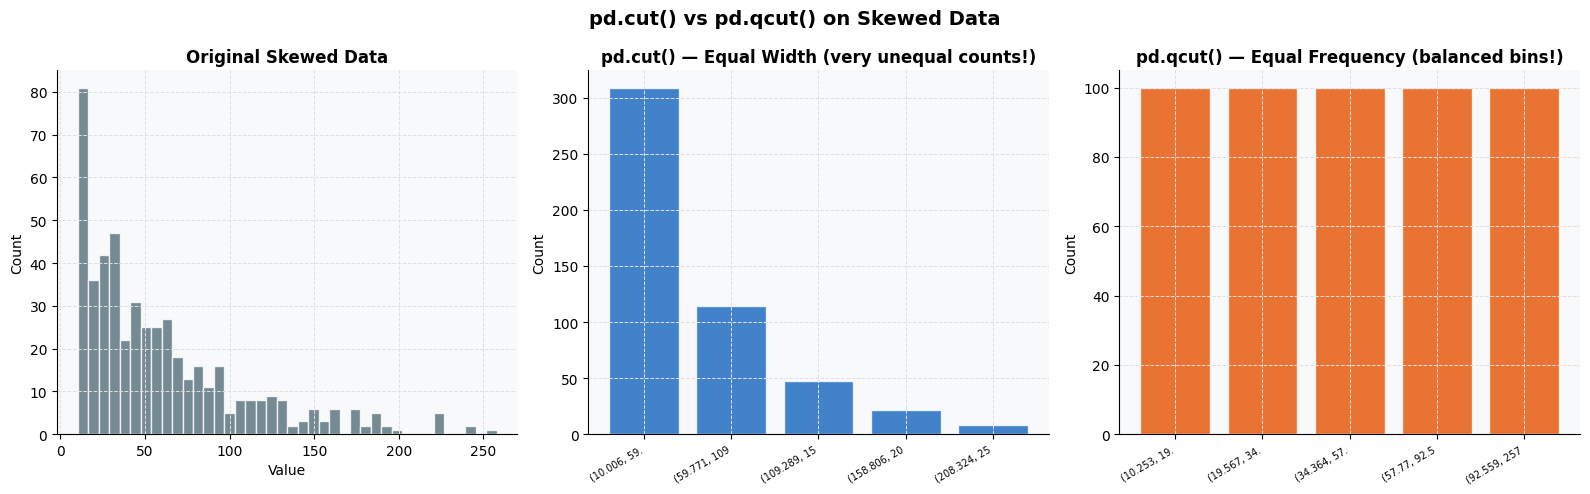


💡 For skewed data: pd.qcut() creates MORE BALANCED bins than pd.cut()
   Use pd.cut() when you need SPECIFIC ranges; pd.qcut() for balanced groups


In [27]:
# Example 3: Visualizing cut vs qcut on skewed data
np.random.seed(42)
skewed_data = pd.Series(np.random.exponential(scale=1, size=500) * 50 + 10)

cut_res = pd.cut(skewed_data, bins=5)
qcut_res = pd.qcut(skewed_data, q=5, duplicates='drop')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('pd.cut() vs pd.qcut() on Skewed Data', fontsize=14, fontweight='bold')

axes[0].hist(skewed_data, bins=40, color='#546e7a', edgecolor='white', alpha=0.8)
axes[0].set_title('Original Skewed Data', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

cut_counts = cut_res.value_counts().sort_index()
axes[1].bar(
    range(len(cut_counts)),
    cut_counts.values,
    color='#1565c0',
    edgecolor='white',
    alpha=0.8,
)
axes[1].set_xticks(range(len(cut_counts)))
axes[1].set_xticklabels(
    [str(x)[:12] for x in cut_counts.index], rotation=30, ha='right', fontsize=7
)
axes[1].set_title('pd.cut() — Equal Width (very unequal counts!)', fontweight='bold')
axes[1].set_ylabel('Count')

qcut_counts = qcut_res.value_counts().sort_index()
axes[2].bar(
    range(len(qcut_counts)),
    qcut_counts.values,
    color='#e65100',
    edgecolor='white',
    alpha=0.8,
)
axes[2].set_xticks(range(len(qcut_counts)))
axes[2].set_xticklabels(
    [str(x)[:12] for x in qcut_counts.index], rotation=30, ha='right', fontsize=7
)
axes[2].set_title('pd.qcut() — Equal Frequency (balanced bins!)', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
print("\n💡 For skewed data: pd.qcut() creates MORE BALANCED bins than pd.cut()")
print("   Use pd.cut() when you need SPECIFIC ranges; pd.qcut() for balanced groups")

---
<div style="background: linear-gradient(90deg, #e65100, #f57c00); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">⚙️ Topic 4: Feature Interactions / Engineering</h1>
</div>

> *"Sometimes the relationship between features tells us more than the features themselves."*

In machine learning, **capturing feature interactions** can dramatically improve model performance because they reveal patterns that individual features cannot express.

### Why Feature Interactions Matter

| Reason | Example |
|--------|---------|
| **Non-Linearity** | Income alone doesn't predict creditworthiness. Income × Debt × Credit History together do. |
| **Context Dependency** | High BMI is more concerning for elderly than young people. |
| **Signal Amplification** | One late payment = minor issue. Late payment + High debt + Poor credit = major red flag. |
| **Business Logic Encoding** | Domain knowledge expressed as interactions (e.g., credit scores). |
| **Model Performance** | Linear models can't discover interactions automatically. |


---
## 📌 4.1 Arithmetic Combinations

### 4.1.1 Addition and Subtraction — Aggregates and Differences
**Concept:** Combine features to create meaningful aggregates or differences.



<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**Example 1: Financial Analysis — Income Components**

- **`salary`** — primary employment income (annual)
- **`bonus`** — performance-based additional pay on top of salary
- **`investment_income`** — returns from stocks, bonds, or savings
- **`rental_income`** — income from renting out property (0 means no rental property)

Each row represents one individual with multiple income streams.
</div>

In [28]:
# Example 1: Financial Analysis — Income Components
import pandas as pd

df = pd.DataFrame(
    {
        'salary': [50000, 75000, 60000, 90000, 45000],
        'bonus': [5000, 10000, 8000, 15000, 3000],
        'investment_income': [2000, 5000, 1000, 8000, 500],
        'rental_income': [12000, 0, 6000, 20000, 0],
    }
)

# Total income - more predictive than individual components
df['total_income'] = (
    df['salary'] + df['bonus'] + df['investment_income'] + df['rental_income']
)

# Passive vs active income ratio
df['passive_income'] = df['investment_income'] + df['rental_income']
df['active_income'] = df['salary'] + df['bonus']
df['passive_to_active_ratio'] = df['passive_income'] / df['active_income']

print("Financial Feature Engineering:")
print(df.round(4).to_string(index=False))
print(
    "\n💡 A person with $69K total income but HIGH passive ratio might be better credit risk"
)
print("   than someone with $90K who depends ENTIRELY on active income.")

Financial Feature Engineering:
 salary  bonus  investment_income  rental_income  total_income  passive_income  active_income  passive_to_active_ratio
  50000   5000               2000          12000         69000           14000          55000                   0.2545
  75000  10000               5000              0         90000            5000          85000                   0.0588
  60000   8000               1000           6000         75000            7000          68000                   0.1029
  90000  15000               8000          20000        133000           28000         105000                   0.2667
  45000   3000                500              0         48500             500          48000                   0.0104

💡 A person with $69K total income but HIGH passive ratio might be better credit risk
   than someone with $90K who depends ENTIRELY on active income.



<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**Example 2: NPS (Net Promoter Score)** is a customer loyalty metric based on one question: *"How likely are you to recommend us? (0–10)"*

- **Promoters (9–10)** — loyal enthusiasts who will recommend you
- **Passives (7–8)** — satisfied but unenthusiastic, easily swayed by competitors
- **Detractors (0–6)** — unhappy customers who can damage your brand

**NPS = % Promoters − % Detractors** → ranges from -100 to +100

- **`customer_id`** — represents a **store/branch/survey batch**, not an individual customer (since each row has 45+ promoters, meaning one ID collected responses from many customers)
- **`promoters`, `passives`, `detractors`** — counts of customers who gave that rating in that batch/store's survey

So each row = one store/survey group that collected responses from ~100 customers total.
</div>

In [29]:
# Example 2: E-commerce — Net Promoter Score (NPS)
df_nps = pd.DataFrame(
    {
        'customer_id': [1, 2, 3, 4, 5],
        'promoters': [45, 30, 60, 25, 50],  # Customers who rated 9-10
        'detractors': [10, 25, 5, 30, 15],  # Customers who rated 0-6
        'passives': [45, 45, 35, 45, 35],  # Customers who rated 7-8
    }
)

df_nps['total_responses'] = (
    df_nps['promoters'] + df_nps['detractors'] + df_nps['passives']
)
df_nps['promoter_percentage'] = (df_nps['promoters'] / df_nps['total_responses']) * 100
df_nps['detractor_percentage'] = (
    df_nps['detractors'] / df_nps['total_responses']
) * 100
df_nps['nps_score'] = df_nps['promoter_percentage'] - df_nps['detractor_percentage']

print("NPS Calculation:")
print(
    df_nps[['customer_id', 'promoters', 'detractors', 'nps_score']]
    .round(1)
    .to_string(index=False)
)
print("\n💡 Customer 3 NPS=55 (excellent), Customer 4 NPS=-5 (poor)")
print("   The DIFFERENCE reveals satisfaction hidden in raw counts!")

NPS Calculation:
 customer_id  promoters  detractors  nps_score
           1         45          10       35.0
           2         30          25        5.0
           3         60           5       55.0
           4         25          30       -5.0
           5         50          15       35.0

💡 Customer 3 NPS=55 (excellent), Customer 4 NPS=-5 (poor)
   The DIFFERENCE reveals satisfaction hidden in raw counts!



<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**Example 3: Healthcare — Age-Adjusted Metrics**

- **`patient_id`** — unique identifier for each patient
- **`patient_age`** — current age of the patient in years
- **`account_age_years`** — how many years they have been registered at this healthcare provider (hospital/clinic)
- **`age_when_joined`** — how old the patient was when they first registered (current age − years as patient)
- **`loyalty_ratio`** — proportion of their life they have been with this provider (years as patient / current age) → closer to 1 means they joined very young and stayed long
</div>

In [30]:
# Example 3: Healthcare — Age-Adjusted Metrics
df_health = pd.DataFrame(
    {
        'patient_id': [1, 2, 3, 4, 5],
        'patient_age': [65, 45, 70, 50, 68],
        'account_age_years': [10, 3, 15, 8, 5],
    }
)

# How long they've been a patient relative to their age
df_health['age_when_joined'] = df_health['patient_age'] - df_health['account_age_years']
df_health['loyalty_ratio'] = df_health['account_age_years'] / df_health['patient_age']

print("Healthcare Feature Engineering:")
print(df_health.round(4).to_string(index=False))
print("\n💡 Patient 2 joined at 42 (younger, healthier)")
print("   Patient 5 joined at 63 (older, possibly with existing conditions)")
print("   This context helps predict future healthcare costs and retention.")

Healthcare Feature Engineering:
 patient_id  patient_age  account_age_years  age_when_joined  loyalty_ratio
          1           65                 10               55         0.1538
          2           45                  3               42         0.0667
          3           70                 15               55         0.2143
          4           50                  8               42         0.1600
          5           68                  5               63         0.0735

💡 Patient 2 joined at 42 (younger, healthier)
   Patient 5 joined at 63 (older, possibly with existing conditions)
   This context helps predict future healthcare costs and retention.


### 4.1.2 Multiplication and Division (Ratios)
**Concept:** Ratios normalize values and reveal relationships that raw numbers hide.

**Example 4: Real Estate — Price Efficiency Ratios**

- **`property_id`** — unique identifier for each property
- **`price`** — total listing/sale price of the property in dollars
- **`square_feet`** — indoor living area of the property
- **`bedrooms`** — number of bedrooms
- **`lot_size_sqft`** — total land area including outdoor space

Derived columns:
- **`price_per_sqft`** — how much each square foot costs → standard real estate comparison metric
- **`indoor_outdoor_ratio`** — what fraction of the lot is indoor living space → higher means less outdoor space
- **`price_per_bedroom`** — cost per bedroom → useful for comparing differently-sized homes
- **`sqft_per_bedroom`** — average size of each bedroom → measure of spaciousness

In [31]:
# Example 4: Real Estate — Price Efficiency Ratios
df_real = pd.DataFrame(
    {
        'property_id': [1, 2, 3, 4, 5],
        'price': [500000, 750000, 400000, 900000, 650000],
        'square_feet': [2000, 2500, 1500, 3500, 2200],
        'bedrooms': [3, 4, 2, 5, 3],
        'lot_size_sqft': [5000, 6000, 4000, 8000, 5500],
    }
)

df_real['price_per_sqft'] = df_real['price'] / df_real['square_feet']
df_real['indoor_outdoor_ratio'] = df_real['square_feet'] / df_real['lot_size_sqft']
df_real['price_per_bedroom'] = df_real['price'] / df_real['bedrooms']
df_real['sqft_per_bedroom'] = df_real['square_feet'] / df_real['bedrooms']

print("Real Estate Feature Engineering:")
print(
    df_real[
        ['property_id', 'price_per_sqft', 'indoor_outdoor_ratio', 'sqft_per_bedroom']
    ]
    .round(2)
    .to_string(index=False)
)
print("\n💡 These ratios allow FAIR COMPARISON across different property sizes.")
print("   Property 2 costs $300/sqft but has smallest space per bedroom (crowded).")
print("   Property 3 is cheapest per sqft but offers most space per bedroom (spacious)")

Real Estate Feature Engineering:
 property_id  price_per_sqft  indoor_outdoor_ratio  sqft_per_bedroom
           1          250.00                  0.40            666.67
           2          300.00                  0.42            625.00
           3          266.67                  0.38            750.00
           4          257.14                  0.44            700.00
           5          295.45                  0.40            733.33

💡 These ratios allow FAIR COMPARISON across different property sizes.
   Property 2 costs $300/sqft but has smallest space per bedroom (crowded).
   Property 3 is cheapest per sqft but offers most space per bedroom (spacious)


**Example 5: E-Commerce — Conversion Funnel Metrics**

- **`campaign_id`** — unique identifier for each marketing campaign (A–E)
- **`impressions`** — how many times the ad was shown to users
- **`clicks`** — how many users clicked the ad
- **`add_to_cart`** — how many users added a product to their cart after clicking
- **`purchases`** — how many users completed a purchase
- **`revenue`** — total revenue generated by the campaign

Derived columns:
- **`ctr` (Click-Through Rate)** — % of impressions that resulted in a click → measures ad effectiveness
- **`atc_rate` (Add-to-Cart Rate)** — % of clicks that resulted in adding to cart → measures landing page effectiveness
- **`purchase_rate`** — % of add-to-carts that converted to purchases → measures checkout effectiveness
- **`overall_conversion`** — % of impressions that resulted in a purchase → end-to-end funnel efficiency
- **`aov` (Average Order Value)** — average revenue per purchase → measures basket size
- **`revenue_per_click`** — how much revenue each click generates → measures traffic quality
- **`revenue_per_impression`** — how much revenue each ad impression generates → measures overall campaign ROI

In [32]:
# Example 5: E-Commerce — Conversion Funnel Metrics
df_ecom = pd.DataFrame(
    {
        'campaign_id': ['A', 'B', 'C', 'D', 'E'],
        'impressions': [100000, 80000, 120000, 90000, 110000],
        'clicks': [5000, 4800, 3600, 5400, 4400],
        'add_to_cart': [1000, 1200, 900, 1350, 1100],
        'purchases': [200, 300, 180, 270, 220],
        'revenue': [40000, 75000, 45000, 67500, 55000],
    }
)

df_ecom['ctr'] = (df_ecom['clicks'] / df_ecom['impressions']) * 100
df_ecom['atc_rate'] = (df_ecom['add_to_cart'] / df_ecom['clicks']) * 100
df_ecom['purchase_rate'] = (df_ecom['purchases'] / df_ecom['add_to_cart']) * 100
df_ecom['overall_conversion'] = (df_ecom['purchases'] / df_ecom['impressions']) * 100
df_ecom['aov'] = df_ecom['revenue'] / df_ecom['purchases']
df_ecom['revenue_per_click'] = df_ecom['revenue'] / df_ecom['clicks']
df_ecom['revenue_per_impression'] = df_ecom['revenue'] / df_ecom['impressions']

print("E-Commerce Campaign Analysis:")
print(
    df_ecom[['campaign_id', 'ctr', 'purchase_rate', 'aov', 'revenue_per_click']]
    .round(2)
    .to_string(index=False)
)
print(
    "\n💡 Campaign B: Highest CTR (6%), highest purchase rate (25%), highest AOV ($250)"
)
print("   Campaign B generates $15.62 revenue per click — almost 2x Campaign A!")
print(
    "   This multi-metric view reveals Campaign B is clearly superior despite lower impressions"
)

E-Commerce Campaign Analysis:
campaign_id  ctr  purchase_rate   aov  revenue_per_click
          A  5.0           20.0 200.0               8.00
          B  6.0           25.0 250.0              15.62
          C  3.0           20.0 250.0              12.50
          D  6.0           20.0 250.0              12.50
          E  4.0           20.0 250.0              12.50

💡 Campaign B: Highest CTR (6%), highest purchase rate (25%), highest AOV ($250)
   Campaign B generates $15.62 revenue per click — almost 2x Campaign A!
   This multi-metric view reveals Campaign B is clearly superior despite lower impressions


**Example 6: Manufacturing — Efficiency Ratios**

- **`factory`** — unique identifier for each factory (A, B, C)
- **`units_produced`** — total units manufactured in the period
- **`defective_units`** — units that failed quality control
- **`production_hours`** — total hours the factory operated
- **`workers`** — number of workers employed
- **`energy_kwh`** — total energy consumed in kilowatt-hours

Derived columns:
- **`defect_rate`** — % of units that were defective → measures quality problems
- **`quality_yield`** — % of units that passed quality control → inverse of defect rate
- **`units_per_hour`** — production speed → measures factory throughput
- **`units_per_worker`** — output per worker → measures labor productivity
- **`energy_per_unit`** — energy consumed per unit produced → measures energy efficiency
- **`labor_hours_per_unit`** — time needed to produce one unit → measures production efficiency

In [33]:
# Example 6: Manufacturing — Efficiency Ratios
df_mfg = pd.DataFrame(
    {
        'factory': ['Factory_A', 'Factory_B', 'Factory_C'],
        'units_produced': [10000, 8500, 12000],
        'defective_units': [200, 100, 360],
        'production_hours': [2000, 1700, 2200],
        'workers': [50, 40, 60],
        'energy_kwh': [50000, 40000, 70000],
    }
)

df_mfg['defect_rate'] = (df_mfg['defective_units'] / df_mfg['units_produced']) * 100
df_mfg['quality_yield'] = (
    (df_mfg['units_produced'] - df_mfg['defective_units']) / df_mfg['units_produced']
) * 100
df_mfg['units_per_hour'] = df_mfg['units_produced'] / df_mfg['production_hours']
df_mfg['units_per_worker'] = df_mfg['units_produced'] / df_mfg['workers']
df_mfg['energy_per_unit'] = df_mfg['energy_kwh'] / df_mfg['units_produced']
df_mfg['labor_hours_per_unit'] = df_mfg['production_hours'] / df_mfg['units_produced']

print("Manufacturing Efficiency Analysis:")
print(
    df_mfg[
        ['factory', 'defect_rate', 'quality_yield', 'units_per_hour', 'energy_per_unit']
    ]
    .round(3)
    .to_string(index=False)
)
print(
    "\n💡 Factory_B: Lowest defect rate (1.18%) AND best energy efficiency (4.71 kWh/unit)!"
)
print("    Factory_C produces most but has worst quality and energy metrics.")
print("    These ratios help identify which factory to invest in for expansion.")

Manufacturing Efficiency Analysis:
  factory  defect_rate  quality_yield  units_per_hour  energy_per_unit
Factory_A        2.000         98.000           5.000            5.000
Factory_B        1.176         98.824           5.000            4.706
Factory_C        3.000         97.000           5.455            5.833

💡 Factory_B: Lowest defect rate (1.18%) AND best energy efficiency (4.71 kWh/unit)!
    Factory_C produces most but has worst quality and energy metrics.
    These ratios help identify which factory to invest in for expansion.


### 4.1.3 Complex Ratios and Proportions

**Example 7: Financial Health — Debt Ratios**

- **`customer_id`** — unique identifier for each customer
- **`monthly_income`** — gross monthly income before taxes
- **`mortgage_payment`** — monthly home loan payment (0 means renting or no mortgage)
- **`car_loan`** — monthly car loan payment
- **`credit_card_min`** — minimum monthly credit card payment due
- **`total_debt`** — total outstanding debt balance across all loans

Derived columns:
- **`total_monthly_debt`** — sum of all monthly debt payments → mortgage + car + credit card
- **`dti_ratio` (Debt-to-Income)** — % of monthly income going to debt payments → key metric banks use for loan approval (below 36% is healthy)
- **`housing_expense_ratio`** — % of income spent on mortgage → banks typically require below 28%
- **`discretionary_debt_ratio`** — % of income spent on non-housing debt (car + credit card)
- **`annual_income`** — monthly income × 12
- **`debt_to_annual_income`** — total debt relative to annual income → measures long-term debt burden (below 1.0 means debt is less than one year's income)

In [34]:
# Example 7: Financial Health - Debt Ratios
df = pd.DataFrame(
    {
        'customer_id': [1, 2, 3, 4, 5],
        'monthly_income': [5000, 7000, 4500, 9000, 6000],
        'mortgage_payment': [1200, 1800, 0, 2200, 1500],
        'car_loan': [300, 0, 400, 500, 350],
        'credit_card_min': [100, 200, 150, 300, 100],
        'total_debt': [150000, 80000, 45000, 250000, 120000],
    }
)

# Debt-to-income ratio (DTI) - critical for loan approval
df['total_monthly_debt'] = (
    df['mortgage_payment'] + df['car_loan'] + df['credit_card_min']
)
df['dti_ratio'] = (df['total_monthly_debt'] / df['monthly_income']) * 100

# Debt burden by category
df['housing_expense_ratio'] = (df['mortgage_payment'] / df['monthly_income']) * 100
df['discretionary_debt_ratio'] = (
    (df['car_loan'] + df['credit_card_min']) / df['monthly_income']
) * 100

# Total debt to annual income
df['annual_income'] = df['monthly_income'] * 12
df['debt_to_annual_income'] = df['total_debt'] / df['annual_income']

print(
    df[['customer_id', 'dti_ratio', 'housing_expense_ratio', 'debt_to_annual_income']]
)

print(
    '''
Lending Decisions:
•	DTI > 43% typically disqualifies for mortgage (all customers here are acceptable)
•	Customer 3 has lowest DTI (12.2%) and no mortgage - excellent candidate
•	Customer 4 has highest total debt burden relative to income
•	These ratios are PRIMARY features banks use for credit decisions
'''
)

   customer_id  dti_ratio  housing_expense_ratio  debt_to_annual_income
0            1  32.000000              24.000000               2.500000
1            2  28.571429              25.714286               0.952381
2            3  12.222222               0.000000               0.833333
3            4  33.333333              24.444444               2.314815
4            5  32.500000              25.000000               1.666667

Lending Decisions:
•	DTI > 43% typically disqualifies for mortgage (all customers here are acceptable)
•	Customer 3 has lowest DTI (12.2%) and no mortgage - excellent candidate
•	Customer 4 has highest total debt burden relative to income
•	These ratios are PRIMARY features banks use for credit decisions



**Example 8: Sports Analytics — Player Efficiency**

- **`player`** — unique identifier for each player
- **`points`** — total points scored in the season
- **`assists`** — total assists (passes leading directly to a score)
- **`rebounds`** — total rebounds (recovering the ball after a missed shot)
- **`turnovers`** — total times the player lost possession to the opponent
- **`minutes_played`** — total minutes played in the season

Derived columns:
- **`points_per_minute`** — scoring rate → normalizes points by playing time for fair comparison
- **`ast_to_ratio` (Assist-to-Turnover Ratio)** — assists divided by turnovers → measures playmaking quality, higher is better (good playmakers create more than they lose)
- **`total_possessions`** — points + assists + rebounds → approximates how involved a player is
- **`usage_rate`** — % of team possessions a player is involved in per minute → measures player involvement
- **`efficiency`** — combined contributions (points + assists + rebounds) minus turnovers, per minute → simplified overall performance rating

In [35]:
# Example 8: Sports Analytics - Player Efficiency
df = pd.DataFrame(
    {
        'player': ['Player_A', 'Player_B', 'Player_C', 'Player_D'],
        'points': [1850, 1200, 2100, 1600],
        'assists': [450, 320, 280, 520],
        'rebounds': [380, 520, 310, 440],
        'turnovers': [180, 140, 220, 160],
        'minutes_played': [2400, 2100, 2600, 2300],
    }
)

# Points per minute - efficiency
df['points_per_minute'] = df['points'] / df['minutes_played']

# Assist-to-turnover ratio - playmaking quality
df['ast_to_ratio'] = df['assists'] / df['turnovers']

# Usage rate approximation
df['total_possessions'] = df['points'] + df['assists'] + df['rebounds']
df['usage_rate'] = (df['total_possessions'] / df['minutes_played']) * 100

# Efficiency rating (simplified)
df['efficiency'] = (
    df['points'] + df['assists'] + df['rebounds'] - df['turnovers']
) / df['minutes_played']

print(df[['player', 'points_per_minute', 'ast_to_ratio', 'efficiency']])

print(
    '''
Scouting Insights:
•	Player_C scores most efficiently (0.81 pts/min) but has poor assist/turnover ratio (1.27)
•	Player_D has excellent playmaking (3.25 ast/to) and highest overall efficiency
•	Player_A balances scoring and playmaking well
•	These ratios help evaluate player value beyond raw stats
'''
)

     player  points_per_minute  ast_to_ratio  efficiency
0  Player_A           0.770833      2.500000    1.041667
1  Player_B           0.571429      2.285714    0.904762
2  Player_C           0.807692      1.272727    0.950000
3  Player_D           0.695652      3.250000    1.043478

Scouting Insights:
•	Player_C scores most efficiently (0.81 pts/min) but has poor assist/turnover ratio (1.27)
•	Player_D has excellent playmaking (3.25 ast/to) and highest overall efficiency
•	Player_A balances scoring and playmaking well
•	These ratios help evaluate player value beyond raw stats



---
## 📌 4.2 Statistical Aggregations

### 4.2.1 Group-Based Features
**Concept:** Calculate statistics within groups to capture relative position and patterns.


**Example 1: E-commerce Product Performance by Category**

- **`product_id`** — unique identifier for each product (1–15)
- **`category`** — product category (Electronics, Clothing, Home), 5 products each
- **`price`** — unit price in dollars
- **`units_sold`** — total units sold in the period
- **`rating`** — average customer rating (0–5)
- **`revenue`** — total revenue = price × units_sold

Group statistics (aggregated per category then merged back):
- **`price_mean / price_std`** — average and spread of prices within the category
- **`units_sold_mean / units_sold_std`** — average and spread of sales within the category
- **`revenue_mean`** — average revenue within the category

Derived columns:
- **`price_vs_category_mean`** — product price relative to category average (1.0 = average, 1.84 = 84% above average)
- **`sales_vs_category_mean`** — product sales relative to category average (1.0 = average, 2.3 = 130% above average)
- **`sales_zscore_in_category`** — how many standard deviations the product's sales are from its category mean → enables fair cross-category comparison
- **`bestseller`** — flag (1/0) if sales z-score > 1.0 → top seller within its category
- **`underperformer`** — flag (1/0) if sales z-score < -0.5 → below-average seller within its category

In [ ]:
# Example 1: E-commerce Product Performance by Category
df_products = pd.DataFrame(
    {
        'product_id': range(1, 16),
        'category': ['Electronics'] * 5 + ['Clothing'] * 5 + ['Home'] * 5,
        'price': [299, 899, 149, 599, 399, 49, 79, 129, 39, 99, 199, 89, 299, 159, 249],
        'units_sold': [
            150,
            45,
            320,
            78,
            95,
            420,
            280,
            95,
            580,
            210,
            130,
            240,
            65,
            180,
            98,
        ],
        'rating': [
            4.2,
            4.8,
            3.9,
            4.5,
            4.1,
            4.3,
            4.0,
            4.6,
            3.8,
            4.2,
            4.4,
            4.1,
            4.7,
            4.3,
            4.0,
        ],
    }
)
df_products['revenue'] = df_products['price'] * df_products['units_sold']

# Group statistics
category_stats = (
    df_products.groupby('category')
    .agg(
        price_mean=('price', 'mean'),
        price_std=('price', 'std'),
        units_sold_mean=('units_sold', 'mean'),
        units_sold_std=('units_sold', 'std'),
        revenue_mean=('revenue', 'mean'),
    )
    .round(2)
    .reset_index()
)

print('\nBEFORE MERGE: ')
print('Left: ')
print(df_products.to_string(index=False))
print('Right: ')
print(category_stats.to_string(index=False))

# Merge back
df_products = df_products.merge(category_stats, on='category', how='left')
print('\nAFTER MERGE: ')
print(df_products.to_string(index=False))

# Relative position within category
df_products['price_vs_category_mean'] = (
    df_products['price'] / df_products['price_mean']
).round(3)
df_products['sales_vs_category_mean'] = (
    df_products['units_sold'] / df_products['units_sold_mean']
).round(3)
df_products['sales_zscore_in_category'] = (
    (df_products['units_sold'] - df_products['units_sold_mean'])
    / df_products['units_sold_std']
).round(3)

# Performance flags
df_products['bestseller'] = (df_products['sales_zscore_in_category'] > 1.0).astype(int)
df_products['underperformer'] = (df_products['sales_zscore_in_category'] < -0.5).astype(
    int
)

print("\nProduct Analysis with Group Statistics:")
print(
    df_products[
        [
            'product_id',
            'category',
            'price',
            'units_sold',
            'price_vs_category_mean',
            'sales_vs_category_mean',
            'bestseller',
            'underperformer',
        ]
    ]
    .head(10)
    .to_string(index=False)
)
print(
    '''\n💡
    Business Insights:
1.	Product 2 (Electronics):
o	Premium pricing (1.84x category average)
o	Underperformer in sales (-0.5 std below mean)
o	Action: Price too high for value proposition, consider discount or repositioning
2.	Product 3 (Electronics):
o	Budget pricing (0.31x category average)
o	Bestseller (2.3x category average sales)
o	Action: Stock up, consider upselling to more premium items
3.	Product 9 (Clothing):
o	Lowest price in category (0.49x average)
o	Bestseller (1.77x average sales)
o	Action: Volume leader, ensure supply chain can handle demand
Key Insight: Absolute numbers don't tell the story. A product selling 150 units might be great in Electronics but poor in Clothing. The INTERACTION with category context reveals true performance.
'''
)


BEFORE MERGE: 
Left: 
 product_id    category  price  units_sold  rating  revenue
          1 Electronics    299         150     4.2    44850
          2 Electronics    899          45     4.8    40455
          3 Electronics    149         320     3.9    47680
          4 Electronics    599          78     4.5    46722
          5 Electronics    399          95     4.1    37905
          6    Clothing     49         420     4.3    20580
          7    Clothing     79         280     4.0    22120
          8    Clothing    129          95     4.6    12255
          9    Clothing     39         580     3.8    22620
         10    Clothing     99         210     4.2    20790
         11        Home    199         130     4.4    25870
         12        Home     89         240     4.1    21360
         13        Home    299          65     4.7    19435
         14        Home    159         180     4.3    28620
         15        Home    249          98     4.0    24402
Right: 
   catego


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">


- `range(1, 16)` — generates integers 1–15 for product_id
- `['Electronics'] * 5 + ['Clothing'] * 5 + ['Home'] * 5` — repeats each category name 5 times then concatenates into a 15-element list

- `groupby('category')` — splits df into 3 groups (Electronics, Clothing, Home)
- `.agg(price_mean=('price', 'mean'), ...)` — named aggregation syntax: `new_col_name=(source_col, aggregation_func)` → creates one row per category with computed stats
- `.round(2)` — rounds all values to 2 decimal places
- `.reset_index()` — moves `category` from index back to a regular column so it can be merged on

- `.merge(category_stats, on='category', how='left')` — joins category-level stats back to each product row matching on category name; `how='left'` keeps all products even if no match in category_stats

- `(df['price'] / df['price_mean']).round(3)` — divides element-wise since both columns are in the same df after merge; each product's price divided by its own category's average
- `(units_sold - units_sold_mean) / units_sold_std` — manual z-score formula applied within each category context since the mean/std are already category-specific after the merge

- `(df['sales_zscore_in_category'] > 1.0)` — returns a boolean Series (True/False)
- `.astype(int)` — converts True→1, False→0 to create a binary flag column

- `df[['col1', 'col2', ...]].head(10).to_string(index=False)` — selects specific columns, takes first 10 rows, prints without row index numbers
</div>

<p style="color: steelblue; font-size: 1.5em;">Grouping and Merging in Detail:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**`groupby('category')`**
- splits the DataFrame into groups based on unique values of `category`
- does nothing on its own — must be chained with an aggregation like `.agg()`, `.mean()`, `.sum()` etc.
- result has one row per unique category value

---

**`.agg(new_col_name=('source_col', 'aggregation_func'))`**
- named aggregation syntax — each argument defines one output column
- `price_mean=('price', 'mean')` → create column `price_mean` = mean of `price` column
- alternative syntax: `.agg({'price': 'mean', 'units_sold': 'std'})` → but this doesn't let you rename columns in the same step
- available aggregation functions: `'mean'`, `'std'`, `'sum'`, `'count'`, `'min'`, `'max'`, `'median'`, `'first'`, `'last'`

---

**`.merge(right_df, on='col', how='left')`**
- joins two DataFrames on a common column
- `on='category'` — match rows where `category` value is equal in both DataFrames
- `how=` controls what rows to keep:
  - `'left'` — keep all rows from left df, fill NaN if no match in right
  - `'right'` — keep all rows from right df
  - `'inner'` — keep only rows that match in both (default)
  - `'outer'` — keep all rows from both, fill NaN where no match
- here `how='left'` ensures all 15 products are kept even if a category had no stats
- after merge, each product row gets the category-level columns added → enables row-level comparison against group averages
</div>

### 4.2.2 Temporal Aggregations (Non-Time Series)

**Concept**: Even without time-series analysis, temporal aggregations create powerful features.

**Example 1: Customer Purchase Behavior Over Defined Periods**

- **`customer_id`** — unique identifier for each customer (1 customer can have multiple rows/purchases)
- **`purchase_date`** — date of each individual transaction
- **`amount`** — spend amount for each transaction in dollars

Derived columns:
- **`days_ago`** — how many days ago each purchase was made relative to current_date
- **`total_spend`** — sum of all purchases across all time
- **`avg_spend`** — average transaction value
- **`std_spend`** — variability in spending (high = inconsistent spender)
- **`total_purchases`** — total number of transactions
- **`days_since_last`** — days since most recent purchase → recency metric
- **`spend_30d / purchases_30d`** — total spend and purchase count in last 30 days
- **`spend_60d / purchases_60d`** — total spend and purchase count in last 60 days

Interaction features:
- **`spend_momentum`** — spend_30d / spend_60d → ratio of recent to overall spending (1.0 = steady, <0.5 = slowing down, >0.5 = accelerating)
- **`purchase_acceleration`** — purchases in last 30 days minus purchases in the 30 days before that → positive = buying more often, negative = slowing down
- **`avg_days_between_purchases`** — days_since_last / total_purchases → average gap between orders
- **`spend_consistency`** — std_spend / avg_spend → coefficient of variation; lower = more consistent spender

Lifecycle stages (defined by lifecycle_stage function):
- **`Active Frequent`** — purchased within 30 days AND 3+ total purchases
- **`Active New`** — purchased within 30 days but fewer than 3 purchases
- **`At Risk`** — purchased 31–60 days ago but was a frequent buyer
- **`Churned Frequent`** — no purchase in 60+ days but was a frequent buyer
- **`Churned New`** — no purchase in 60+ days and had few purchases

In [37]:
# Example 1: Customer purchase behavior over defined periods
df = pd.DataFrame(
    {
        'customer_id': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5],
        'purchase_date': pd.to_datetime(
            [
                '2026-01-15',
                '2026-02-10',
                '2026-03-01',
                '2025-12-20',
                '2026-01-05',
                '2026-01-20',
                '2026-02-05',
                '2026-02-28',
                '2026-03-03',
                '2026-02-15',
                '2026-03-02',
                '2025-11-10',
            ]
        ),
        'amount': [125, 89, 156, 450, 380, 75, 62, 95, 88, 220, 210, 95],
    }
)

current_date = pd.to_datetime('2026-03-06')
print('\nORIGINAL:')
print(df.to_string(index=False))
print()

# Days since last purchase (recency)
df_recency = df.groupby('customer_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_id', 'last_purchase_date']
df_recency['days_since_last_purchase'] = (
    current_date - df_recency['last_purchase_date']
).dt.days
print('\nAFTER 1ST GROUPBY:')
print(df_recency.to_string(index=False))
print()

# Purchase frequency in different windows
df['days_ago'] = (current_date - df['purchase_date']).dt.days

# Aggregate by customer
customer_features = (
    df.groupby('customer_id')
    .agg(
        {
            'amount': ['sum', 'mean', 'std', 'count'],
            'days_ago': 'min',  # Most recent purchase
        }
    )
    .reset_index()
)

customer_features.columns = [
    'customer_id',
    'total_spend',
    'avg_spend',
    'std_spend',
    'total_purchases',
    'days_since_last',
]

# Purchases in last 30 days
purchases_30d = (
    df[df['days_ago'] <= 30]
    .groupby('customer_id')
    .agg({'amount': ['sum', 'count']})
    .reset_index()
)
purchases_30d.columns = ['customer_id', 'spend_30d', 'purchases_30d']

# Purchases in last 60 days
purchases_60d = (
    df[df['days_ago'] <= 60]
    .groupby('customer_id')
    .agg({'amount': ['sum', 'count']})
    .reset_index()
)
purchases_60d.columns = ['customer_id', 'spend_60d', 'purchases_60d']

# Merge all together
customer_features = customer_features.merge(purchases_30d, on='customer_id', how='left')
customer_features = customer_features.merge(purchases_60d, on='customer_id', how='left')
customer_features = customer_features.fillna(0)

# Calculate interaction features
customer_features['spend_momentum'] = customer_features[
    'spend_30d'
] / customer_features['spend_60d'].replace(0, 1)
customer_features['purchase_acceleration'] = customer_features['purchases_30d'] - (
    customer_features['purchases_60d'] - customer_features['purchases_30d']
)
customer_features['avg_days_between_purchases'] = (
    customer_features['days_since_last'] / customer_features['total_purchases']
)
customer_features['spend_consistency'] = customer_features[
    'std_spend'
] / customer_features['avg_spend'].replace(0, 1)


# Customer lifecycle stage
def lifecycle_stage(row):
    if row['days_since_last'] <= 30 and row['total_purchases'] >= 3:
        return 'Active Frequent'
    elif row['days_since_last'] <= 30:
        return 'Active New'
    elif row['days_since_last'] <= 60 and row['total_purchases'] >= 3:
        return 'At Risk'
    elif row['total_purchases'] >= 3:
        return 'Churned Frequent'
    else:
        return 'Churned New'


customer_features['lifecycle_stage'] = customer_features.apply(lifecycle_stage, axis=1)

print(
    customer_features[
        [
            'customer_id',
            'total_purchases',
            'days_since_last',
            'spend_momentum',
            'lifecycle_stage',
        ]
    ]
)
print(
    '''
Marketing Actions:
1.	Customer 3: Active Frequent (3 days since last, 4 total purchases)
o	Spend momentum 0.48 (spending less recently)
o	Action: Check for satisfaction issues, offer personalized incentives
2.	Customer 2: At Risk (60 days since last, but was frequent buyer)
o	Action: Win-back campaign with urgency ("We miss you! 20% off")
3.	Customer 5: Churned (116 days, only 1 purchase)
o	Action: Aggressive reactivation or remove from active marketing to save costs
Key Insight: The INTERACTION of recency, frequency, and trend (momentum) creates actionable segments. Customer 1 and 3 both purchased recently and frequently, but Customer 3's declining momentum (0.48) signals potential churn risk despite surface-level similarity.

'''
)


ORIGINAL:
 customer_id purchase_date  amount
           1    2026-01-15     125
           1    2026-02-10      89
           1    2026-03-01     156
           2    2025-12-20     450
           2    2026-01-05     380
           3    2026-01-20      75
           3    2026-02-05      62
           3    2026-02-28      95
           3    2026-03-03      88
           4    2026-02-15     220
           4    2026-03-02     210
           5    2025-11-10      95


AFTER 1ST GROUPBY:
 customer_id last_purchase_date  days_since_last_purchase
           1         2026-03-01                         5
           2         2026-01-05                        60
           3         2026-03-03                         3
           4         2026-03-02                         4
           5         2025-11-10                       116

   customer_id  total_purchases  days_since_last  spend_momentum  \
0            1                3                5        0.662162   
1            2              

---
## 📌 4.3 Boolean and Logical Combinations

**Concept:** Combine conditions using AND/OR logic to create meaningful flags and risk scores.


**Example 1: Driver Risk Assessment — Insurance**

This example simulates how **car insurance companies assess risk** before setting premiums. Higher risk = higher premium or rejection.

- **`customer_id`** — unique identifier for each driver
- **`age`** — driver's age (young and senior drivers are higher risk)
- **`has_prior_claims`** — whether the driver has previously filed an insurance claim (1=yes, 0=no)
- **`num_accidents_3yr`** — number of accidents in the last 3 years
- **`speeding_tickets_3yr`** — number of speeding violations in the last 3 years
- **`credit_score`** — credit score (insurers use this as a proxy for responsibility)
- **`vehicle_age`** — age of the car in years (older cars = higher breakdown/accident risk)
- **`annual_mileage`** — miles driven per year (more driving = more exposure to accidents)
- **`urban_area`** — whether the driver lives in a city (1=yes) → higher traffic density = higher risk

Boolean flags:
- **`young_driver`** — age < 25 → statistically highest accident rate group
- **`senior_driver`** — age ≥ 60 → slower reaction times increase risk
- **`poor_credit`** — credit score < 650 → correlated with higher claim rates
- **`high_mileage`** — annual mileage > 15,000 → more time on road = more exposure
- **`clean_driving_record`** — zero accidents AND zero tickets → lowest risk signal

Combination flags:
- **`high_risk_young`** — age < 30 AND (accidents + tickets) ≥ 3 → worst risk combination
- **`urban_high_mileage`** — lives in city AND drives > 15,000 miles → high exposure in dense traffic
- **`any_major_concern`** — poor credit OR 2+ accidents OR prior claims → at least one red flag present

Risk score (calculate_risk_score function):
- starts at **100** (perfect score) and deducts points for each risk factor
- young age: −15, old age: −10, each accident: −10, each ticket: −5, prior claims: −20, poor credit: −15, good credit: +10, old vehicle: −5, high mileage: −10, urban: −5, clean record: +15
- `high_risk_young` applies an additional **×0.8 multiplier** (20% overall reduction)
- capped between **0 and 100** via `max(0, min(100, score))`

Risk tiers (via pd.cut):
- **`High Risk` (0–40)** — likely rejected or very high premium
- **`Non-Standard` (41–60)** — high premium, limited coverage
- **`Standard` (61–80)** — average market premium
- **`Preferred` (81–100)** — lowest premium, best coverage options

In [38]:
# Example 1: Driver Risk Assessment — Insurance
df_drivers = pd.DataFrame(
    {
        'customer_id': range(1, 6),
        'age': [25, 45, 35, 60, 28],
        'has_prior_claims': [0, 1, 0, 1, 0],
        'num_accidents_3yr': [0, 2, 1, 0, 3],
        'speeding_tickets_3yr': [1, 0, 2, 0, 4],
        'credit_score': [720, 680, 750, 710, 620],
        'vehicle_age': [2, 8, 4, 3, 10],
        'annual_mileage': [12000, 8000, 15000, 6000, 20000],
        'urban_area': [1, 0, 1, 0, 1],
    }
)

# Simple boolean flags
df_drivers['young_driver'] = (df_drivers['age'] < 25).astype(int)
df_drivers['senior_driver'] = (df_drivers['age'] >= 60).astype(int)
df_drivers['poor_credit'] = (df_drivers['credit_score'] < 650).astype(int)
df_drivers['high_mileage'] = (df_drivers['annual_mileage'] > 15000).astype(int)
df_drivers['clean_driving_record'] = (
    (df_drivers['num_accidents_3yr'] == 0) & (df_drivers['speeding_tickets_3yr'] == 0)
).astype(int)

# Complex AND combinations
df_drivers['high_risk_young'] = (
    (df_drivers['age'] < 30)
    & (df_drivers['num_accidents_3yr'] + df_drivers['speeding_tickets_3yr'] >= 3)
).astype(int)

df_drivers['urban_high_mileage'] = (
    (df_drivers['urban_area'] == 1) & (df_drivers['annual_mileage'] > 15000)
).astype(int)

# OR combination — any major concern
df_drivers['any_major_concern'] = (
    (df_drivers['poor_credit'] == 1)
    | (df_drivers['num_accidents_3yr'] >= 2)
    | (df_drivers['has_prior_claims'] == 1)
).astype(int)


def calculate_risk_score(row):
    score = 100
    if row['age'] < 25:
        score -= 15
    elif row['age'] > 65:
        score -= 10
    score -= row['num_accidents_3yr'] * 10
    score -= row['speeding_tickets_3yr'] * 5
    if row['has_prior_claims']:
        score -= 20
    if row['credit_score'] < 650:
        score -= 15
    elif row['credit_score'] > 750:
        score += 10
    if row['vehicle_age'] > 10:
        score -= 5
    if row['annual_mileage'] > 15000:
        score -= 10
    if row['urban_area']:
        score -= 5
    if row['clean_driving_record']:
        score += 15
    if row['high_risk_young']:
        score = int(score * 0.8)
    if row['urban_high_mileage']:
        score -= 10
    return max(0, min(100, score))


df_drivers['risk_score'] = df_drivers.apply(calculate_risk_score, axis=1)
df_drivers['risk_tier'] = pd.cut(
    df_drivers['risk_score'],
    bins=[0, 40, 60, 80, 100],
    labels=['High Risk', 'Non-Standard', 'Standard', 'Preferred'],
    include_lowest=True,
)

print("Driver Risk Assessment:")
print(
    df_drivers[
        [
            'customer_id',
            'age',
            'num_accidents_3yr',
            'high_risk_young',
            'any_major_concern',
            'risk_score',
            'risk_tier',
        ]
    ].to_string(index=False)
)

Driver Risk Assessment:
 customer_id  age  num_accidents_3yr  high_risk_young  any_major_concern  risk_score    risk_tier
           1   25                  0                0                  0          90    Preferred
           2   45                  2                0                  1          60 Non-Standard
           3   35                  1                0                  0          75     Standard
           4   60                  0                0                  1          95    Preferred
           5   28                  3                1                  1           6    High Risk


**Example 2: E-commerce Coupon Eligibility — Complex AND/OR Logic**

This example simulates how **e-commerce platforms assign targeted discount coupons** based on customer behavior. Different segments get different offers to maximize ROI.

- **`customer_id`** — unique identifier for each customer
- **`total_orders`** — total number of orders placed lifetime
- **`total_spend`** — total lifetime spend in dollars
- **`days_since_last_order`** — how many days ago the customer last ordered
- **`newsletter_subscriber`** — whether the customer subscribed to email newsletter (1=yes)
- **`has_app`** — whether the customer has the mobile app installed (1=yes)
- **`returned_item_ever`** — whether the customer has ever returned a purchase (1=yes)

Customer segment flags:
- **`is_vip`** — spend ≥ $2,000 AND orders ≥ 10 → high-value loyal customer
- **`is_new`** — total orders ≤ 2 → just started buying
- **`is_dormant`** — last order > 90 days ago → at risk of churning
- **`is_engaged`** — subscribed to newsletter AND has app → most engaged channel presence

Coupon eligibility rules:
- **`eligible_20_off`** — new customer AND newsletter subscriber → incentivize first repeat purchase
- **`eligible_vip_30`** — VIP AND engaged → reward best customers through their preferred channels
- **`eligible_50_off_200`** — mid-tier spender ($500–$2,000) AND ordered within 60 days → push active mid-tier toward VIP status
- **`eligible_winback`** — dormant AND lifetime spend ≥ $1,000 AND never returned → worth winning back, low return risk

Best offer (best_offer function):
- applies **priority order**: VIP 30% → Win-back $100 → $50 Off $200 → 20% Off → No Offer
- a customer eligible for multiple coupons gets only the **best one** (highest priority)
- customers matching none of the rules get **No Offer**

In [39]:
# Example 2: E-commerce Coupon Eligibility — complex AND/OR logic
df_coupons = pd.DataFrame(
    {
        'customer_id': range(1, 8),
        'total_orders': [2, 15, 5, 1, 25, 8, 12],
        'total_spend': [180, 2500, 450, 50, 5000, 890, 1200],
        'days_since_last_order': [5, 45, 120, 200, 10, 30, 90],
        'newsletter_subscriber': [1, 1, 0, 0, 1, 1, 0],
        'has_app': [1, 1, 0, 0, 1, 0, 1],
        'returned_item_ever': [0, 0, 1, 0, 0, 1, 0],
    }
)

df_coupons['is_vip'] = (
    (df_coupons['total_spend'] >= 2000) & (df_coupons['total_orders'] >= 10)
).astype(int)
df_coupons['is_new'] = (df_coupons['total_orders'] <= 2).astype(int)
df_coupons['is_dormant'] = (df_coupons['days_since_last_order'] > 90).astype(int)
df_coupons['is_engaged'] = (
    (df_coupons['newsletter_subscriber'] == 1) & (df_coupons['has_app'] == 1)
).astype(int)

# Coupon rules
df_coupons['eligible_20_off'] = (
    (df_coupons['is_new'] == 1) & (df_coupons['newsletter_subscriber'] == 1)
).astype(int)
df_coupons['eligible_vip_30'] = (
    (df_coupons['is_vip'] == 1) & (df_coupons['is_engaged'] == 1)
).astype(int)
df_coupons['eligible_50_off_200'] = (
    (df_coupons['total_spend'] >= 500)
    & (df_coupons['total_spend'] < 2000)
    & (df_coupons['days_since_last_order'] <= 60)
).astype(int)
df_coupons['eligible_winback'] = (
    (df_coupons['is_dormant'] == 1)
    & (df_coupons['total_spend'] >= 1000)
    & (df_coupons['returned_item_ever'] == 0)
).astype(int)


def best_offer(row):
    if row['eligible_vip_30']:
        return 'VIP 30% Off'
    elif row['eligible_winback']:
        return 'Win-back $100 Off'
    elif row['eligible_50_off_200']:
        return '$50 Off $200'
    elif row['eligible_20_off']:
        return '20% Off First Order'
    else:
        return 'No Offer'


df_coupons['best_offer'] = df_coupons.apply(best_offer, axis=1)

print("E-Commerce Coupon Eligibility (Complex Boolean Logic):")
print(
    df_coupons[
        ['customer_id', 'is_vip', 'is_dormant', 'is_engaged', 'best_offer']
    ].to_string(index=False)
)
print("\n💡 AND/OR combinations create PRECISE, non-overlapping segments!")

E-Commerce Coupon Eligibility (Complex Boolean Logic):
 customer_id  is_vip  is_dormant  is_engaged          best_offer
           1       0           0           1 20% Off First Order
           2       1           0           1         VIP 30% Off
           3       0           1           0            No Offer
           4       0           1           0            No Offer
           5       1           0           1         VIP 30% Off
           6       0           0           0        $50 Off $200
           7       0           0           0            No Offer

💡 AND/OR combinations create PRECISE, non-overlapping segments!


---
<div style="background: linear-gradient(90deg, #880e4f, #ad1457); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">🎯 Topic 5: Feature Selection</h1>
</div>

Feature selection is the process of **selecting a subset of relevant features** for model construction. It can dramatically impact:
- 📈 **Model Performance**
- 🔍 **Interpretability**
- ⚡ **Computational Efficiency**

### Hughes Phenomenon
> Classifier performance **improves** with more features up to a point, but eventually **degrades** if the number of training samples is not increased proportionally.

### Curse of Dimensionality
The phenomenon where algorithm performance deteriorates as the number of features increases. In high-dimensional spaces, distance becomes less meaningful and data becomes sparse.

| Dimensions | Data Region Captured |
|------------|---------------------|
| 1-D | ~42% |
| 2-D | ~14% |
| 3-D | ~7% |
| 4-D | ~3% |

### Feature Selection Techniques
1. **Filter Methods** — Variance threshold, Correlation, Statistical Tests
2. **Wrapper Methods** — Forward Selection, Backward Elimination, RFE
3. **Permutation Importance** — Model-agnostic, post-hoc


---
## 📌 5.1 Filter Methods

Filter methods evaluate features **independently of the model** using statistical measures. They are **fast** and **model-agnostic**.

### 5.1.1 Variance Threshold
**Concept:** Remove features with low variance (near-constant values provide little information).


In [40]:
from sklearn.feature_selection import VarianceThreshold
import numpy as np

# Create sample dataset
np.random.seed(42)
df_var = pd.DataFrame(
    {
        'constant_feature': [1] * 1000,  # Zero variance
        'low_variance': np.random.choice([0, 1], 1000, p=[0.99, 0.01]),  # 99% zeros
        'medium_variance': np.random.choice(
            [0, 1], 1000, p=[0.70, 0.30]
        ),  # 70-30 split
        'high_variance': np.random.randn(1000),  # Continuous, high variance
        'target': np.random.randint(0, 2, 1000),
    }
)

print("Original feature variances:")
print(df_var.drop('target', axis=1).var().round(6).to_string())
print("\n" + "=" * 50 + "\n")

# Apply variance threshold
selector = VarianceThreshold(threshold=0.01)
X = df_var.drop('target', axis=1)
X_selected = selector.fit_transform(X)

print('ORIGINAL: ')
print(X.head(10))
print('\nOutput of selector.fit_transform(): ')
print(X_selected)

selected_features = X.columns[selector.get_support()].tolist()
removed_features = X.columns[~selector.get_support()].tolist()

print('\nOutput of selector.get_support(): ')
print(selector.get_support())
print(X.columns.to_list())

print(f"\nSelected features ({len(selected_features)}): {selected_features}")
print(f"Removed features  ({len(removed_features)}):  {removed_features}")

Original feature variances:
constant_feature    0.000000
low_variance        0.005970
medium_variance     0.212964
high_variance       0.956776


ORIGINAL: 
   constant_feature  low_variance  medium_variance  high_variance
0                 1             0                0      -0.877983
1                 1             0                0      -0.826880
2                 1             0                1      -0.226479
3                 1             0                1       0.367366
4                 1             0                1       0.913585
5                 1             0                0      -0.803179
6                 1             0                0       1.492689
7                 1             0                1      -0.271124
8                 1             0                0      -0.021367
9                 1             0                0      -0.747212

Output of selector.fit_transform(): 
[[ 0.         -0.87798259]
 [ 0.         -0.82688035]
 [ 1.         -0.22647889

<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `np.random.seed(42)` — sets random seed for reproducibility

- `[1] * 1000` — creates a list of 1000 ones → zero variance (constant column)
- `np.random.choice([0, 1], 1000, p=[0.99, 0.01])` — randomly picks 0 or 1 from 1000 samples; `p=` sets probabilities → 99% chance of 0, 1% chance of 1 → near-zero variance
- `np.random.randn(1000)` — generates 1000 values from standard normal distribution → high variance continuous feature
- `np.random.randint(0, 2, 1000)` — generates 1000 random integers between 0 (inclusive) and 2 (exclusive) → 0s and 1s for binary target

- `.var()` — computes variance of each column → variance = how spread out values are; 0 = all values identical
- `.drop('target', axis=1)` — removes target column; `axis=1` means drop a column (axis=0 would drop a row)

- `VarianceThreshold(threshold=0.01)` — creates a feature selector that removes any feature with variance ≤ 0.01
- `.fit_transform(X)` — `fit` computes variance of each feature, `transform` removes features below threshold → returns numpy array of remaining features

- `selector.get_support()` — returns a boolean array e.g. `[False, False, True, True]` → True means feature was kept
- `X.columns[selector.get_support()]` — uses boolean array to index column names → keeps only selected column names
- `X.columns[~selector.get_support()]` — `~` inverts the boolean array → gets removed column names
- `.tolist()` — converts Index to a plain Python list for cleaner printing
</div>

In [41]:
# Real-World Example: Customer Demographics
np.random.seed(42)
customer_data = pd.DataFrame(
    {
        'customer_id': range(1, 10001),
        'country': ['Egypt'] * 10000,  # All same — USELESS
        'state': np.random.choice(['Cairo', 'Alex', 'Giza', 'Aswan', 'Other'], 10000),
        'subscription_type': np.random.choice(
            ['Basic', 'Premium'], 10000, p=[0.995, 0.005]
        ),  # 99.5% Basic
        'age': np.random.randint(18, 80, 10000),
        'gender': np.random.choice(['M', 'F'], 10000),
    }
)

encoded_data = pd.get_dummies(customer_data.drop('customer_id', axis=1))
print("Variance of encoded features (sorted):")
print(encoded_data.var().sort_values().round(6).to_string())
print("\n" + "=" * 50 + "\n")

selector2 = VarianceThreshold(threshold=0.01)
X_filtered = selector2.fit_transform(encoded_data)

kept_features = encoded_data.columns[selector2.get_support()].tolist()
dropped_features = encoded_data.columns[~selector2.get_support()].tolist()

print(f"Dropped (low variance): {dropped_features}")
print(f"Kept:                   {kept_features}")
print("\n💡 country_Egypt removed: all customers from Egypt → zero information")
print("   subscription_type removed: 99.5% Basic → almost constant")

Variance of encoded features (sorted):
country_Egypt                  0.000000
subscription_type_Basic        0.005074
subscription_type_Premium      0.005074
state_Giza                     0.156563
state_Aswan                    0.158510
state_Alex                     0.160974
state_Other                    0.161153
state_Cairo                    0.162814
gender_M                       0.249976
gender_F                       0.249976
age                          317.669962


Dropped (low variance): ['country_Egypt', 'subscription_type_Basic', 'subscription_type_Premium']
Kept:                   ['age', 'state_Alex', 'state_Aswan', 'state_Cairo', 'state_Giza', 'state_Other', 'gender_F', 'gender_M']

💡 country_Egypt removed: all customers from Egypt → zero information
   subscription_type removed: 99.5% Basic → almost constant


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `range(1, 10001)` — generates customer IDs 1–10000
- `['Egypt'] * 10000` — all rows same value → zero variance → useless feature
- `np.random.choice(['Cairo', 'Alex', 'Giza', 'Aswan', 'Other'], 10000)` — randomly picks one of 5 cities for each of 10000 rows; no `p=` means equal probability (~20% each)
- `np.random.choice(['Basic', 'Premium'], 10000, p=[0.995, 0.005])` — 99.5% Basic, 0.5% Premium → near-zero variance → nearly useless feature
- `np.random.randint(18, 80, 10000)` — random ages between 18 (inclusive) and 80 (exclusive)
- `np.random.choice(['M', 'F'], 10000)` — random gender with equal probability (~50% each)

- `pd.get_dummies(customer_data.drop('customer_id', axis=1))` — drops customer_id (not a feature), then one-hot encodes all categorical columns → converts `country`, `state`, `subscription_type`, `gender` into binary 0/1 columns

- `.var().sort_values()` — computes variance of each encoded column then sorts ascending → lowest variance features appear first, making it easy to spot useless features

- `VarianceThreshold(threshold=0.01)` — removes any feature with variance ≤ 0.01
- `.fit_transform(encoded_data)` — computes variance of each column and drops those below threshold
- `selector2.get_support()` — boolean array True/False per feature → True = kept
- `~selector2.get_support()` — inverted boolean → True = dropped
- `encoded_data.columns[...]` — uses boolean array to filter column names

Why features get dropped:
- **`country_Egypt`** — all 10000 rows are Egypt → variance = 0
- **`subscription_type_Premium`** — only 0.5% are Premium → variance ≈ 0.005 < 0.01 threshold
- **`subscription_type_Basic`** — 99.5% are Basic → same issue, inverse of Premium
</div>

---
### 5.1.2 Correlation-Based Selection

**Concept:**
1. Remove features **highly correlated with each other** (multicollinearity)
2. Keep features **correlated with the target**


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

np.random.seed(42)
n_samples = 500

# Create base features
X_base = np.random.randn(n_samples, 5)
df_corr = pd.DataFrame(X_base, columns=[f'feature_{i}' for i in range(1, 6)])

# Create correlated features
# corr with feature_1
df_corr['feature_6'] = df_corr['feature_1'] + np.random.randn(n_samples) * 0.1
# corr with feature_2
df_corr['feature_7'] = df_corr['feature_2'] * 0.95 + np.random.randn(n_samples) * 0.05
# linear combination
df_corr['feature_8'] = df_corr['feature_3'] + df_corr['feature_4']

# Target
df_corr['target'] = (
    2 * df_corr['feature_1']
    + 1.5 * df_corr['feature_2']
    + 0.1 * df_corr['feature_3']
    + np.random.randn(n_samples) * 0.5
)

corr_matrix = df_corr.corr()
print(corr_matrix)
print("\nCorrelation with target (sorted):")
print(corr_matrix['target'].sort_values(ascending=False).round(4).to_string())

           feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
feature_1   1.000000   0.003858   0.060716   0.022302  -0.027835   0.994650   
feature_2   0.003858   1.000000   0.008688  -0.057761   0.039600   0.003173   
feature_3   0.060716   0.008688   1.000000  -0.004161   0.020429   0.056360   
feature_4   0.022302  -0.057761  -0.004161   1.000000  -0.038972   0.017381   
feature_5  -0.027835   0.039600   0.020429  -0.038972   1.000000  -0.025752   
feature_6   0.994650   0.003173   0.056360   0.017381  -0.025752   1.000000   
feature_7   0.004360   0.998616   0.008739  -0.057952   0.041956   0.003350   
feature_8   0.058752  -0.034898   0.703726   0.707537  -0.013252   0.052178   
target      0.776541   0.600866   0.072664  -0.016787   0.015115   0.771951   

           feature_7  feature_8    target  
feature_1   0.004360   0.058752  0.776541  
feature_2   0.998616  -0.034898  0.600866  
feature_3   0.008739   0.703726  0.072664  
feature_4  -0.057952   0.707537 -

<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `np.random.randn(n_samples, 5)` — generates a 500×5 matrix of random values from standard normal distribution → 5 independent, uncorrelated features
- `pd.DataFrame(X_base, columns=[f'feature_{i}' for i in range(1, 6)])` — converts numpy array to DataFrame with columns named feature_1 through feature_5

Correlated features:
- `feature_6 = feature_1 + noise * 0.1` — almost identical to feature_1 (small noise) → very high correlation (~0.99) → multicollinearity
- `feature_7 = feature_2 * 0.95 + noise * 0.05` — almost identical to feature_2 → extremely high correlation (~0.999)
- `feature_8 = feature_3 + feature_4` — exact linear combination of two other features → perfect multicollinearity

Target:
- `target = 2*feature_1 + 1.5*feature_2 + 0.1*feature_3 + noise` — target is defined by features 1 and 2 mostly; feature_3 has weak effect; features 4 and 5 have no effect → used to test if feature selection can identify the truly important features

- `.corr()` — computes pairwise Pearson correlation between all columns → returns a matrix of values between -1 and 1; 1 = perfect positive correlation, -1 = perfect negative, 0 = no linear relationship
- `corr_matrix['target']` — extracts just the column of correlations with target → shows how strongly each feature relates to what we want to predict
- `.sort_values(ascending=False)` — sorts from highest to lowest correlation → feature_1 and feature_2 and their correlated features feature_6 and feature_7 should appear at top since target was built from them
</div>

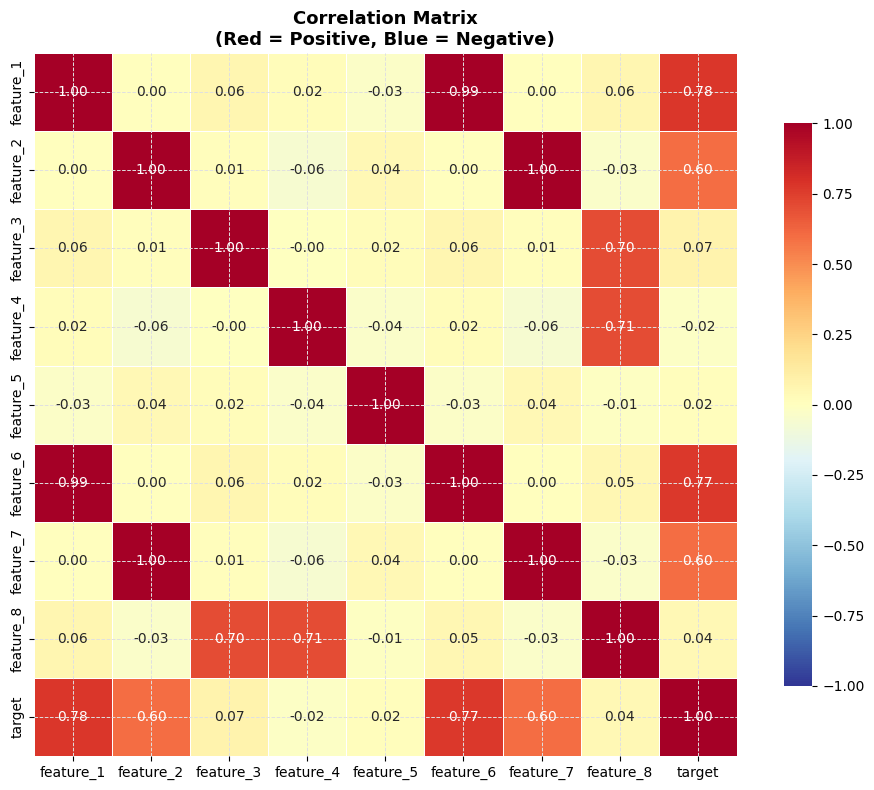

In [43]:
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
ax.set_title(
    'Correlation Matrix\n(Red = Positive, Blue = Negative)',
    fontweight='bold',
    fontsize=13,
)
plt.tight_layout()
plt.show()

In [44]:
# Find and remove multicollinear features
def find_correlated_features(corr_matrix, threshold=0.9):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    correlated_pairs = []
    for column in upper.columns:
        if column == 'target':
            continue
        corr_feats = upper.index[abs(upper[column]) > threshold].tolist()
        for cf in corr_feats:
            if cf != 'target':
                correlated_pairs.append(
                    {
                        'feature_A': column,
                        'feature_B': cf,
                        'correlation': round(corr_matrix.loc[column, cf], 3),
                    }
                )
    return pd.DataFrame(correlated_pairs)


print('corr_matrix:')
print(corr_matrix)

correlated_features = find_correlated_features(corr_matrix, threshold=0.9)
print("\nHighly correlated feature pairs (|r| > 0.9):")
print(correlated_features.to_string(index=False))

# Select features to remove
features_to_remove = set()
for _, row in correlated_features.iterrows():
    feat1, feat2 = row['feature_A'], row['feature_B']
    corr_1_t = abs(corr_matrix.loc[feat1, 'target'])
    corr_2_t = abs(corr_matrix.loc[feat2, 'target'])
    features_to_remove.add(feat2 if corr_1_t > corr_2_t else feat1)

features_to_keep = [
    c for c in df_corr.columns if c not in features_to_remove and c != 'target'
]
print(f"\nFeatures to REMOVE (multicollinear): {list(features_to_remove)}")
print(f"Features to KEEP:                     {features_to_keep}")

corr_matrix:
           feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
feature_1   1.000000   0.003858   0.060716   0.022302  -0.027835   0.994650   
feature_2   0.003858   1.000000   0.008688  -0.057761   0.039600   0.003173   
feature_3   0.060716   0.008688   1.000000  -0.004161   0.020429   0.056360   
feature_4   0.022302  -0.057761  -0.004161   1.000000  -0.038972   0.017381   
feature_5  -0.027835   0.039600   0.020429  -0.038972   1.000000  -0.025752   
feature_6   0.994650   0.003173   0.056360   0.017381  -0.025752   1.000000   
feature_7   0.004360   0.998616   0.008739  -0.057952   0.041956   0.003350   
feature_8   0.058752  -0.034898   0.703726   0.707537  -0.013252   0.052178   
target      0.776541   0.600866   0.072664  -0.016787   0.015115   0.771951   

           feature_7  feature_8    target  
feature_1   0.004360   0.058752  0.776541  
feature_2   0.998616  -0.034898  0.600866  
feature_3   0.008739   0.703726  0.072664  
feature_4  -0.057952


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**`find_correlated_features(corr_matrix, threshold=0.9)`**
- `np.triu(np.ones(corr_matrix.shape), k=1)` — creates an upper triangle matrix of 1s; `k=1` means start one above the diagonal (excludes diagonal which is always self-correlation = 1.0)
- `.astype(bool)` — converts 1s/0s to True/False mask
- `corr_matrix.where(...)` — keeps values where mask is True, sets rest to NaN → result is upper triangle only, avoiding duplicate pairs (e.g. feature_1 vs feature_6 appears once, not twice)

`where()` returns a **DataFrame** of the same shape as the original — values where condition is True are kept, everything else replaced with **NaN**.
```python
corr_matrix.where(mask)
# same shape as corr_matrix
# True positions  → original value kept
# False positions → NaN
```
- `for column in upper.columns` — iterates over each feature column
- `if column == 'target': continue` — skips the target column
- `abs(upper[column]) > threshold` — boolean mask of features that have correlation > 0.9 with current column
- `upper.index[...]` — gets the feature names that exceed the threshold
- appends a dict per correlated pair with both feature names and their correlation value
- returns a DataFrame of all highly correlated pairs


**Selecting features to remove:**
- `for _, row in correlated_features.iterrows()` — iterates over each correlated pair; `_` discards the row index
- `corr_matrix.loc[feat1, 'target']` — gets correlation of feat1 with target
- `corr_matrix.loc[feat2, 'target']` — gets correlation of feat2 with target
- `features_to_remove.add(feat2 if corr_1_t > corr_2_t else feat1)` — keeps the feature more correlated with target, removes the other → uses `set()` to avoid duplicates
- `[c for c in df_corr.columns if c not in features_to_remove and c != 'target']` — list comprehension keeping only non-removed, non-target columns
</div>

In [45]:
# Demonstrate impact on Linear Regression
X_all = df_corr.drop('target', axis=1)
X_selected = df_corr[features_to_keep]
y = df_corr['target']

model_all = LinearRegression()
model_all.fit(X_all, y)
model_sel = LinearRegression()
model_sel.fit(X_selected, y)

y_pred_all = model_all.predict(X_all)
y_pred_sel = model_sel.predict(X_selected)

print("Model with ALL features:")
print(
    f"  R² = {r2_score(y, y_pred_all):.4f}, MSE = {mean_squared_error(y, y_pred_all):.4f}, Features = {X_all.shape[1]}"
)
print("  Coefficients (UNSTABLE due to multicollinearity):")
for feat, coef in zip(X_all.columns, model_all.coef_):
    print(f"    {feat}: {coef:.3f}")

print("\nModel with SELECTED features (multicollinearity removed):")
print(
    f"  R² = {r2_score(y, y_pred_sel):.4f}, MSE = {mean_squared_error(y, y_pred_sel):.4f}, Features = {X_selected.shape[1]}"
)
print("  Coefficients (STABLE and CORRECT):")
for feat, coef in zip(X_selected.columns, model_sel.coef_):
    print(f"    {feat}: {coef:.3f}")

print("\n✅ Same R² and MSE with 2 fewer features!")
print("   feature_1 coefficient: (true value = 2.0) — NOW CORRECT!")
print("   Removing multicollinearity makes the model stable and interpretable.")

Model with ALL features:
  R² = 0.9612, MSE = 0.2520, Features = 8
  Coefficients (UNSTABLE due to multicollinearity):
    feature_1: 2.050
    feature_2: 2.071
    feature_3: 0.035
    feature_4: -0.016
    feature_5: 0.034
    feature_6: -0.014
    feature_7: -0.639
    feature_8: 0.019

Model with SELECTED features (multicollinearity removed):
  R² = 0.9610, MSE = 0.2530, Features = 6
  Coefficients (STABLE and CORRECT):
    feature_1: 2.036
    feature_2: 1.467
    feature_3: 0.035
    feature_4: -0.016
    feature_5: 0.032
    feature_8: 0.019

✅ Same R² and MSE with 2 fewer features!
   feature_1 coefficient: (true value = 2.0) — NOW CORRECT!
   Removing multicollinearity makes the model stable and interpretable.


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `df_corr.drop('target', axis=1)` — all features including correlated ones → used for the baseline model
- `df_corr[features_to_keep]` — only the selected non-multicollinear features → used for the clean model
- `y = df_corr['target']` — target variable for both models

- `LinearRegression()` — creates a linear regression model object with no arguments (uses default settings)
- `.fit(X, y)` — trains the model on the given features and target → computes optimal coefficients
- `.predict(X)` — uses learned coefficients to generate predictions on the same X

- `r2_score(y, y_pred)` — R² score: proportion of variance in target explained by the model; 1.0 = perfect, 0 = no better than predicting the mean
- `mean_squared_error(y, y_pred)` — average squared difference between actual and predicted values → lower is better
- `X_all.shape[1]` — number of columns (features) in the DataFrame

- `zip(X_all.columns, model_all.coef_)` — pairs each feature name with its learned coefficient for printing
- `model_all.coef_` — array of coefficients for each feature after fitting

Why multicollinearity causes unstable coefficients:
- with feature_1 and feature_6 both present (nearly identical), the model can't decide how to split the weight between them → coefficients become arbitrary and unreliable
- with multicollinear features removed, the model correctly assigns ~2.0 to feature_1 and ~1.5 to feature_2 (matching the true values used to build the target)
- **R² and MSE stay the same** — removing redundant features doesn't hurt performance, only improves interpretability
</div>

---
## 📌 5.2 Wrapper Methods

Wrapper methods evaluate feature subsets by **training models and measuring performance**. They're slower but often more accurate than filter methods.

### 5.2.1 Forward Selection
**Start with zero features, iteratively add the feature that improves validation performance the most.**

**When to stop?** Performance plateau, or adding new features provides minimal improvement, or even worse performance.


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

# Create sample dataset
X_cls, y_cls = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    n_redundant=3,
    n_classes=2,
    random_state=42,
)
feature_names = [f'feature_{i}' for i in range(X_cls.shape[1])]
X_df = pd.DataFrame(X_cls, columns=feature_names)


def forward_selection(X, y, max_features=7):
    selected_features = []
    remaining_features = list(X.columns)
    results = []
    for iteration in range(max_features):
        best_score, best_feature = 0, None
        for feature in remaining_features:
            test_features = selected_features + [feature]
            model = LogisticRegression(random_state=42, max_iter=1000)
            scores = cross_val_score(
                model, X[test_features], y, cv=5, scoring='accuracy'
            )
            if scores.mean() > best_score:
                best_score = scores.mean()
                best_feature = feature
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            results.append(
                {
                    'iteration': iteration + 1,
                    'added_feature': best_feature,
                    'cv_score': best_score,
                    'num_features': len(selected_features),
                }
            )
            print(
                f"Iteration {iteration+1}: Added '{best_feature}' (CV Score: {best_score:.4f})"
            )
    return pd.DataFrame(results), selected_features


results_df, selected_features = forward_selection(X_df, y_cls, max_features=7)
print("\n" + "=" * 50)
print("Forward Selection Results:")
print(
    results_df[['iteration', 'added_feature', 'cv_score', 'num_features']].to_string(
        index=False
    )
)

score_all = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_df,
    y_cls,
    cv=5,
    scoring='accuracy',
).mean()
score_sel = cross_val_score(
    LogisticRegression(random_state=42, max_iter=1000),
    X_df[selected_features],
    y_cls,
    cv=5,
    scoring='accuracy',
).mean()
print(f"\nAll 10 features: CV Score = {score_all:.4f}")
print(f"Selected features: CV Score = {score_sel:.4f}")

Iteration 1: Added 'feature_4' (CV Score: 0.7520)
Iteration 2: Added 'feature_5' (CV Score: 0.8120)
Iteration 3: Added 'feature_0' (CV Score: 0.8320)
Iteration 4: Added 'feature_2' (CV Score: 0.8540)
Iteration 5: Added 'feature_7' (CV Score: 0.8600)
Iteration 6: Added 'feature_6' (CV Score: 0.8600)
Iteration 7: Added 'feature_8' (CV Score: 0.8600)

Forward Selection Results:
 iteration added_feature  cv_score  num_features
         1     feature_4     0.752             1
         2     feature_5     0.812             2
         3     feature_0     0.832             3
         4     feature_2     0.854             4
         5     feature_7     0.860             5
         6     feature_6     0.860             6
         7     feature_8     0.860             7

All 10 features: CV Score = 0.8540
Selected features: CV Score = 0.8600


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=3, n_classes=2, random_state=42)` — generates a synthetic binary classification dataset:
  - `n_samples=500` — 500 rows
  - `n_features=10` — 10 total features
  - `n_informative=5` — 5 features actually useful for prediction
  - `n_redundant=3` — 3 features that are linear combinations of informative ones (noise)
  - `n_classes=2` — binary target (0 or 1)
  - returns `X` (500×10 numpy array) and `y` (500 labels)

- `X_cls.shape[1]` — number of columns (10) → used to generate feature names dynamically

**`forward_selection(X, y, max_features=7)`**
- `selected_features = []` — starts empty, features added one by one
- `remaining_features = list(X.columns)` — all features available to pick from
- outer `for iteration in range(max_features)` — runs up to 7 iterations (one feature added per iteration)
- inner `for feature in remaining_features` — tries adding each remaining feature to the current selected set
- `selected_features + [feature]` — temporarily adds candidate feature to test it
- `LogisticRegression(random_state=42, max_iter=1000)` — logistic regression model; `max_iter=1000` increases max iterations to ensure convergence
- `cross_val_score(model, X[test_features], y, cv=5, scoring='accuracy')` — evaluates model using 5-fold cross validation; splits data into 5 folds, trains on 4, tests on 1, repeats 5 times → returns array of 5 scores
- `scores.mean()` — average accuracy across 5 folds → used to compare candidates
- `if scores.mean() > best_score` — keeps track of which candidate feature gave highest CV score
- `selected_features.append(best_feature)` — permanently adds the best feature found this iteration
- `remaining_features.remove(best_feature)` — removes it from candidates so it can't be picked again
- returns a DataFrame of results and the final selected feature list

**Final comparison:**
- `cross_val_score(..., X_df, ...)` — evaluates model using all 10 features
- `cross_val_score(..., X_df[selected_features], ...)` — evaluates model using only the 7 selected features
- `.mean()` — average CV accuracy for comparison
- goal: show that fewer features can match or beat all-features performance by removing redundant/noisy ones
</div>

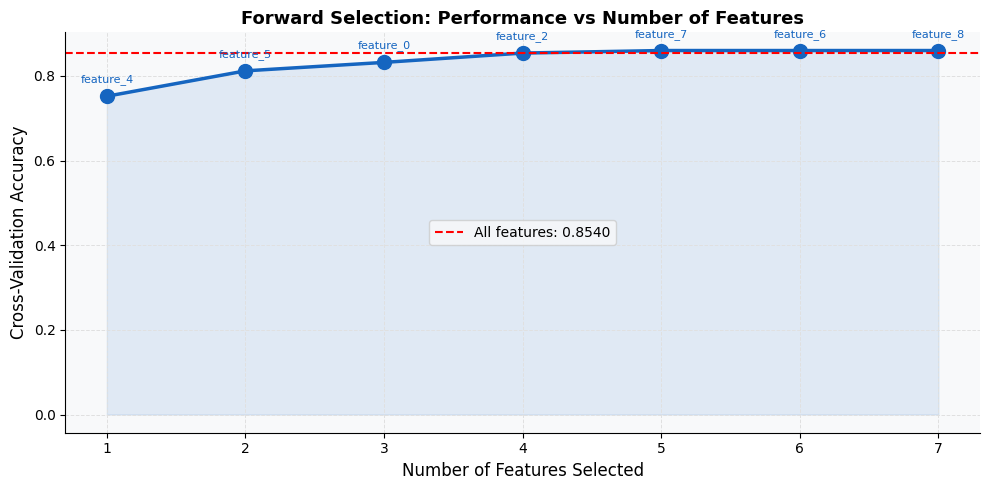

In [47]:
# Visualize Forward Selection progress
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    results_df['num_features'],
    results_df['cv_score'],
    'o-',
    color='#1565c0',
    lw=2.5,
    ms=10,
)
ax.fill_between(
    results_df['num_features'], results_df['cv_score'], alpha=0.1, color='#1565c0'
)
ax.axhline(
    score_all, color='red', ls='--', lw=1.5, label=f'All features: {score_all:.4f}'
)
ax.set_xlabel('Number of Features Selected', fontsize=12)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title(
    'Forward Selection: Performance vs Number of Features',
    fontweight='bold',
    fontsize=13,
)
for _, row in results_df.iterrows():
    ax.annotate(
        row['added_feature'],
        (row['num_features'], row['cv_score']),
        textcoords='offset points',
        xytext=(0, 10),
        ha='center',
        fontsize=8,
        color='#1565c0',
    )
ax.legend()
ax.set_xticks(results_df['num_features'])
plt.tight_layout()
plt.show()

---
### 5.2.2 Backward Elimination
**Start with all features, iteratively remove the least useful feature.**


This dataset represents **telecom customer data** used to predict churn (whether a customer will cancel their subscription).

- **`tenure_months`** — how long the customer has been with the telecom provider (1–71 months)
- **`monthly_charges`** — how much the customer pays per month ($20–$150)
- **`total_charges`** — total amount paid over their lifetime ($100–$8,000)
- **`contract_type`** — type of contract: 0=month-to-month, 1=one-year, 2=two-year
- **`payment_method`** — how the customer pays: 0=electronic check, 1=mailed check, 2=bank transfer, 3=credit card
- **`internet_service`** — type of internet: 0=no internet, 1=DSL, 2=fiber optic
- **`tech_support`** — whether the customer has tech support add-on (0=no, 1=yes)
- **`online_security`** — whether the customer has online security add-on (0=no, 1=yes)
- **`device_protection`** — whether the customer has device protection add-on (0=no, 1=yes)
- **`num_service_calls`** — number of times the customer called support (Poisson distributed, mean=2)

In [48]:
# Churn Dataset for Backward Elimination
np.random.seed(42)
n_customers = 1000
churn_data = pd.DataFrame(
    {
        'tenure_months': np.random.randint(1, 72, n_customers),
        'monthly_charges': np.random.uniform(20, 150, n_customers),
        'total_charges': np.random.uniform(100, 8000, n_customers),
        'contract_type': np.random.choice([0, 1, 2], n_customers),
        'payment_method': np.random.choice([0, 1, 2, 3], n_customers),
        'internet_service': np.random.choice([0, 1, 2], n_customers),
        'tech_support': np.random.choice([0, 1], n_customers),
        'online_security': np.random.choice([0, 1], n_customers),
        'device_protection': np.random.choice([0, 1], n_customers),
        'num_service_calls': np.random.poisson(2, n_customers),
    }
)
churn_data['churned'] = (
    (churn_data['tenure_months'] < 12).astype(int) * 0.4
    + (churn_data['contract_type'] == 0).astype(int) * 0.3
    + (churn_data['num_service_calls'] > 3).astype(int) * 0.2
    + (churn_data['tech_support'] == 0).astype(int) * 0.1
    + np.random.uniform(0, 0.2, n_customers)
)
churn_data['churned'] = (churn_data['churned'] > 0.5).astype(int)

X_churn = churn_data.drop('churned', axis=1)
y_churn = churn_data['churned']


def backward_elimination(X, y, min_features=4):
    selected_features = list(X.columns)
    model = LogisticRegression(random_state=42, max_iter=1000)
    initial_score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    print(
        f"Starting with all {len(selected_features)} features: CV Score = {initial_score:.4f}\n{'='*50}"
    )
    results = []
    while len(selected_features) > min_features:
        worst_score, worst_feature = initial_score, None
        for feature in selected_features:
            test_features = [f for f in selected_features if f != feature]
            m = LogisticRegression(random_state=42, max_iter=1000)
            score = cross_val_score(
                m, X[test_features], y, cv=5, scoring='accuracy'
            ).mean()
            if score >= worst_score:
                worst_score, worst_feature = score, feature
        if worst_feature:
            selected_features.remove(worst_feature)
            results.append(
                {
                    'removed_feature': worst_feature,
                    'cv_score': worst_score,
                    'remaining': len(selected_features),
                }
            )
            print(
                f"Removed '{worst_feature}' → CV: {worst_score:.4f}, {len(selected_features)} remain"
            )
        else:
            print("No feature can be removed without hurting score. Stopping.")
            break  # ←
    return pd.DataFrame(results), selected_features


results_back, selected_back = backward_elimination(X_churn, y_churn, min_features=4)
print(f"\nFinal features: {selected_back}")

Starting with all 10 features: CV Score = 0.8440
Removed 'total_charges' → CV: 0.8470, 9 remain
Removed 'internet_service' → CV: 0.8460, 8 remain
Removed 'device_protection' → CV: 0.8470, 7 remain
Removed 'online_security' → CV: 0.8440, 6 remain
Removed 'payment_method' → CV: 0.8440, 5 remain
No feature can be removed without hurting score. Stopping.

Final features: ['tenure_months', 'monthly_charges', 'contract_type', 'tech_support', 'num_service_calls']


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**Data Generation:**
- `np.random.randint(1, 72, n_customers)` — random integers 1–71 representing tenure in months
- `np.random.uniform(20, 150, n_customers)` — random floats between 20 and 150 for monthly charges
- `np.random.choice([0, 1, 2], n_customers)` — randomly picks from discrete options (e.g. contract types: month-to-month, one-year, two-year)
- `np.random.poisson(2, n_customers)` — generates counts from Poisson distribution with mean=2 → realistic for service call counts (most customers call ~2 times, few call many times)

**Target creation:**
- `(churn_data['tenure_months'] < 12).astype(int) * 0.4` — new customers (< 1 year) contribute 0.4 to churn score
- `(churn_data['contract_type'] == 0).astype(int) * 0.3` — month-to-month contracts contribute 0.3
- `(churn_data['num_service_calls'] > 3).astype(int) * 0.2` — frustrated customers (many calls) contribute 0.2
- `(churn_data['tech_support'] == 0).astype(int) * 0.1` — no tech support contributes 0.1
- `np.random.uniform(0, 0.2, n_customers)` — adds random noise 0–0.2
- `(churn_data['churned'] > 0.5).astype(int)` — converts continuous score to binary: score > 0.5 = churned

**`backward_elimination(X, y, min_features=4)`:**
- starts with **all features** and removes one per iteration (opposite of forward selection)
- `initial_score` — baseline CV accuracy with all features
- `while len(selected_features) > min_features` — keeps removing until only 4 features remain
- inner loop tries **removing each feature one at a time** and scores the model without it
- `[f for f in selected_features if f != feature]` — list comprehension that creates feature list excluding the candidate for removal
- `if score >= worst_score` — if removing this feature doesn't hurt (or improves) the score → mark it as the worst (least useful) feature
- `selected_features.remove(worst_feature)` — permanently removes the least useful feature
- if no feature can be removed without hurting score, `worst_feature` stays None and loop ends early

**Key difference from forward selection:**
- forward selection: starts empty, greedily **adds** best feature each step
- backward elimination: starts full, greedily **removes** least useful feature each step
- backward is more expensive (starts with all features) but considers feature interactions from the start
</div>

---
### 5.2.3 Recursive Feature Elimination (RFE)

**Concept:** Train model → rank features by importance → remove weakest → repeat.

**How importance is estimated:**
- **Logistic Regression:** Absolute value of coefficients
- **SVM:** Weight vector coefficients
- **Random Forests / Tree-Based:** Feature importance (Gini impurity)

**RFECV:** Extension that automatically finds the optimal number of features using cross-validation.


In [49]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=5, step=1)
rfe.fit(X_churn, y_churn)

feature_rankings = pd.DataFrame(
    {'feature': X_churn.columns, 'ranking': rfe.ranking_, 'selected': rfe.support_}
).sort_values('ranking')

print("RFE Feature Rankings:")
print(feature_rankings.to_string(index=False))
print(
    f"\nSelected features: {feature_rankings[feature_rankings['selected']]['feature'].tolist()}"
)

RFE Feature Rankings:
          feature  ranking  selected
    tenure_months        1      True
  monthly_charges        1      True
    total_charges        1      True
    contract_type        1      True
num_service_calls        1      True
     tech_support        2     False
   payment_method        3     False
 internet_service        4     False
  online_security        5     False
device_protection        6     False

Selected features: ['tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'num_service_calls']


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `RandomForestClassifier(n_estimators=100, random_state=42)` — creates a random forest model with 100 decision trees; `random_state=42` for reproducibility; used as the base estimator inside RFE to score feature importance

- `RFE(estimator=rf, n_features_to_select=5, step=1)` — Recursive Feature Elimination:
  - `estimator=rf` — the model used to evaluate feature importance at each step
  - `n_features_to_select=5` — keep only the 5 most important features
  - `step=1` — remove 1 feature per iteration (can be int for count or float for percentage)

- `rfe.fit(X_churn, y_churn)` — runs the RFE process:
  1. trains the model on all features
  2. ranks features by importance
  3. removes the least important feature
  4. repeats until only 5 features remain

- `rfe.ranking_` — array of integers, one per feature; `1` = selected (best), higher numbers = eliminated earlier (less important)
- `rfe.support_` — boolean array; `True` = feature was selected, `False` = eliminated

- `pd.DataFrame({'feature': X_churn.columns, 'ranking': rfe.ranking_, 'selected': rfe.support_})` — combines feature names, rankings, and selection status into one DataFrame
- `.sort_values('ranking')` — sorts by ranking ascending → selected features (rank=1) appear first

- `feature_rankings[feature_rankings['selected']]` — filters to only rows where `selected=True`
- `['feature'].tolist()` — extracts feature names as a plain Python list
</div>

Optimal number of features: 8
Optimal features: ['tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'payment_method', 'internet_service', 'tech_support', 'num_service_calls']


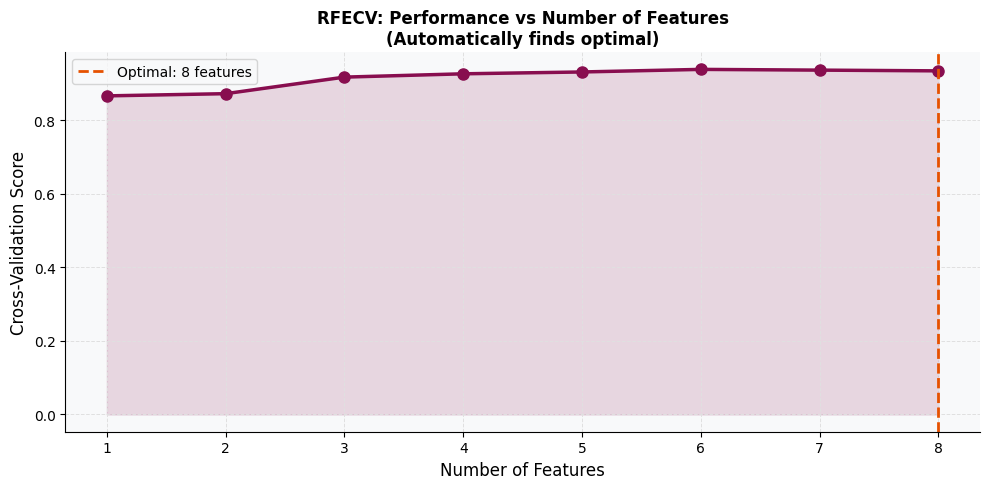

In [50]:
# RFECV — automatically finds optimal number
rfecv = RFECV(estimator=rf, step=1, cv=5, scoring='accuracy', min_features_to_select=3)
rfecv.fit(X_churn, y_churn)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Optimal features: {X_churn.columns[rfecv.support_].tolist()}")

# Plot RFECV results
fig, ax = plt.subplots(figsize=(10, 5))
scores = rfecv.cv_results_['mean_test_score']
ax.plot(range(1, len(scores) + 1), scores, 'o-', color='#880e4f', lw=2.5, ms=8)
ax.fill_between(range(1, len(scores) + 1), scores, alpha=0.15, color='#880e4f')
ax.axvline(
    rfecv.n_features_,
    color='#e65100',
    ls='--',
    lw=2,
    label=f'Optimal: {rfecv.n_features_} features',
)
ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Cross-Validation Score', fontsize=12)
ax.set_title(
    'RFECV: Performance vs Number of Features\n(Automatically finds optimal)',
    fontweight='bold',
)
ax.legend()
plt.tight_layout()
plt.show()

<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

- `RFECV(estimator=rf, step=1, cv=5, scoring='accuracy', min_features_to_select=3)` — Recursive Feature Elimination with Cross Validation; same as RFE but automatically finds the optimal number of features instead of requiring you to specify it:
  - `estimator=rf` — random forest used to score feature importance
  - `step=1` — remove 1 feature per iteration
  - `cv=5` — 5-fold cross validation to evaluate each feature subset
  - `scoring='accuracy'` — metric used to compare feature subsets
  - `min_features_to_select=3` — never go below 3 features regardless of CV scores

- `rfecv.fit(X_churn, y_churn)` — runs the full RFECV process:
  1. starts with all features
  2. removes one feature per iteration
  3. evaluates each subset using 5-fold CV
  4. picks the subset size with the highest CV accuracy

- `rfecv.n_features_` — the optimal number of features found automatically by CV
- `rfecv.support_` — boolean array True/False per feature → True = in optimal subset
- `X_churn.columns[rfecv.support_].tolist()` — filters column names to only the selected ones

**Key difference from RFE:**
- `RFE` — you specify exactly how many features to keep (`n_features_to_select=5`)
- `RFECV` — CV decides the optimal number automatically → more robust but slower (trains model for every feature subset size)
</div>

---
## 📌 5.3 Permutation Importance

<div style="background: #f3e5f5; border-left: 5px solid #6a1b9a; padding: 15px 20px; border-radius: 6px; margin: 10px 0;">
  <b>Shuffle feature values and measure the model's performance drop.</b><br>
  The drop in score compared to baseline = importance of that feature.<br>
  <b>Model-agnostic</b> — works with any model!
</div>

### How It Works
1. Train model → record baseline score
2. **Shuffle** one feature's values (break its relationship with target)
3. Measure new score
4. Importance = baseline_score − shuffled_score
5. Repeat for each feature, `n_repeats` times for stability


In [51]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# House price prediction dataset
np.random.seed(42)
n_houses = 500
df_houses = pd.DataFrame(
    {
        'square_feet': np.random.randint(800, 5000, n_houses),
        'bedrooms': np.random.randint(1, 7, n_houses),
        'bathrooms': np.random.randint(1, 5, n_houses),
        'age_years': np.random.randint(0, 60, n_houses),
        'lot_size': np.random.randint(2000, 12000, n_houses),
        'garage_spaces': np.random.randint(0, 4, n_houses),
        'has_pool': np.random.randint(0, 2, n_houses),
        'has_fireplace': np.random.randint(0, 2, n_houses),
        'has_basement': np.random.randint(0, 2, n_houses),
        'school_rating': np.random.uniform(1, 10, n_houses),
        'crime_rate': np.random.uniform(0.1, 10, n_houses),
        'distance_downtown': np.random.uniform(1, 30, n_houses),
        'property_tax': np.random.uniform(1000, 15000, n_houses),
        'hoa_fees': np.random.uniform(0, 500, n_houses),
    }
)
X_houses = df_houses
y_houses = (
    150 * df_houses['square_feet']
    + 25000 * df_houses['bedrooms']
    + 20000 * df_houses['bathrooms']
    - 1000 * df_houses['age_years']
    + 10 * df_houses['lot_size']
    + 5000 * df_houses['school_rating']
    - 3000 * df_houses['crime_rate']
    + np.random.randn(n_houses) * 20000
    + 100000
)

X_train, X_test, y_train, y_test = train_test_split(
    X_houses, y_houses, test_size=0.2, random_state=42
)
rf_house = RandomForestRegressor(n_estimators=100, random_state=42)
rf_house.fit(X_train, y_train)

baseline_score = rf_house.score(X_test, y_test)
print(f"Baseline R² Score: {baseline_score:.4f}")

# Permutation importance
perm_imp = permutation_importance(
    rf_house, X_test, y_test, n_repeats=10, random_state=42
)

perm_results = pd.DataFrame(
    {
        'feature': X_houses.columns,
        'importance_mean': perm_imp.importances_mean,
        'importance_std': perm_imp.importances_std,
    }
).sort_values('importance_mean', ascending=False)

print("\nPermutation Importance (top features):")
print(perm_results.round(4).to_string(index=False))

Baseline R² Score: 0.9600

Permutation Importance (top features):
          feature  importance_mean  importance_std
      square_feet           1.8649          0.2307
         bedrooms           0.0784          0.0104
         lot_size           0.0275          0.0047
        age_years           0.0085          0.0014
        bathrooms           0.0052          0.0013
    school_rating           0.0006          0.0006
         hoa_fees           0.0004          0.0004
         has_pool           0.0002          0.0003
distance_downtown           0.0002          0.0005
     property_tax           0.0002          0.0006
       crime_rate          -0.0001          0.0010
     has_basement          -0.0002          0.0001
    has_fireplace          -0.0004          0.0001
    garage_spaces          -0.0011          0.0003


<p style="color: steelblue; font-size: 1.5em;">Explanation:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

**Data Generation:**
- `np.random.randint(800, 5000, n_houses)` — random house sizes between 800–4999 sq ft
- `np.random.uniform(1, 10, n_houses)` — continuous school rating 1–10
- `np.random.uniform(0.1, 10, n_houses)` — continuous crime rate 0.1–10

**Target (house price):**
- manually built from a weighted formula: square_feet has the biggest impact (×150), bedrooms (×25000), bathrooms (×20000), age hurts value (×−1000), school_rating helps (×5000), crime_rate hurts (×−3000)
- `np.random.randn(n_houses) * 20000` — adds realistic noise ±$20,000
- `+ 100000` — base price offset
- features like `garage_spaces`, `has_pool`, `hoa_fees` are intentionally excluded from the formula → should show low importance

**Train/test split:**
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits data into 80% train and 20% test; `random_state=42` for reproducibility; returns `X_train, X_test, y_train, y_test`

- `RandomForestRegressor(n_estimators=100, random_state=42)` — random forest for regression (predicting continuous values); 100 decision trees averaged together
- `.fit(X_train, y_train)` — trains on training set only
- `.score(X_test, y_test)` — returns R² on test set → how well the model predicts unseen data

**Coeffecient of Determination (R²):** 
- **R²** is pronounced **"R squared"** (also called **coefficient of determination**).

- It measures how much of the variance in the target is explained by the model:

    - **R² = 1.0** — perfect predictions
    - **R² = 0.0** — model is no better than just predicting the mean every time
    - **R² < 0** — model is worse than predicting the mean

    - For example, R² = 0.85 means the model explains **85% of the variance** in house prices.

**Permutation Importance:**
- `permutation_importance(rf_house, X_test, y_test, n_repeats=10, random_state=42)` — measures feature importance by:
  1. computing baseline score on set
  2. randomly shuffling one feature's values (breaking its relationship with target)
  3. measuring how much the score drops → bigger drop = more important feature
  4. repeating `n_repeats=10` times per feature to get stable estimates
  - `n_repeats=10` — shuffles each feature 10 times → returns mean and std of importance

- `perm_imp.importances_mean` — average score drop across 10 repeats per feature
- `perm_imp.importances_std` — standard deviation of score drop → high std means unstable importance estimate
- `.sort_values('importance_mean', ascending=False)` — most important features appear first

**Permutation Importance Process — step by step:**

1. compute baseline score on test set (R² = e.g. 0.97)
2. **for each feature** (iterates over ALL features one by one):
   - randomly shuffle that feature's values → breaks its relationship with target
   - score the model on the shuffled data
   - importance = baseline score − shuffled score
   - repeat shuffle `n_repeats=10` times → get mean and std of importance
   - restore the feature to original values before moving to next feature
3. features with **high importance_mean** = big score drop when shuffled = truly important
4. features with **importance_mean ≈ 0** = shuffling them didn't hurt = useless features

total model evaluations = `n_features × n_repeats` = 14 × 10 = **140 evaluations**
</div>

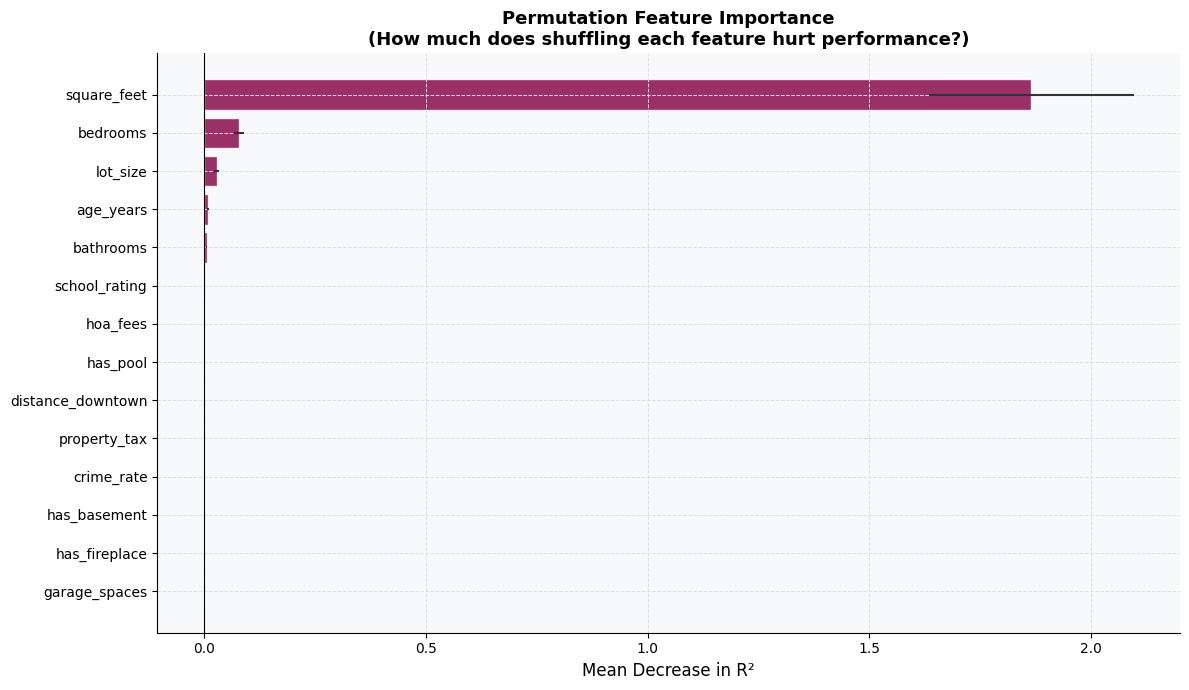


💡 n_repeats=10: each feature is shuffled 10 times → stable mean and std
   Features near 0: not important; large positive = very important!


In [52]:
# Visualize Permutation Importance
fig, ax = plt.subplots(figsize=(12, 7))
colors_perm = [
    '#880e4f' if v > 0 else '#9e9e9e' for v in perm_results['importance_mean']
]
bars = ax.barh(
    range(len(perm_results)),
    perm_results['importance_mean'],
    xerr=perm_results['importance_std'],
    color=colors_perm,
    error_kw={'ecolor': '#333', 'elinewidth': 1.5},
    edgecolor='white',
    alpha=0.85,
)
ax.set_yticks(range(len(perm_results)))
ax.set_yticklabels(perm_results['feature'])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean Decrease in R²', fontsize=12)
ax.set_title(
    'Permutation Feature Importance\n(How much does shuffling each feature hurt performance?)',
    fontweight='bold',
    fontsize=13,
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print("\n💡 n_repeats=10: each feature is shuffled 10 times → stable mean and std")
print("   Features near 0: not important; large positive = very important!")

---
<div style="background: linear-gradient(90deg, #1a237e, #283593); padding: 18px 30px; border-radius: 10px; margin: 20px 0;">
  <h1 style="color: white; margin: 0; font-size: 1.9em;">📋 Topic 6: Data Cleaning Log Report</h1>
</div>

> *"Data preparation is not just about writing code — it's about creating a reproducible, well-documented process."*

### Why Documentation Matters

| Poor Documentation Leads To | Good Documentation Enables |
|----------------------------|-----------------------------|
| Inability to reproduce results | Reproducibility |
| Uncertainty about transformations | Collaboration |
| Difficulty detecting errors | Auditing |
| Loss of institutional knowledge | Stakeholder trust |

### The Cleaning Report Has Three Sections
1. **Executive Summary** — one-paragraph overview with dataset name, record counts, processing time, key issues
2. **Data Quality Assessment** — initial state expressed quantitatively
3. **Transformation Log** — timestamped, ordered list of every action taken


---
## 📌 6.1 Data Cleaning Log — Class Implementation

The `DataCleaningLog` class provides structured logging of all cleaning actions.


<p style="color: steelblue; font-size: 1.5em;">DataCleaningLog Class:</p>

<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">

`DataCleaningLog` is a logging utility class that tracks every transformation applied to a dataset during the data cleaning process.

**Initialization:** takes `dataset_name` and `analyst_name`, automatically records `start_time`, and sets up empty `log_entries` and `summary_stats`.

**Core Functions:**
```
DataCleaningLog
├── log_action()           → records a single cleaning step (category, action, rows/cols affected, before/after values)
├── record_initial_state() → snapshots the dataset before cleaning (shape, dtypes, nulls, memory)
├── record_final_state()   → snapshots the dataset after cleaning
├── generate_summary()     → computes rows removed, columns removed, total actions, actions per category
├── to_dataframe()         → converts all log entries to a pandas DataFrame
├── to_dict()              → exports full log as a nested dictionary (metadata + states + actions)
├── save_to_json()         → saves to_dict() output as a JSON file
├── save_to_csv()          → saves to_dataframe() output as a CSV file
└── print_report()         → prints a human-readable executive summary to console
```

**Main Functionality:** the class acts as an **audit trail** — every cleaning decision (imputing nulls, removing outliers, dropping duplicates) is recorded with a timestamp and full context. At the end of the pipeline, the analyst can export a complete log showing exactly what changed, why, and how many rows/columns were affected — useful for reproducibility, documentation, and compliance.
</div>

In [ ]:
import json
from datetime import datetime


class DataCleaningLog:
    """
    A comprehensive data cleaning logger that tracks all transformations.

    Parameters
    ----------
    dataset_name : str
        Name of the dataset being cleaned
    analyst_name : str
        Name of the person performing the cleaning
    """

    def __init__(self, dataset_name, analyst_name):
        self.dataset_name = dataset_name
        self.analyst_name = analyst_name
        self.start_time = datetime.now()
        self.log_entries = []
        self.summary_stats = {'initial': {}, 'final': {}}

    def log_action(
        self,
        category,
        action,
        details,
        rows_affected=None,
        columns_affected=None,
        before_value=None,
        after_value=None,
    ):
        """
        Log a data cleaning action.

        Parameters
        ----------
        category : str
            Type of cleaning (e.g., 'Missing Values', 'Outliers', 'Duplicates')
        action : str
            Specific action taken (e.g., 'Imputed with mean', 'Removed rows')
        details : str
            Detailed explanation of the action
        rows_affected : int
            Number of rows affected
        columns_affected : list
            List of column names affected
        before_value : any
            Example of value before transformation
        after_value : any
            Example of value after transformation
        """
        entry = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'category': category,
            'action': action,
            'details': details,
            'rows_affected': rows_affected,
            'columns_affected': columns_affected if columns_affected else [],
            'before_value': str(before_value) if before_value is not None else None,
            'after_value': str(after_value) if after_value is not None else None,
        }
        self.log_entries.append(entry)

    def record_initial_state(self, df):
        """Record initial dataset statistics."""
        self.summary_stats['initial'] = {
            'total_rows': len(df),
            'total_columns': len(df.columns),
            'columns': list(df.columns),
            'dtypes': df.dtypes.astype(str).to_dict(),
            'missing_values': df.isnull().sum().to_dict(),
            'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2,
        }

    def record_final_state(self, df):
        """Record final dataset statistics."""
        self.summary_stats['final'] = {
            'total_rows': len(df),
            'total_columns': len(df.columns),
            'columns': list(df.columns),
            'dtypes': df.dtypes.astype(str).to_dict(),
            'missing_values': df.isnull().sum().to_dict(),
            'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2,
        }

    def generate_summary(self):
        """Generate a summary of all cleaning actions."""
        initial = self.summary_stats['initial']
        final = self.summary_stats['final']
        summary = {
            'rows_removed': initial.get('total_rows', 0) - final.get('total_rows', 0),
            'columns_removed': initial.get('total_columns', 0)
            - final.get('total_columns', 0),
            'total_actions': len(self.log_entries),
            'categories': {},
            'processing_time': str(datetime.now() - self.start_time),
        }
        for entry in self.log_entries:
            cat = entry['category']
            summary['categories'][cat] = summary['categories'].get(cat, 0) + 1
        return summary

    def to_dataframe(self):
        """Convert log entries to a DataFrame."""
        return pd.DataFrame(self.log_entries)

    def to_dict(self):
        """Export the complete log as a dictionary."""
        return {
            'metadata': {
                'dataset_name': self.dataset_name,
                'analyst': self.analyst_name,
                'start_time': self.start_time.strftime('%Y-%m-%d %H:%M:%S'),
                'end_time': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            },
            'initial_state': self.summary_stats['initial'],
            'final_state': self.summary_stats['final'],
            'summary': self.generate_summary(),
            'actions': self.log_entries,
        }

    def save_to_json(self, filepath):
        """Save log to JSON file."""
        import numpy as np

        # The NumpyEncoder intercepts any non-serializable type
        # and converts it to a native Python type before json.dump writes it.
        class NumpyEncoder(json.JSONEncoder):
            def default(self, o):
                if isinstance(o, (np.integer,)):
                    return int(o)
                if isinstance(o, (np.floating,)):
                    return float(o)
                if isinstance(o, np.ndarray):
                    return o.tolist()
                return super().default(o)

        with open(filepath, 'w') as f:
            json.dump(self.to_dict(), f, indent=2, cls=NumpyEncoder)

    def save_to_csv(self, filepath):
        """Save log entries to CSV file."""
        self.to_dataframe().to_csv(filepath, index=False)

    def print_report(self):
        """Print a human-readable cleaning report."""
        summary = self.generate_summary()
        initial = self.summary_stats['initial']
        final = self.summary_stats['final']

        print("=" * 70)
        print("           DATA CLEANING REPORT — EXECUTIVE SUMMARY")
        print("=" * 70)
        print(f"  Dataset:          {self.dataset_name}")
        print(f"  Analyst:          {self.analyst_name}")
        print(f"  Processing Date:  {self.start_time.strftime('%Y-%m-%d')}")
        print(f"  Processing Time:  {summary['processing_time']}")
        print(f"  Original Records: {initial.get('total_rows','N/A'):,}")
        print(f"  Final Records:    {final.get('total_rows','N/A'):,}")
        print(f"  Rows Removed:     {summary['rows_removed']:,}")
        print(f"  Total Actions:    {summary['total_actions']}")
        print("-" * 70)
        print("  ACTIONS BY CATEGORY:")
        for cat, count in summary['categories'].items():
            print(f"    {'  '+cat:<35}: {count} action(s)")
        print("=" * 70)


# Test initialization
log = DataCleaningLog(
    dataset_name="Customer_Churn_Dataset_2026", analyst_name="Data Science Team"
)
print(f"✅ DataCleaningLog initialized")
print(f"   Dataset: {log.dataset_name}")
print(f"   Analyst: {log.analyst_name}")
print(f"   Start:   {log.start_time.strftime('%Y-%m-%d %H:%M:%S')}")

✅ DataCleaningLog initialized
   Dataset: Customer_Churn_Dataset_2026
   Analyst: Data Science Team
   Start:   2026-03-23 06:48:29


---
## 📌 6.2 Practical Example: Complete Cleaning Pipeline with Logging


In [54]:
# ── Step 1: Create a messy dataset ─────────────────────────────────────────
np.random.seed(42)
data = {
    'customer_id': range(1, 1001),
    'age': np.random.randint(18, 80, 1000),
    'income': np.random.randint(20000, 150000, 1000),
    'account_balance': np.random.uniform(-5000, 50000, 1000),
    'credit_score': np.random.randint(300, 850, 1000),
    'last_purchase_amount': np.random.uniform(10, 1000, 1000),
    'num_purchases': np.random.randint(0, 100, 1000),
    'email': [f'customer{i}@email.com' for i in range(1, 1001)],
    'signup_date': pd.date_range('2020-01-01', periods=1000, freq='D'),
    'city': np.random.choice(
        [
            'New York',
            'Los Angeles',
            'Chicago',
            'Houston',
            'Phoenix',
            'new york',
            'NEW YORK',
            'N.Y.',
        ],
        1000,
    ),
    'state': np.random.choice(['NY', 'CA', 'IL', 'TX', 'AZ', 'N/A', 'Unknown'], 1000),
}
df_raw = pd.DataFrame(data)

# Introduce data quality issues
missing_idx_age = np.random.choice(df_raw.index, 50, replace=False)
missing_idx_income = np.random.choice(df_raw.index, 80, replace=False)
missing_idx_credit = np.random.choice(df_raw.index, 30, replace=False)
df_raw.loc[missing_idx_age, 'age'] = np.nan
df_raw.loc[missing_idx_income, 'income'] = np.nan
df_raw.loc[missing_idx_credit, 'credit_score'] = np.nan

dup_rows = df_raw.sample(20).copy()
df_raw = pd.concat([df_raw, dup_rows], ignore_index=True)

outlier_idx = np.random.choice(df_raw.index, 10, replace=False)
df_raw.loc[outlier_idx, 'age'] = 150
df_raw.loc[outlier_idx[:5], 'credit_score'] = 1000

neg_idx = np.random.choice(df_raw.index, 15, replace=False)
df_raw.loc[neg_idx, 'num_purchases'] = -5

invalid_email_idx = np.random.choice(df_raw.index, 25, replace=False)
df_raw.loc[invalid_email_idx, 'email'] = 'invalid_email'

whitespace_idx = np.random.choice(df_raw.index, 30, replace=False)
df_raw.loc[whitespace_idx, 'city'] = ' ' + df_raw.loc[whitespace_idx, 'city'] + ' '

print(f"Messy dataset shape: {df_raw.shape}")
print(f"Missing values:\n{df_raw.isnull().sum()[df_raw.isnull().sum()>0].to_string()}")

Messy dataset shape: (1020, 11)
Missing values:
age             50
income          83
credit_score    30


In [55]:
# ── Step 2: Initialize log and start cleaning ──────────────────────────────
log = DataCleaningLog(
    dataset_name="Customer_Churn_Dataset_2026", analyst_name="John Smith"
)
log.record_initial_state(df_raw)
df = df_raw.copy()

print("=" * 80)
print("DATA CLEANING PROCESS — STEP BY STEP WITH LOGGING")
print("=" * 80)

# ── STEP 1: Duplicates
print("\n[STEP 1] Checking for duplicate rows...")
dups = df.duplicated().sum()
if dups > 0:
    df = df.drop_duplicates()
    log.log_action(
        category='Duplicates',
        action='Removed duplicate rows',
        details=f'Identified and removed {dups} exact duplicate rows. Kept first occurrence.',
        rows_affected=dups,
        columns_affected=list(df.columns),
        before_value=f'Total rows: {dups + len(df)}',
        after_value=f'Total rows: {len(df)}',
    )
    print(f"  ✓ Removed {dups} duplicates → shape: {df.shape}")

# ── STEP 2: Missing Values
print("\n[STEP 2] Handling missing values...")
for col, method in [('age', 'median'), ('income', 'mean'), ('credit_score', 'median')]:
    missing_n = df[col].isnull().sum()
    if missing_n > 0:
        fill_val = df[col].median() if method == 'median' else df[col].mean()
        df[col] = df[col].fillna(fill_val)
        log.log_action(
            category='Missing Values',
            action=f'Imputed with {method}',
            details=f'{col} had {missing_n} missing values. Imputed with {method} = {fill_val:.2f}.',
            rows_affected=missing_n,
            columns_affected=[col],
            before_value='NaN',
            after_value=f'{fill_val:.2f}',
        )
        print(f"  ✓ {col}: imputed {missing_n} values with {method} ({fill_val:.2f})")

# ── STEP 3: Outliers
print("\n[STEP 3] Handling outliers...")
for col, lo, hi in [('age', 18, 100), ('credit_score', 300, 850)]:
    outliers = df[(df[col] < lo) | (df[col] > hi)]
    if len(outliers) > 0:
        df.loc[df[col] > hi, col] = hi
        df.loc[df[col] < lo, col] = lo
        log.log_action(
            category='Outliers',
            action='Capped to valid range',
            details=f'Found {len(outliers)} outliers in {col} outside [{lo},{hi}]. Capped.',
            rows_affected=len(outliers),
            columns_affected=[col],
            before_value=f'Examples: {outliers[col].values[:3]}',
            after_value=f'Capped to [{lo},{hi}]',
        )
        print(f"  ✓ {col}: capped {len(outliers)} outliers to [{lo},{hi}]")

# IQR for income
Q1, Q3 = df['income'].quantile(0.25), df['income'].quantile(0.75)
IQR = Q3 - Q1
lb, ub = Q1 - 3 * IQR, Q3 + 3 * IQR
income_outliers = df[(df['income'] < lb) | (df['income'] > ub)]
if len(income_outliers) > 0:
    df.loc[df['income'] > ub, 'income'] = ub
    df.loc[df['income'] < lb, 'income'] = lb
    log.log_action(
        category='Outliers',
        action='Capped using IQR method',
        details=f'Found {len(income_outliers)} income outliers beyond 3*IQR.',
        rows_affected=len(income_outliers),
        columns_affected=['income'],
    )
    print(
        f"  ✓ income: capped {len(income_outliers)} statistical outliers (IQR method)"
    )

# ── STEP 4: Invalid Values
print("\n[STEP 4] Handling invalid values...")
neg_purchases = df[df['num_purchases'] < 0]
if len(neg_purchases) > 0:
    df.loc[df['num_purchases'] < 0, 'num_purchases'] = 0
    log.log_action(
        category='Invalid Values',
        action='Set negative values to zero',
        details=f'{len(neg_purchases)} rows with negative purchases. Set to 0.',
        rows_affected=len(neg_purchases),
        columns_affected=['num_purchases'],
    )
    print(f"  ✓ num_purchases: fixed {len(neg_purchases)} negative values")

invalid_emails = df[~df['email'].str.contains('@', na=False)]
if len(invalid_emails) > 0:
    df.loc[~df['email'].str.contains('@', na=False), 'email'] = np.nan
    log.log_action(
        category='Invalid Values',
        action='Flagged invalid emails as NaN',
        details=f'{len(invalid_emails)} rows with invalid email format.',
        rows_affected=len(invalid_emails),
        columns_affected=['email'],
    )
    print(f"  ✓ email: flagged {len(invalid_emails)} invalid emails as NaN")

df.loc[df['state'].isin(['N/A', 'Unknown']), 'state'] = np.nan
print(f"  ✓ state: standardized placeholder values to NaN")
log.log_action(
    category='Data Standardization',
    action='Standardized placeholder values',
    details='Converted "N/A", "Unknown" to NaN.',
    columns_affected=['state'],
)

# ── STEP 5: Text Cleaning
print("\n[STEP 5] Text cleaning...")
for col in ['city', 'state']:
    df[col] = df[col].str.strip()
print("  ✓ Removed leading/trailing whitespace")

city_mapping = {'new york': 'New York', 'NEW YORK': 'New York', 'N.Y.': 'New York'}
before_u = df['city'].nunique()
df['city'] = df['city'].replace(city_mapping)
after_u = df['city'].nunique()
log.log_action(
    category='Text Cleaning',
    action='Standardized city names',
    details=f'Standardized variations. {before_u} → {after_u} unique cities.',
    columns_affected=['city'],
    before_value='"new york","NEW YORK","N.Y."',
    after_value='"New York"',
)
print(f"  ✓ City: {before_u} → {after_u} unique values after standardization")

# ── STEP 6: Data Types
print("\n[STEP 6] Converting data types...")
df['age'] = df['age'].astype(int)
df['credit_score'] = df['credit_score'].astype(int)
log.log_action(
    category='Data Type Conversion',
    action='Converted to integer',
    details='age and credit_score converted from float64 to int64.',
    columns_affected=['age', 'credit_score'],
)
print("  ✓ age, credit_score → int64")

# ── STEP 7: Feature Engineering
print("\n[STEP 7] Feature engineering...")
df['account_age_days'] = (pd.Timestamp.now() - df['signup_date']).dt.days
df['income_category'] = pd.cut(
    df['income'],
    bins=[0, 40000, 80000, 150000],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True,
)
log.log_action(
    category='Feature Engineering',
    action='Created derived features',
    details='Created account_age_days and income_category.',
    columns_affected=['account_age_days', 'income_category'],
)
print("  ✓ Created account_age_days, income_category")

log.record_final_state(df)
print("\n" + "=" * 80)
log.print_report()

DATA CLEANING PROCESS — STEP BY STEP WITH LOGGING

[STEP 1] Checking for duplicate rows...
  ✓ Removed 17 duplicates → shape: (1003, 11)

[STEP 2] Handling missing values...
  ✓ age: imputed 50 values with median (50.00)
  ✓ income: imputed 80 values with mean (84100.86)
  ✓ credit_score: imputed 30 values with median (582.00)

[STEP 3] Handling outliers...
  ✓ age: capped 10 outliers to [18,100]
  ✓ credit_score: capped 5 outliers to [300,850]

[STEP 4] Handling invalid values...
  ✓ num_purchases: fixed 14 negative values
  ✓ email: flagged 25 invalid emails as NaN
  ✓ state: standardized placeholder values to NaN

[STEP 5] Text cleaning...
  ✓ Removed leading/trailing whitespace
  ✓ City: 8 → 5 unique values after standardization

[STEP 6] Converting data types...
  ✓ age, credit_score → int64

[STEP 7] Feature engineering...
  ✓ Created account_age_days, income_category

           DATA CLEANING REPORT — EXECUTIVE SUMMARY
  Dataset:          Customer_Churn_Dataset_2026
  Analyst:  

In [56]:
# ── Transformation Log DataFrame ──────────────────────────────────────────
log_df = log.to_dataframe()
print("Transformation Log:")
print(
    log_df[
        ['timestamp', 'category', 'action', 'rows_affected', 'columns_affected']
    ].to_string(index=False)
)

Transformation Log:
          timestamp             category                          action  rows_affected                                                                                                                columns_affected
2026-03-23 06:48:29           Duplicates          Removed duplicate rows           17.0 [customer_id, age, income, account_balance, credit_score, last_purchase_amount, num_purchases, email, signup_date, city, state]
2026-03-23 06:48:29       Missing Values             Imputed with median           50.0                                                                                                                           [age]
2026-03-23 06:48:29       Missing Values               Imputed with mean           80.0                                                                                                                        [income]
2026-03-23 06:48:29       Missing Values             Imputed with median           30.0                             

In [57]:
# ── Export Reports ─────────────────────────────────────────────────────────
log.save_to_csv('cleaning_log.csv')
log.save_to_json('cleaning_log.json')
print("✅ Saved cleaning_log.csv")
print("✅ Saved cleaning_log.json")

# Preview JSON
full_log = log.to_dict()
print("\nJSON structure preview:")
print(f"  metadata.dataset_name: {full_log['metadata']['dataset_name']}")
print(f"  initial_state.total_rows: {full_log['initial_state']['total_rows']}")
print(f"  final_state.total_rows:   {full_log['final_state']['total_rows']}")
print(f"  summary.total_actions:    {full_log['summary']['total_actions']}")
print(f"  summary.rows_removed:     {full_log['summary']['rows_removed']}")
print(f"  Actions by category:")
for cat, cnt in full_log['summary']['categories'].items():
    print(f"    {cat}: {cnt}")

✅ Saved cleaning_log.csv
✅ Saved cleaning_log.json

JSON structure preview:
  metadata.dataset_name: Customer_Churn_Dataset_2026
  initial_state.total_rows: 1020
  final_state.total_rows:   1003
  summary.total_actions:    12
  summary.rows_removed:     17
  Actions by category:
    Duplicates: 1
    Missing Values: 3
    Outliers: 2
    Invalid Values: 2
    Data Standardization: 1
    Text Cleaning: 1
    Data Type Conversion: 1
    Feature Engineering: 1


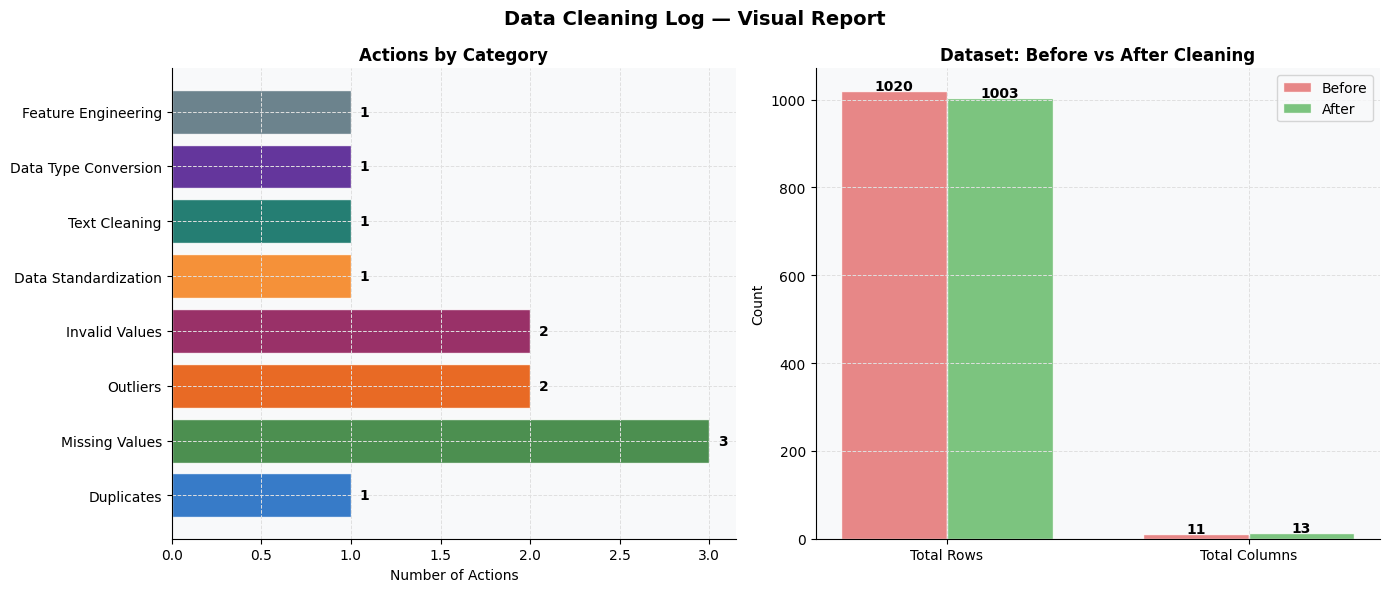

In [58]:
# ── Visualize Cleaning Report ─────────────────────────────────────────────
# Chart 1: Actions by Category
summary = log.generate_summary()
cat_data = summary['categories']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Data Cleaning Log — Visual Report', fontsize=14, fontweight='bold')

colors_cat = [
    '#1565c0',
    '#2e7d32',
    '#e65100',
    '#880e4f',
    '#f57f17',
    '#00695c',
    '#4a148c',
    '#546e7a',
]
bars = axes[0].barh(
    list(cat_data.keys()),
    list(cat_data.values()),
    color=colors_cat[: len(cat_data)],
    edgecolor='white',
    alpha=0.85,
)
axes[0].set_xlabel('Number of Actions')
axes[0].set_title('Actions by Category', fontweight='bold')
for bar, val in zip(bars, cat_data.values()):
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center',
        fontweight='bold',
    )

# Chart 2: Data Quality Before vs After
initial = log.summary_stats['initial']
final = log.summary_stats['final']
metrics = ['Total Rows', 'Total Columns']
before_vals = [initial['total_rows'], initial['total_columns']]
after_vals = [final['total_rows'], final['total_columns']]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(
    x - w / 2,
    before_vals,
    w,
    label='Before',
    color='#e57373',
    edgecolor='white',
    alpha=0.85,
)
axes[1].bar(
    x + w / 2,
    after_vals,
    w,
    label='After',
    color='#66bb6a',
    edgecolor='white',
    alpha=0.85,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Dataset: Before vs After Cleaning', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend()
for xi, bv, av in zip(x, before_vals, after_vals):
    axes[1].text(
        xi - w / 2, bv + 2, str(bv), ha='center', fontweight='bold', fontsize=10
    )
    axes[1].text(
        xi + w / 2, av + 2, str(av), ha='center', fontweight='bold', fontsize=10
    )

plt.tight_layout()
plt.show()

---
<div style="background: linear-gradient(135deg, #1a237e 0%, #283593 100%); padding: 35px 40px; border-radius: 14px; margin: 20px 0;">
  <h1 style="color: white; text-align: center; margin: 0 0 20px 0; font-size: 2em;">🏆 Key Takeaways</h1>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px;">
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #90caf9; margin: 0 0 8px 0;">🔢 Feature Scaling</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Normalize numerical ranges so no feature dominates. Choose: Standardization for normal data, Min-Max for bounded, Robust for outliers.</p>
    </div>
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #a5d6a7; margin: 0 0 8px 0;">🏷️ Encoding</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Convert categorical → numerical. One-Hot for nominal/low-cardinality, Label for ordinal/trees, Target for high-cardinality with leakage care.</p>
    </div>
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #ffcc80; margin: 0 0 8px 0;">📦 Binning</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Convert continuous → discrete. Use pd.cut() for equal-width or domain-specific ranges; pd.qcut() for equal-frequency/balanced groups.</p>
    </div>
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #f48fb1; margin: 0 0 8px 0;">⚙️ Feature Engineering</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Create new meaningful features using arithmetic ratios, statistical aggregations, and boolean logic to reveal hidden patterns.</p>
    </div>
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #ce93d8; margin: 0 0 8px 0;">🎯 Feature Selection</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Remove less important/harmful features using Filter (fast), Wrapper (accurate), or Permutation Importance (model-agnostic).</p>
    </div>
    <div style="background: rgba(255,255,255,0.12); padding: 15px; border-radius: 8px;">
      <h3 style="color: #80deea; margin: 0 0 8px 0;">📋 Documentation</h3>
      <p style="color: white; margin: 0; font-size: 0.9em;">Automated cleaning log with Executive Summary, Quality Assessment, and Transformation Log — essential for reproducibility and collaboration.</p>
    </div>
  </div>
</div>




<div style="border-left:3px solid steelblue; padding:15px; border-radius:3px; font-size:1em">
<i>This notebook is prepared <b>with aid of AI</b>.</i>
</div>